<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [18]</a>'.</span>

In [1]:
from coco_grape.utils.artificial_graph_constructor import ArtificialGraphDatasetConstructor
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import random
import matplotlib.pyplot as plt
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')
import pulp
import sys
import pulp
# sys.path.insert(0, '/lustre/home/cs843/miniconda3/envs/diffussion/lib/python3.1/site-packages')
sys.path.insert(0, '/lustre/home/cs843/miniconda3/envs/diffussion/lib/python3.10/site-packages')
import site, importlib.util
print("PY:", sys.executable)
print("site:", site.getsitepackages() if hasattr(site,"getsitepackages") else "n/a")
print("pulp spec:", importlib.util.find_spec("pulp"))


PY: /home/links/cs843/miniconda3/bin/python
site: ['/home/links/cs843/miniconda3/lib/python3.12/site-packages']
pulp spec: ModuleSpec(name='pulp', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7fa7bfb05cd0>, origin='/home/links/cs843/miniconda3/lib/python3.12/site-packages/pulp/__init__.py', submodule_search_locations=['/home/links/cs843/miniconda3/lib/python3.12/site-packages/pulp'])


In [2]:
dataset_name = "my_dataset"


In [3]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version built with PyTorch: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("PyTorch was not built with CUDA support or CUDA is not configured correctly.")
import warnings
warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import os, sys
sys.stderr = open(os.devnull, 'w')

PyTorch version: 2.4.0+cu118
CUDA available: True
CUDA version built with PyTorch: 11.8
Number of GPUs: 1
Current GPU name: NVIDIA A2


In [4]:

# DATASET_TYPE = None


In [5]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        if target == 0:
            for u in graph.nodes():
                graph.nodes[u]['display_label'] = graph.nodes[u].get('label', 0)
                graph.nodes[u]['label'] += offset
        for u in graph.nodes():
            if 'display_label' not in graph.nodes[u]:
                graph.nodes[u]['display_label'] = graph.nodes[u].get('label', 0)
        out_graphs.append(graph.copy())
    return out_graphs, targets
def select_pos_neg(sampled_graphs, sampled_targets, n_lines=3, n_graphs_per_line=12):
    import random
    k = n_graphs_per_line * n_lines
    pos_candidates = [g for g, t in zip(sampled_graphs, sampled_targets) if t == 1]
    neg_candidates = [g for g, t in zip(sampled_graphs, sampled_targets) if t != 1]
    pos_graphs = random.sample(pos_candidates, k=min(k, len(pos_candidates)))
    neg_graphs = random.sample(neg_candidates, k=min(k, len(neg_candidates)))
    return pos_graphs, neg_graphs

In [6]:
import hashlib
import math
import matplotlib.pyplot as plt
import networkx as nx





def split_pos_neg_graphs(graphs, graph_label_attr="label", positive_value=1, negative_value=0):
    """
    Split graphs by graph-level G.graph['label'].
    Positive: label == positive_value
    Negative: label == negative_value
    """
    pos_graphs = []
    neg_graphs = []

    for G in graphs:
        y = G.graph.get(graph_label_attr, None)
        if y == positive_value:
            pos_graphs.append(G)
        elif y == negative_value:
            neg_graphs.append(G)

    return pos_graphs, neg_graphs


In [7]:
import hashlib
import math
import colorsys
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Patch
import networkx as nx


DEFAULT_MOTIF_LABEL_COLORS = {
    # Three node classes: target / connector / context.
    0: "#d62828",
    1: "#1f77b4",
    2: "#16a34a",
    # Backward-compatible shaded palette for older 9-label runs.
    3: "#d7ecff",
    4: "#7db7f0",
    5: "#1f77b4",
    6: "#dcfce7",
    7: "#86efac",
    8: "#16a34a",
}

DEFAULT_MOTIF_EDGE_COLORS = {
    # Edge alphabet of size 3: target / connector / context.
    0: "#d62828",
    1: "#1f77b4",
    2: "#16a34a",
    # Optional shaded edge alphabet of size 9.
    3: "#d7ecff",
    4: "#7db7f0",
    5: "#1f77b4",
    6: "#dcfce7",
    7: "#86efac",
    8: "#16a34a",
}


def motif_color_for_label(value):
    if value is None:
        return None
    try:
        numeric = float(value)
    except (TypeError, ValueError):
        return None
    if not numeric.is_integer():
        return None
    label = int(numeric)
    active_map = globals().get("LABEL_TO_COLOR", {})
    if label in active_map:
        return active_map[label]
    return DEFAULT_MOTIF_LABEL_COLORS.get(label)


def motif_color_for_node(data, label_attr="label", color_attr="plot_color"):
    stored_color = data.get(color_attr)
    if stored_color:
        return stored_color

    role = data.get("motif_role", data.get("motif"))
    active_roles = globals().get("INCLUDE_MOTIFS", {})
    motif_labels = globals().get("MOTIF_LABELS", {})
    motif_colors = globals().get("MOTIF_COLORS", {})
    label = data.get(label_attr, data.get("label", data.get("plot_label")))

    if role is not None and active_roles.get(role, True) and role in motif_labels:
        if label in motif_labels[role]:
            return motif_colors[role][motif_labels[role].index(label)]

    return motif_color_for_label(label) or stable_node_color(label)


def motif_edge_color_for_label(value):
    if value is None:
        return None
    try:
        numeric = float(value)
    except (TypeError, ValueError):
        return None
    if not numeric.is_integer():
        return None
    label = int(numeric)
    active_map = globals().get("EDGE_LABEL_TO_COLOR", {})
    if label in active_map:
        return active_map[label]
    return DEFAULT_MOTIF_EDGE_COLORS.get(label)


def stable_node_color(value, saturation=0.46, lightness=0.72):
    label = "__MISSING__" if value is None else str(value)
    digest = hashlib.sha256(label.encode("utf-8")).digest()

    h = int.from_bytes(digest[:8], "big")
    raw_hue = h / 2**64

    cool_bands = [
        (0.50, 0.62),  # cyan/blue
        (0.42, 0.50),  # teal
        (0.30, 0.42),  # green
        (0.62, 0.74),  # blue/violet
        (0.74, 0.80),  # violet
    ]
    band = cool_bands[digest[8] % len(cool_bands)]
    hue = band[0] + raw_hue * (band[1] - band[0])

    sat_jitter = (digest[9] / 255.0 - 0.5) * 0.08
    lit_jitter = (digest[10] / 255.0 - 0.5) * 0.08

    s = max(0.32, min(0.62, saturation + sat_jitter))
    l = max(0.62, min(0.82, lightness + lit_jitter))

    return colorsys.hls_to_rgb(hue, l, s)


def stable_edge_color(value=None, default_gray="#c9c9c9"):
    return default_gray


def plot_networkx_graphs(
    graphs,
    n_cols=4,
    figsize_per_graph=(3.2, 2.8),
    node_label_attr="label",
    edge_label_attr="label",
    graph_title_attr="label",
    with_node_text=True,
    with_edge_text=False,
    seed=42,
    node_size=230,
    edge_width=2.6,
    font_size=8,
    layout="kamada_kawai",
    node_color_attr="plot_color",
    edge_color_attr="plot_color",
    show_graph_border=True,
    show_label_legend=True,
    graph_border_color="#9a9a9a",
    graph_border_linewidth=0.9,
    graph_border_alpha=0.45,
):
    graphs = list(graphs)
    if len(graphs) == 0:
        print("No graphs to plot.")
        return

    n_cols = max(1, min(n_cols, len(graphs)))
    n_rows = math.ceil(len(graphs) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_graph[0] * n_cols, figsize_per_graph[1] * n_rows),
        squeeze=False,
    )
    axes = axes.ravel()
    used_axes = []

    def _draw_graph_panel_border(ax):
        if not show_graph_border:
            return
        # NetworkX can hide axes/ticks while drawing, so restore a visible frame last.
        ax.set_axis_on()
        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color(graph_border_color)
            spine.set_alpha(graph_border_alpha)
            spine.set_linewidth(graph_border_linewidth)
            spine.set_zorder(1000)
        ax.patch.set_edgecolor(graph_border_color)
        ax.patch.set_linewidth(graph_border_linewidth)
        ax.patch.set_alpha(1.0)

    def _label_legend_handles():
        label_to_color = globals().get("LABEL_TO_COLOR", {}) or {}
        motif_labels = globals().get("MOTIF_LABELS", {}) or {}
        if not label_to_color:
            return []

        role_name_by_label = {}
        for role, labels in motif_labels.items():
            display_role = {
                "target": "cycle",
                "connector": "leg",
                "context": "context",
            }.get(role, str(role))
            for label in labels:
                role_name_by_label[label] = display_role

        handles = []
        for label in sorted(label_to_color, key=lambda value: (str(type(value)), value)):
            role_name = role_name_by_label.get(label, "label")
            handles.append(
                Patch(
                    facecolor=label_to_color[label],
                    edgecolor="#333333",
                    label=f"{label}: {role_name}",
                )
            )
        return handles

    for ax, G in zip(axes, graphs):
        used_axes.append(ax)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(True)
        ax.set_facecolor("white")

        if G.number_of_nodes() == 0:
            ax.set_title("empty graph", fontsize=10)
            _draw_graph_panel_border(ax)
            continue

        if layout == "kamada_kawai":
            pos = nx.kamada_kawai_layout(G)
        elif layout == "spring":
            pos = nx.spring_layout(G, seed=seed, k=0.8, iterations=80)
        elif layout == "circular":
            pos = nx.circular_layout(G)
        else:
            raise ValueError("layout must be 'kamada_kawai', 'spring', or 'circular'")

        node_labels = {
            n: G.nodes[n].get(node_label_attr, None)
            for n in G.nodes()
        }
        node_colors = [
            motif_color_for_node(
                G.nodes[n],
                label_attr=node_label_attr,
                color_attr=node_color_attr,
            )
            for n in G.nodes()
        ]

        edge_labels = {
            (u, v): data.get(edge_label_attr, None)
            for u, v, data in G.edges(data=True)
        }
        edge_colors = [
            G.edges[u, v].get(edge_color_attr)
            or motif_edge_color_for_label(edge_labels[(u, v)])
            or motif_edge_color_for_label(G.edges[u, v].get("label", None))
            or motif_edge_color_for_label(G.edges[u, v].get("plot_label", None))
            or stable_edge_color(edge_labels[(u, v)])
            for u, v in G.edges()
        ]

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edge_color=edge_colors,
            width=edge_width,
            alpha=0.9,
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_color=node_colors,
            node_size=node_size,
            linewidths=0.8,
            edgecolors="#333333",
        )

        if with_node_text:
            nx.draw_networkx_labels(
                G,
                pos,
                labels={n: str(node_labels[n]) for n in G.nodes()},
                ax=ax,
                font_size=font_size,
                font_color="black",
            )

        if with_edge_text:
            nx.draw_networkx_edge_labels(
                G,
                pos,
                edge_labels={e: str(lbl) for e, lbl in edge_labels.items()},
                ax=ax,
                font_size=max(6, font_size - 1),
            )

        title = G.graph.get(graph_title_attr, "")
        ax.set_title(str(title), fontsize=10)
        _draw_graph_panel_border(ax)

    for ax in axes[len(graphs):]:
        ax.axis("off")

    legend_handles = _label_legend_handles() if show_label_legend else []
    if legend_handles and len(legend_handles) <= 20:
        fig.legend(
            handles=legend_handles,
            title="Node labels",
            loc="center left",
            bbox_to_anchor=(1.005, 0.5),
            frameon=False,
            fontsize=8,
            title_fontsize=9,
        )
        plt.tight_layout(rect=[0.0, 0.0, 0.93, 1.0], pad=0.9, w_pad=0.75, h_pad=0.9)
    else:
        plt.tight_layout(pad=0.9, w_pad=0.75, h_pad=0.9)
    fig.canvas.draw()
    if show_graph_border:
        for ax in used_axes:
            bbox = ax.get_position()
            fig.add_artist(
                Rectangle(
                    (bbox.x0, bbox.y0),
                    bbox.width,
                    bbox.height,
                    transform=fig.transFigure,
                    fill=False,
                    edgecolor=graph_border_color,
                    linewidth=graph_border_linewidth,
                    alpha=graph_border_alpha,
                    zorder=10000,
                    clip_on=False,
                )
            )
    plt.show()


In [8]:
DATASET_TYPE = 'ARTIFICIAL'


# SET


controlled artificial cycle-with-leg dataset
cycle sizes: (3, 4, 5, 6, 7, 8)
leg sizes (additional path nodes): (4, 5)
target/leg alphabet sizes: 4 3
label-aware uniqueness enabled: True
train/test: 18000 600
train category counts: Counter({'cycle_5': 3000, 'cycle_7': 3000, 'cycle_8': 3000, 'cycle_3': 3000, 'cycle_4': 3000, 'cycle_6': 3000})
test category counts : Counter({'cycle_7': 100, 'cycle_3': 100, 'cycle_8': 100, 'cycle_6': 100, 'cycle_4': 100, 'cycle_5': 100})
train cycle/leg counts: Counter({(5, 5): 1500, (7, 5): 1500, (8, 4): 1500, (3, 4): 1500, (7, 4): 1500, (4, 4): 1500, (3, 5): 1500, (6, 4): 1500, (8, 5): 1500, (5, 4): 1500, (4, 5): 1500, (6, 5): 1500})
test cycle/leg counts : Counter({(7, 4): 50, (3, 4): 50, (8, 5): 50, (6, 5): 50, (7, 5): 50, (4, 5): 50, (3, 5): 50, (6, 4): 50, (5, 4): 50, (8, 4): 50, (4, 4): 50, (5, 5): 50})
total-node counts: Counter({10: 3100, 12: 3100, 11: 3100, 8: 3100, 9: 3100, 7: 1550, 13: 1550})
unique train labeled signatures: 18000
unique test 

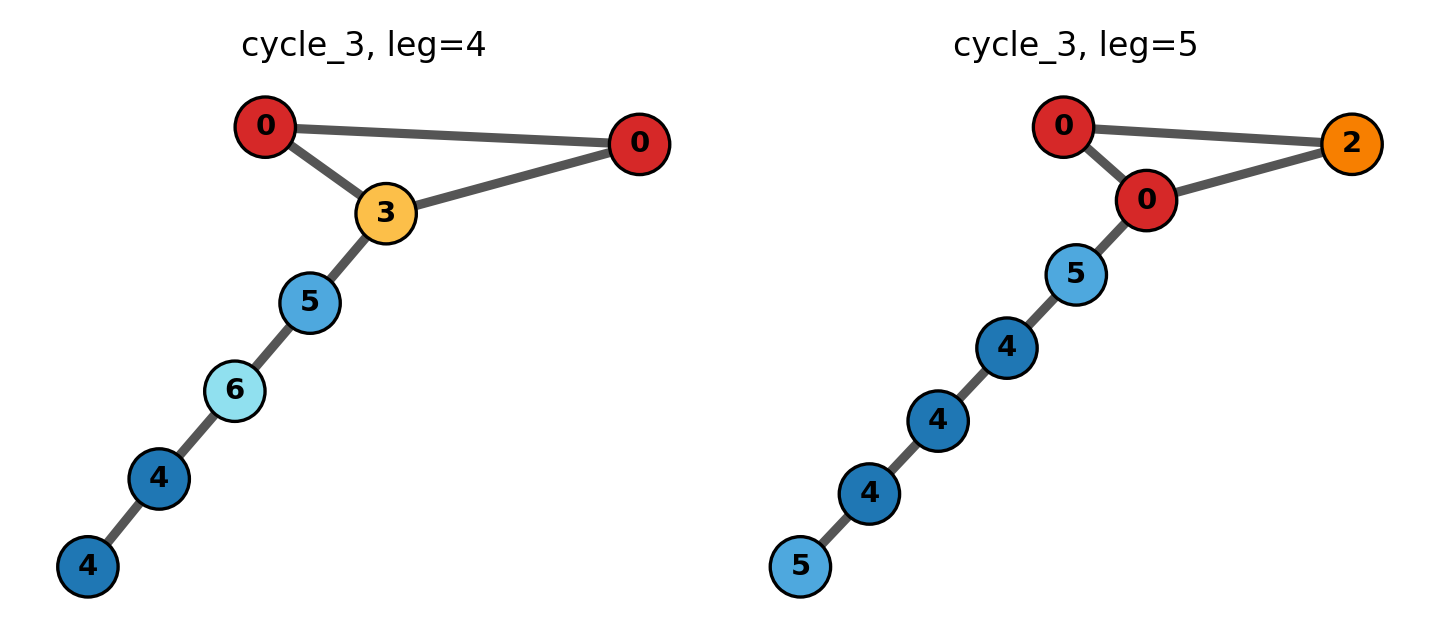

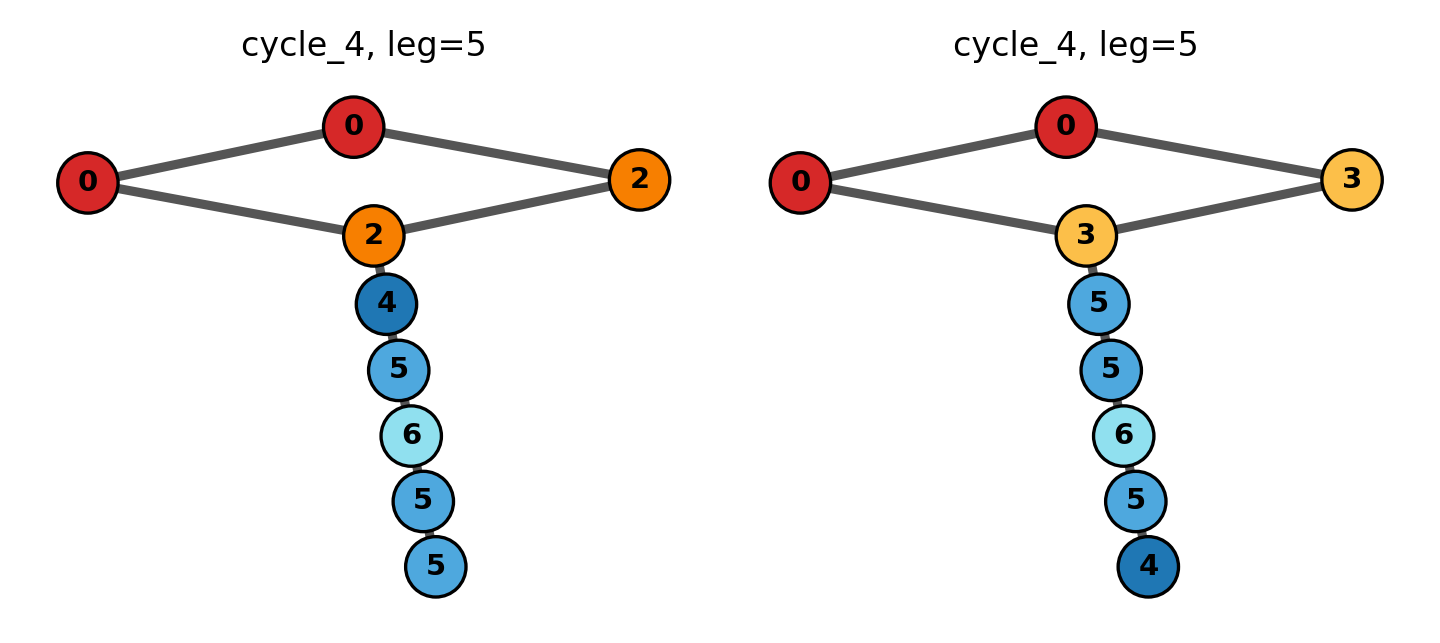

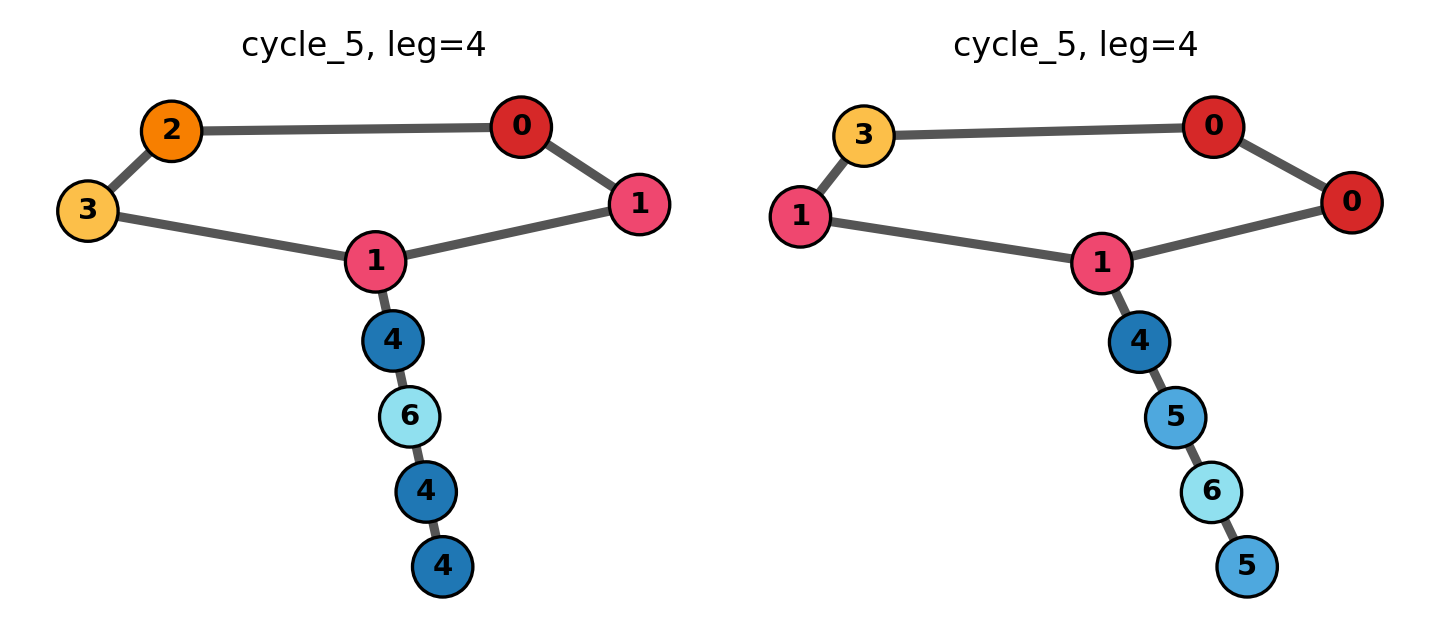

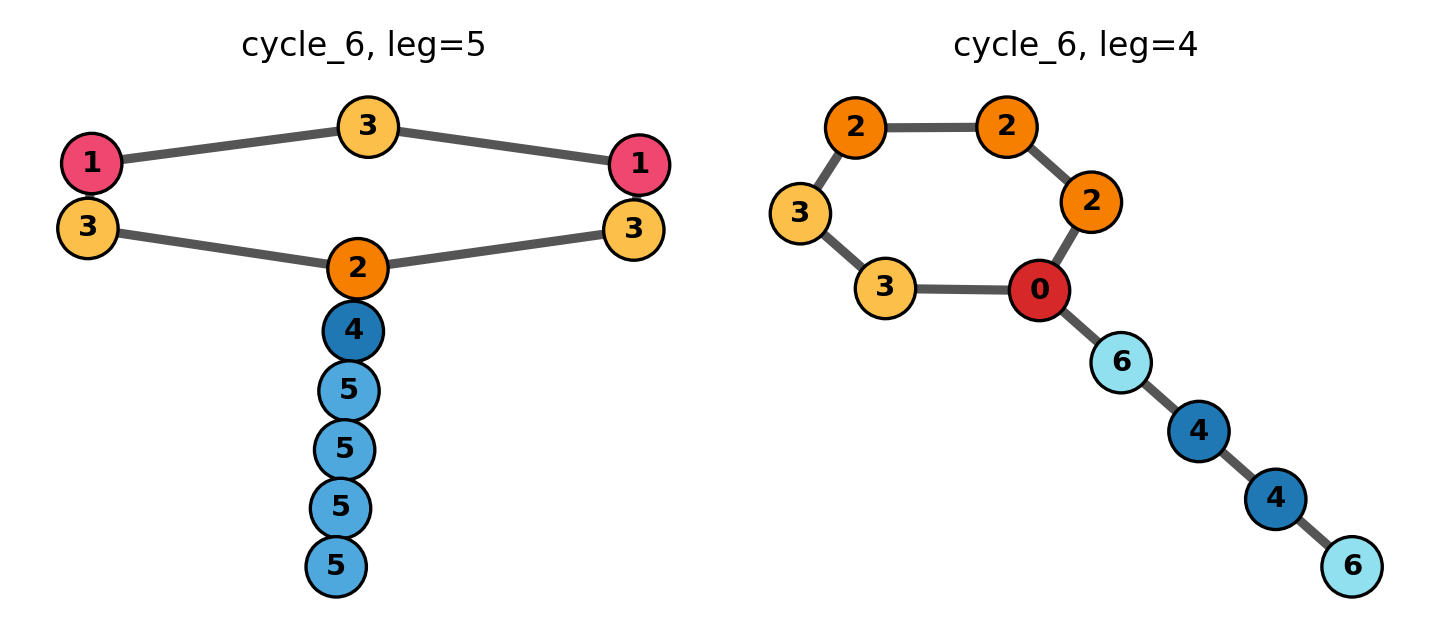

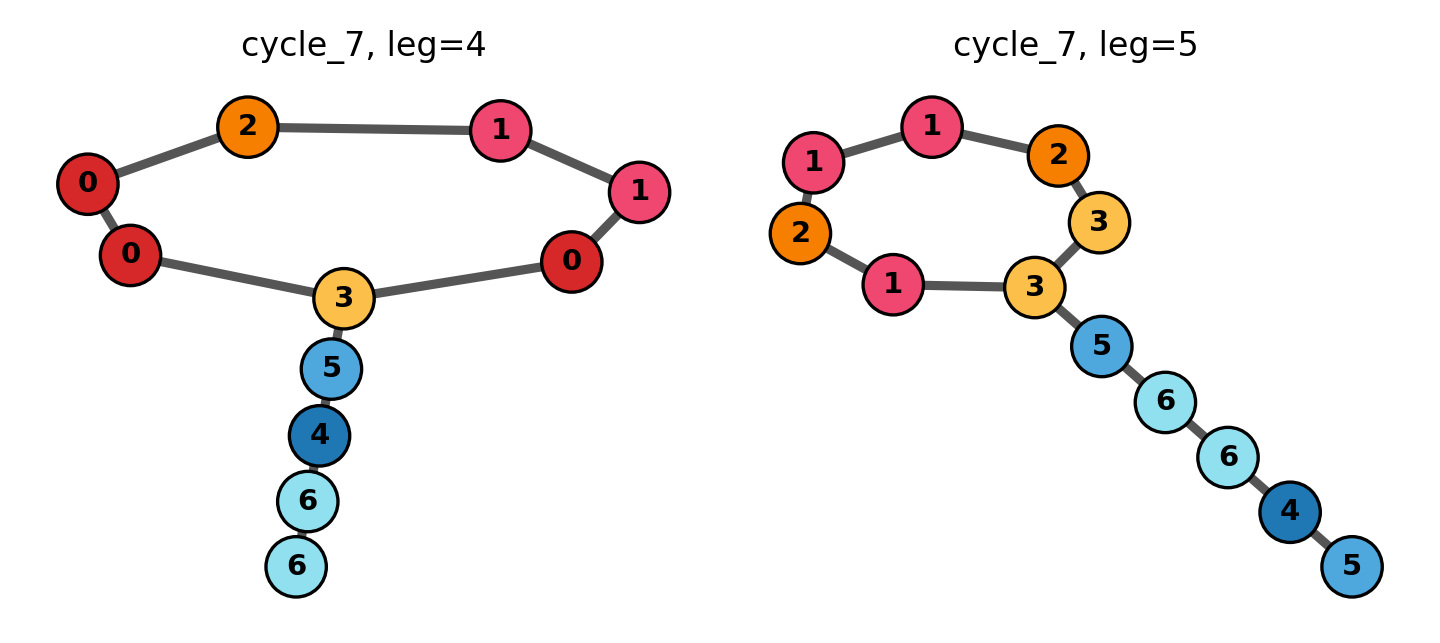

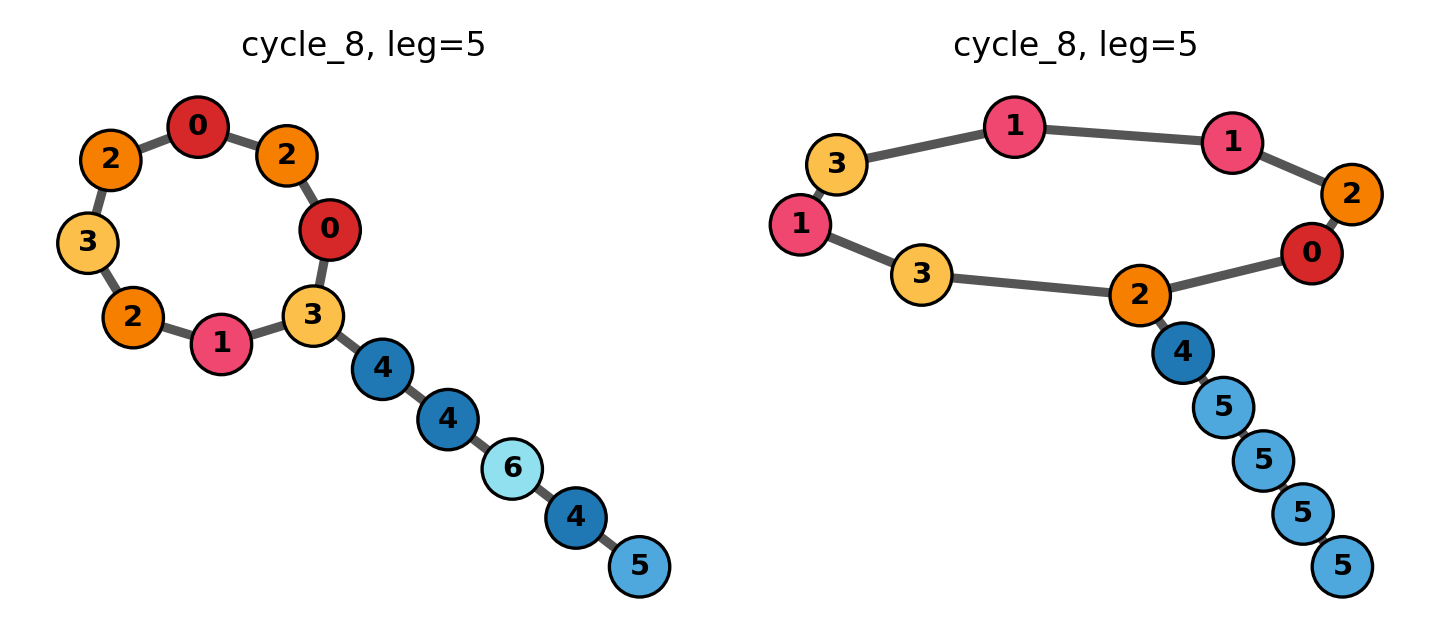

CPU times: user 3.27 s, sys: 1.57 s, total: 4.85 s
Wall time: 3.07 s


In [9]:
%%time
import math
import random
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ============================================================
# Controlled supervisor experiment: cycle size with one leg
# ============================================================
# Four balanced categories:
#   cycle_3, cycle_4, cycle_5, cycle_6
# Each graph has one attached path containing 4 or 5 additional nodes.
# Per category: 750 training graphs + 100 test graphs.

CYCLE_SIZES = (3, 4, 5, 6,7,8)
LEG_SIZES = (4, 5)
TRAIN_GRAPHS_PER_CATEGORY = 3000
TEST_GRAPHS_PER_CATEGORY = 100
DATASET_SEED = 42
TARGET_ALPHABET_SIZE = 4
LEG_ALPHABET_SIZE = 3
MAX_UNIQUE_ATTEMPTS_PER_GRAPH = 20000

test_size = TEST_GRAPHS_PER_CATEGORY * len(CYCLE_SIZES)
dataset_size = (
    TRAIN_GRAPHS_PER_CATEGORY + TEST_GRAPHS_PER_CATEGORY
) * len(CYCLE_SIZES)
n_graphs_per_line = 8
ARTIFICIAL_VARIABLE_SIZE = True

GRAPH_TYPES = ["cycle_with_leg"]
INCLUDE_MOTIFS = {
    "target": True,
    "connector": True,
    "context": False,
}
UNIQUE_GRAPHS = True
RANDOMIZE_NODE_LABELS = True

MOTIF_CONFIG = {
    "target_type": "cycle",
    "connector_type": "path",
    "context_type": None,
    "target_size": CYCLE_SIZES,
    "connector_size": LEG_SIZES,
    "context_size": 0,
    "total_nodes": None,
}

ROLE_CONFIG = {
    "target": {
        "node_labels": list(range(TARGET_ALPHABET_SIZE)),
        "node_colors": ["#d62828", "#ef476f", "#f77f00", "#fcbf49"],
        "edge_labels": [0],
        "edge_colors": ["#d62828"],
    },
    "connector": {
        "node_labels": list(range(
            TARGET_ALPHABET_SIZE,
            TARGET_ALPHABET_SIZE + LEG_ALPHABET_SIZE,
        )),
        "node_colors": ["#1f77b4", "#4ea8de", "#90e0ef"],
        "edge_labels": [0],
        "edge_colors": ["#1f77b4"],
    },
    "context": {
        "node_labels": [],
        "node_colors": [],
        "edge_labels": [0],
        "edge_colors": ["#555555"],
    },
}

EDGE_CONFIG = {
    "set_edge_labels": False,
    "edge_alphabet": [0],
    "default_edge_label": 0,
    "edge_color_mode": "none",
}

MOTIF_LABELS = {
    role: list(spec["node_labels"])
    for role, spec in ROLE_CONFIG.items()
}
def _repeat_palette(colors, size):
    colors = list(colors) or ["#cccccc"]
    return [colors[index % len(colors)] for index in range(int(size))]


MOTIF_COLORS = {
    role: _repeat_palette(spec["node_colors"], len(spec["node_labels"]))
    for role, spec in ROLE_CONFIG.items()
}
NODE_ALPHABET = sorted(
    label
    for role in ("target", "connector")
    for label in MOTIF_LABELS[role]
)
alphabet_size = len(NODE_ALPHABET)
LABEL_TO_COLOR = {
    label: MOTIF_COLORS[role][index]
    for role in ("target", "connector")
    for index, label in enumerate(MOTIF_LABELS[role])
}
EDGE_LABEL_TO_COLOR = {0: "#555555"}


def make_cycle_leg_graph(cycle_size, leg_size, seed, graph_id, split):
    """Create one labeled cycle with one attached path leg."""
    cycle_size = int(cycle_size)
    leg_size = int(leg_size)
    if cycle_size < 3:
        raise ValueError("cycle_size must be at least 3")
    if leg_size < 1:
        raise ValueError("leg_size must be positive")

    rng = random.Random(int(seed))
    graph = nx.Graph()

    cycle_nodes = list(range(cycle_size))
    leg_nodes = list(range(cycle_size, cycle_size + leg_size))

    for index, node in enumerate(cycle_nodes):
        label = rng.choice(MOTIF_LABELS["target"])
        graph.add_node(
            node,
            label=label,
            attr=label,
            plot_label=label,
            display_label=label,
            plot_color=LABEL_TO_COLOR[label],
            motif="target",
            motif_role="target",
            motif_type="cycle",
            node_role="cycle",
            cycle_position=index,
        )

    for index, node in enumerate(leg_nodes):
        label = rng.choice(MOTIF_LABELS["connector"])
        graph.add_node(
            node,
            label=label,
            attr=label,
            plot_label=label,
            display_label=label,
            plot_color=LABEL_TO_COLOR[label],
            motif="connector",
            motif_role="connector",
            motif_type="path",
            node_role="leg",
            leg_position=index,
        )

    for index, node in enumerate(cycle_nodes):
        graph.add_edge(
            node,
            cycle_nodes[(index + 1) % cycle_size],
            label=0,
            edge_attr=0,
            plot_label=0,
            plot_color="#555555",
            motif="target",
            motif_role="target",
            motif_type="cycle",
        )

    # Random attachment position prevents node index from identifying the category.
    attachment_node = rng.choice(cycle_nodes)
    graph.add_edge(
        attachment_node,
        leg_nodes[0],
        label=0,
        edge_attr=0,
        plot_label=0,
        plot_color="#555555",
        motif="connector",
        motif_role="connector",
        motif_type="path",
    )
    for left, right in zip(leg_nodes[:-1], leg_nodes[1:]):
        graph.add_edge(
            left,
            right,
            label=0,
            edge_attr=0,
            plot_label=0,
            plot_color="#555555",
            motif="connector",
            motif_role="connector",
            motif_type="path",
        )

    graph.graph.update(
        {
            "graph_id": int(graph_id),
            "split": str(split),
            "category": f"cycle_{cycle_size}",
            "motif_family": "cycle_with_leg",
            "target_type": "cycle",
            "connector_type": "path",
            "context_type": None,
            "target_size": cycle_size,
            "cycle_size": cycle_size,
            "connector_size": leg_size,
            "leg_size": leg_size,
            "context_size": 0,
            "branch_count": 1,
            "branch_lengths": (leg_size,),
            "total_nodes": cycle_size + leg_size,
            "attachment_node": attachment_node,
        }
    )
    return graph


def labeled_cycle_leg_signature(graph):
    """Canonical label signature, invariant to reflecting the rooted cycle."""
    cycle_size = int(graph.graph["cycle_size"])
    leg_size = int(graph.graph["leg_size"])
    attachment = int(graph.graph["attachment_node"])

    forward_cycle = tuple(
        int(graph.nodes[(attachment + offset) % cycle_size]["label"])
        for offset in range(cycle_size)
    )
    reverse_cycle = tuple(
        int(graph.nodes[(attachment - offset) % cycle_size]["label"])
        for offset in range(cycle_size)
    )
    canonical_cycle = min(forward_cycle, reverse_cycle)
    leg_labels = tuple(
        int(graph.nodes[cycle_size + offset]["label"])
        for offset in range(leg_size)
    )
    return cycle_size, leg_size, canonical_cycle, leg_labels


def build_balanced_cycle_leg_split(
    per_category,
    split,
    seed,
    used_signatures=None,
):
    """Build a balanced split with no repeated labeled motif signatures."""
    graphs = []
    targets = []
    rng = random.Random(int(seed))
    graph_id = 0
    used_signatures = set() if used_signatures is None else used_signatures
    split_signatures = set()

    for cycle_size in CYCLE_SIZES:
        leg_schedule = [
            LEG_SIZES[index % len(LEG_SIZES)]
            for index in range(int(per_category))
        ]
        rng.shuffle(leg_schedule)

        category_graphs = []
        for leg_size in leg_schedule:
            graph = None
            signature = None
            for _ in range(MAX_UNIQUE_ATTEMPTS_PER_GRAPH):
                graph_seed = rng.randint(0, 2**31 - 1)
                candidate = make_cycle_leg_graph(
                    cycle_size=cycle_size,
                    leg_size=leg_size,
                    seed=graph_seed,
                    graph_id=graph_id,
                    split=split,
                )
                candidate_signature = labeled_cycle_leg_signature(candidate)
                if candidate_signature not in used_signatures:
                    graph = candidate
                    signature = candidate_signature
                    break
            if graph is None:
                raise RuntimeError(
                    "Could not create enough unique labeled graphs for "
                    f"cycle={cycle_size}, leg={leg_size}. Increase the target/leg "
                    "alphabet sizes or reduce the requested graph count."
                )
            used_signatures.add(signature)
            split_signatures.add(signature)
            graph.graph["labeled_signature"] = signature
            category_graphs.append((graph, f"cycle_{cycle_size}"))
            graph_id += 1

        rng.shuffle(category_graphs)
        graphs.extend(graph for graph, _ in category_graphs)
        targets.extend(target for _, target in category_graphs)

    paired = list(zip(graphs, targets))
    rng.shuffle(paired)
    return (
        [graph for graph, _ in paired],
        [target for _, target in paired],
        split_signatures,
    )


def ensure_plot_attrs(graphs):
    for graph in graphs:
        for _, data in graph.nodes(data=True):
            label = int(data.get("label", 0))
            data["label"] = label
            data["attr"] = label
            data["plot_label"] = label
            data["display_label"] = label
            data["plot_color"] = LABEL_TO_COLOR.get(label, "#cccccc")
        for _, _, data in graph.edges(data=True):
            data["label"] = 0
            data["edge_attr"] = 0
            data["plot_label"] = 0
            data["plot_color"] = "#555555"


def plot_motif_graphs(graphs, n_cols=8, node_size=210, edge_width=2.2):
    if not graphs:
        return
    n_rows = math.ceil(len(graphs) / n_cols)
    figure, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.45 * n_cols, 2.25 * n_rows),
        dpi=150,
    )
    axes = np.asarray(axes).reshape(-1)

    for axis, graph in zip(axes, graphs):
        try:
            positions = nx.kamada_kawai_layout(graph)
        except Exception:
            positions = nx.spring_layout(graph, seed=42)
        nx.draw_networkx_edges(
            graph,
            positions,
            ax=axis,
            edge_color=[
                graph.edges[u, v].get("plot_color", "#555555")
                for u, v in graph.edges()
            ],
            width=edge_width,
        )
        nx.draw_networkx_nodes(
            graph,
            positions,
            ax=axis,
            node_color=[
                graph.nodes[node].get("plot_color", "#cccccc")
                for node in graph.nodes()
            ],
            edgecolors="black",
            linewidths=0.8,
            node_size=node_size,
        )
        nx.draw_networkx_labels(
            graph,
            positions,
            ax=axis,
            labels={
                node: graph.nodes[node].get("plot_label", "")
                for node in graph.nodes()
            },
            font_size=7,
            font_weight="bold",
        )
        axis.set_title(
            f"{graph.graph['category']}, leg={graph.graph['leg_size']}",
            fontsize=8,
        )
        axis.axis("off")

    for axis in axes[len(graphs):]:
        axis.axis("off")
    plt.tight_layout()
    plt.show()


all_labeled_signatures = set()
train_graphs, train_targets, train_labeled_signatures = build_balanced_cycle_leg_split(
    per_category=TRAIN_GRAPHS_PER_CATEGORY,
    split="train",
    seed=DATASET_SEED,
    used_signatures=all_labeled_signatures,
)
test_graphs, test_targets, test_labeled_signatures = build_balanced_cycle_leg_split(
    per_category=TEST_GRAPHS_PER_CATEGORY,
    split="test",
    seed=DATASET_SEED + 1,
    used_signatures=all_labeled_signatures,
)
ensure_plot_attrs(train_graphs)
ensure_plot_attrs(test_graphs)

# Compatibility variables expected by later notebook cells.
graphs = list(train_graphs) + list(test_graphs)
targets = list(train_targets) + list(test_targets)
original_graphs = np.asarray(graphs, dtype=object)
original_targets = np.asarray(targets, dtype=object)

print("controlled artificial cycle-with-leg dataset")
print("cycle sizes:", CYCLE_SIZES)
print("leg sizes (additional path nodes):", LEG_SIZES)
print("target/leg alphabet sizes:", TARGET_ALPHABET_SIZE, LEG_ALPHABET_SIZE)
print("label-aware uniqueness enabled:", UNIQUE_GRAPHS)
print("train/test:", len(train_graphs), len(test_graphs))
print("train category counts:", Counter(train_targets))
print("test category counts :", Counter(test_targets))
print(
    "train cycle/leg counts:",
    Counter(
        (graph.graph["cycle_size"], graph.graph["leg_size"])
        for graph in train_graphs
    ),
)
print(
    "test cycle/leg counts :",
    Counter(
        (graph.graph["cycle_size"], graph.graph["leg_size"])
        for graph in test_graphs
    ),
)
print(
    "total-node counts:",
    Counter(graph.number_of_nodes() for graph in graphs),
)
print("unique train labeled signatures:", len(train_labeled_signatures))
print("unique test labeled signatures :", len(test_labeled_signatures))
print(
    "train/test labeled-signature overlap:",
    len(train_labeled_signatures & test_labeled_signatures),
)

expected_train_counts = {
    f"cycle_{cycle_size}": TRAIN_GRAPHS_PER_CATEGORY
    for cycle_size in CYCLE_SIZES
}
expected_test_counts = {
    f"cycle_{cycle_size}": TEST_GRAPHS_PER_CATEGORY
    for cycle_size in CYCLE_SIZES
}
expected_train_leg_count = TRAIN_GRAPHS_PER_CATEGORY // len(LEG_SIZES)
expected_test_leg_count = TEST_GRAPHS_PER_CATEGORY // len(LEG_SIZES)

if Counter(train_targets) != Counter(expected_train_counts):
    raise RuntimeError("Training categories are not balanced as configured.")
if Counter(test_targets) != Counter(expected_test_counts):
    raise RuntimeError("Test categories are not balanced as configured.")
for cycle_size in CYCLE_SIZES:
    for leg_size in LEG_SIZES:
        train_count = sum(
            graph.graph["cycle_size"] == cycle_size
            and graph.graph["leg_size"] == leg_size
            for graph in train_graphs
        )
        test_count = sum(
            graph.graph["cycle_size"] == cycle_size
            and graph.graph["leg_size"] == leg_size
            for graph in test_graphs
        )
        if train_count != expected_train_leg_count:
            raise RuntimeError(
                f"Unexpected training count for cycle={cycle_size}, leg={leg_size}: "
                f"{train_count}."
            )
        if test_count != expected_test_leg_count:
            raise RuntimeError(
                f"Unexpected test count for cycle={cycle_size}, leg={leg_size}: "
                f"{test_count}."
            )
if len(train_labeled_signatures) != len(train_graphs):
    raise RuntimeError("Duplicate labeled graph signatures found in training.")
if len(test_labeled_signatures) != len(test_graphs):
    raise RuntimeError("Duplicate labeled graph signatures found in test.")
if train_labeled_signatures & test_labeled_signatures:
    raise RuntimeError("Training and test labeled graph signatures overlap.")

print("Dataset validation passed: balanced, unique, and train/test-disjoint.")

for cycle_size in CYCLE_SIZES:
    examples = [
        graph
        for graph in test_graphs
        if graph.graph["cycle_size"] == cycle_size
    ][:2]
    plot_motif_graphs(examples, n_cols=2)


In [10]:
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt

def plot_label_comparative_histogram(
    probe_train_graphs,
    decoded_graphs,
    conditioning_decoded_graphs,
    labels=('Probe Train Graphs', 'Decoded Graphs', 'Conditioning Decoded Graphs'),
    title='Comparative Histogram of Node Labels Across Graph Sets',
    figsize=(12, 6),
    bar_edgecolor='black',
    annotate=True,
    annotate_offset=3  # points above the bar
):
    """
    Plots a grouped bar chart comparing node 'label' attribute frequencies
    across three lists of networkx graphs.
    """

    def _norm_label(x):
        # Make everything a stable, comparable string key
        try:
            hash(x)            # ensure hashable; if not, fall back to repr
        except TypeError:
            x = repr(x)
        return str(x)

    def _get_label_counts(graph_list):
        counts = Counter()
        for G in graph_list:
            for v in nx.get_node_attributes(G, 'label').values():
                counts[_norm_label(v)] += 1
        return counts

    # Compute normalized label counts
    counts_list = [
        _get_label_counts(probe_train_graphs),
        _get_label_counts(decoded_graphs),
        _get_label_counts(conditioning_decoded_graphs)
    ]

    # Union of all stringified labels, sorted lexicographically
    all_labels = sorted(set().union(*[c.keys() for c in counts_list]))
    x = range(len(all_labels))
    width = 0.25

    # Align counts to all_labels order
    vals = [[c.get(lbl, 0) for lbl in all_labels] for c in counts_list]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    bars1 = ax.bar([i - width for i in x], vals[0], width=width,
                   label=labels[0], edgecolor=bar_edgecolor)
    bars2 = ax.bar(x,               vals[1], width=width,
                   label=labels[1], edgecolor=bar_edgecolor)
    bars3 = ax.bar([i + width for i in x], vals[2], width=width,
                   label=labels[2], edgecolor=bar_edgecolor)

    # Annotate counts
    if annotate:
        for bar in list(bars1) + list(bars2) + list(bars3):
            height = bar.get_height()
            ax.annotate(
                f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, annotate_offset),
                textcoords="offset points",
                ha='center',
                va='bottom'
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(all_labels, rotation=0, ha='right')
    ax.set_xlabel('Node Label')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()

# === WL & NSPDK MMD from NetworkX graphs (one cell) ==========================
import numpy as np, networkx as nx

def _to_simple_undirected(G):
    H = nx.Graph(G) if isinstance(G, (nx.DiGraph, nx.MultiDiGraph)) else G.copy()
    H.remove_edges_from(nx.selfloop_edges(H))
    return H

def _nonempty(graphs):
    return [G for G in graphs if _to_simple_undirected(G).number_of_nodes() > 0]

# ---------------- GraKeL conversion: build Graph objects ---------------------
def nx_to_grakel_wl(graphs, node_label_key="label"):
    """For WL+VertexHistogram: Graph(adjacency, node_labels, None)."""
    from grakel import Graph
    glist = []
    for G in _nonempty(graphs):
        H = _to_simple_undirected(G)
        nodes = list(H.nodes())
        n = len(nodes)
        idx = {u: i for i, u in enumerate(nodes)}
        A = np.zeros((n, n), dtype=int)
        for u, v in H.edges():
            i, j = idx[u], idx[v]
            A[i, j] = 1; A[j, i] = 1
        # node labels: use provided key if present, else a constant label "0"
        if all(node_label_key in H.nodes[u] for u in nodes):
            vlab = {idx[u]: str(H.nodes[u][node_label_key]) for u in nodes}
        else:
            vlab = {i: "0" for i in range(n)}
        glist.append(Graph(A, vlab, None))  # <-- removed directed kwarg
    return glist

def nx_to_grakel_nspdk(graphs, node_label_key="label"):
    """For NSPDK: Graph(adjacency, node_labels, edge_labels). Edge labels set to '1'."""
    from grakel import Graph
    glist = []
    for G in _nonempty(graphs):
        H = _to_simple_undirected(G)
        nodes = list(H.nodes())
        n = len(nodes)
        idx = {u: i for i, u in enumerate(nodes)}
        A = np.zeros((n, n), dtype=int)
        for u, v in H.edges():
            i, j = idx[u], idx[v]
            A[i, j] = 1; A[j, i] = 1
        # node labels: provided if present, else "0"
        if all(node_label_key in H.nodes[u] for u in nodes):
            vlab = {idx[u]: str(H.nodes[u][node_label_key]) for u in nodes}
        else:
            vlab = {i: "0" for i in range(n)}
        # edge labels: constant '1' on existing edges (both directions)
        elab = {}
        for u, v in H.edges():
            i, j = idx[u], idx[v]
            elab[(i, j)] = '1'
            elab[(j, i)] = '1'
        glist.append(Graph(A, vlab, elab))  # <-- removed directed kwarg
    return glist

# ---------------- MMD utilities ----------------------------------------------
def _mmd2_unbiased(Kxx, Kyy, Kxy):
    m, n = Kxx.shape[0], Kyy.shape[0]
    if m < 2 or n < 2: return np.nan, np.nan
    Kxx = Kxx.copy(); Kyy = Kyy.copy()
    np.fill_diagonal(Kxx, 0.0); np.fill_diagonal(Kyy, 0.0)
    term_x = Kxx.sum()/(m*(m-1))
    term_y = Kyy.sum()/(n*(n-1))
    term_xy = 2.0*Kxy.sum()/(m*n)
    mmd2 = term_x + term_y - term_xy
    return float(mmd2), float(np.sqrt(max(mmd2, 0.0)))

# ---------------- WL (VertexHistogram) MMD -----------------------------------
def wl_mmd(true_graphs, gen_graphs, node_label_key="label", n_iter=5, normalize=True):
    try:
        from grakel.kernels import WeisfeilerLehman, VertexHistogram
    except Exception as e:
        raise RuntimeError("GraKeL not installed. pip install grakel") from e
    Gx = nx_to_grakel_wl(true_graphs, node_label_key)
    Gy = nx_to_grakel_wl(gen_graphs,  node_label_key)
    if len(Gx) == 0 or len(Gy) == 0:
        return {"wl_mmd": np.nan, "wl_mmd2": np.nan, "note": "empty after parsing"}
    base_spec = (VertexHistogram, {"normalize": normalize})
    wl_x = WeisfeilerLehman(n_iter=n_iter, base_graph_kernel=base_spec, normalize=normalize)
    Kxx = wl_x.fit_transform(Gx)
    Kxy = wl_x.transform(Gy)
    wl_y = WeisfeilerLehman(n_iter=n_iter, base_graph_kernel=base_spec, normalize=normalize)
    Kyy = wl_y.fit_transform(Gy)
    mmd2, mmd = _mmd2_unbiased(Kxx, Kyy, Kxy)
    return {"wl_mmd": mmd, "wl_mmd2": mmd2, "wl_n_iter": n_iter}

# ---------------- NSPDK MMD ---------------------------------------------------
def nspdk_mmd(true_graphs, gen_graphs, node_label_key="label", r=1, d=6, normalize=True, n_jobs=-1):
    try:
        from grakel.kernels import NeighborhoodSubgraphPairwiseDistance as NSPDK
    except Exception as e:
        raise RuntimeError("GraKeL not installed. pip install grakel") from e
    Gx = nx_to_grakel_nspdk(true_graphs, node_label_key)
    Gy = nx_to_grakel_nspdk(gen_graphs,  node_label_key)
    if len(Gx) == 0 or len(Gy) == 0:
        return {"nspdk_mmd": np.nan, "nspdk_mmd2": np.nan, "note": "empty after parsing"}
    K = NSPDK(r=r, d=d, normalize=normalize, n_jobs=n_jobs)
    Kxx = K.fit_transform(Gx)
    Kxy = K.transform(Gy)
    Ky = NSPDK(r=r, d=d, normalize=normalize, n_jobs=n_jobs)
    Kyy = Ky.fit_transform(Gy)
    mmd2, mmd = _mmd2_unbiased(Kxx, Kyy, Kxy)
    return {"nspdk_mmd": mmd, "nspdk_mmd2": mmd2, "nspdk_r": r, "nspdk_d": d}

# # ---------------- Example run on your three sets ------------------------------
# # Assumes you already have: probe_train_graphs, decoded_graphs, conditioning_decoded_graphs
# wl_true_vs_nodes = wl_mmd(probe_train_graphs, decoded_graphs, n_iter=5, normalize=True)
# wl_true_vs_cond  = wl_mmd(probe_train_graphs, conditioning_decoded_graphs, n_iter=5, normalize=True)
# ns_true_vs_nodes = nspdk_mmd(probe_train_graphs, decoded_graphs, r=1, d=4, normalize=True)
# ns_true_vs_cond  = nspdk_mmd(probe_train_graphs, conditioning_decoded_graphs, r=1, d=4, normalize=True)

# print("WL  (true vs nodes):", wl_true_vs_nodes)
# print("WL  (true vs cond) :", wl_true_vs_cond)
# print("NSPDK (true vs nodes):", ns_true_vs_nodes)
# print("NSPDK (true vs cond) :", ns_true_vs_cond)


In [11]:
# ===== Optional split train into train1/train2, keep existing test split =====

from collections import Counter
from sklearn.model_selection import train_test_split

DO_TRAIN_SPLIT = True
USE_TRAIN1_FOR_DOWNSTREAM = False

if DO_TRAIN_SPLIT:

    def _ensure_nsppk_labels(graphs, default_node_label=0, default_edge_label=0):
        out = []
        d = int(default_node_label)
        de = int(default_edge_label)

        for g in graphs:
            h = g.copy()

            for u in h.nodes():
                attrs = h.nodes[u]
                raw = attrs.get('label', attrs.get('display_label', attrs.get('true_label', d)))
                try:
                    lbl = int(raw)
                except Exception:
                    lbl = d

                attrs['label'] = lbl
                attrs['display_label'] = int(attrs.get('display_label', lbl)) if str(attrs.get('display_label', lbl)).lstrip('-').isdigit() else lbl
                attrs['true_label'] = int(attrs.get('true_label', lbl)) if str(attrs.get('true_label', lbl)).lstrip('-').isdigit() else lbl

            for u, v in h.edges():
                eattrs = h.edges[u, v]
                eraw = eattrs.get('label', eattrs.get('true_label', de))
                try:
                    elbl = int(eraw)
                except Exception:
                    elbl = de

                eattrs['label'] = elbl
                eattrs['true_label'] = int(eattrs.get('true_label', elbl)) if str(eattrs.get('true_label', elbl)).lstrip('-').isdigit() else elbl

            out.append(h)

        return out


    train_graphs = _ensure_nsppk_labels(train_graphs)
    test_graphs = _ensure_nsppk_labels(test_graphs)

    train_whole_graphs = [g.copy() for g in train_graphs]
    train_whole_targets = None if train_targets is None else list(train_targets)

    if train_whole_targets is None:
        train1_graphs, train2_graphs = train_test_split(
            train_whole_graphs,
            test_size=0.5,
            random_state=42,
        )
        train1_targets = None
        train2_targets = None
    else:
        counts = Counter(train_whole_targets)
        can_stratify = len(counts) > 1 and min(counts.values()) >= 2
        stratify_arg = train_whole_targets if can_stratify else None

        train1_graphs, train2_graphs, train1_targets, train2_targets = train_test_split(
            train_whole_graphs,
            train_whole_targets,
            test_size=0.5,
            random_state=42,
            stratify=stratify_arg,
        )

    if USE_TRAIN1_FOR_DOWNSTREAM:
        train_graphs = train1_graphs
        train_targets = train1_targets
        print('downstream training source: train1')
    else:
        train_graphs = train_whole_graphs
        train_targets = train_whole_targets
        print('downstream training source: train_whole')

    print('train_whole/train1/train2/test:', len(train_whole_graphs), len(train1_graphs), len(train2_graphs), len(test_graphs))
    if train_whole_targets is None:
        print('train_whole class counts: unlabeled')
        print('train1 class counts     : unlabeled')
        print('train2 class counts     : unlabeled')
        print('test class counts       : unlabeled')
    else:
        print('train_whole class counts:', Counter(train_whole_targets))
        print('train1 class counts     :', Counter(train1_targets))
        print('train2 class counts     :', Counter(train2_targets))
        print('test class counts       :', Counter(test_targets))


    # ===== Debug classifier: NSPPK on train1/train2/train1+train2 =====

    import numpy as np
    from sklearn.ensemble import ExtraTreesClassifier
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
    from coco_grape.graph_vectorizer.nsppk import NSPPK


    def _safe_f1(y_true, y_pred):
        labels = sorted(set(y_true) | set(y_pred))
        if len(labels) <= 2:
            return float(f1_score(y_true, y_pred, zero_division=0))
        return float(f1_score(y_true, y_pred, average='macro', zero_division=0))


    def _evaluate_split_repeated(graphs, targets, label, n_repeats=10, base_seed=42):
        if not graphs:
            print(f'{label}: no graphs to evaluate')
            return

        targets = list(targets)
        counts = Counter(targets)
        if len(graphs) < 5 or len(counts) < 2 or min(counts.values()) < 2:
            print(f'{label}: skipped repeated eval, too few examples/classes: {counts}')
            return

        f1_vals = []
        bal_vals = []
        acc_vals = []

        for rep in range(int(n_repeats)):
            seed = int(base_seed) + rep
            idx = np.arange(len(graphs))

            tr_idx, va_idx = train_test_split(
                idx,
                test_size=0.2,
                random_state=seed,
                stratify=targets,
            )

            g_tr = [graphs[i] for i in tr_idx]
            g_va = [graphs[i] for i in va_idx]
            y_tr = [targets[i] for i in tr_idx]
            y_va = [targets[i] for i in va_idx]

            vec = NSPPK(radius=1, distance=4, connector=0, nbits=12, dense=False, parallel=False)
            X_tr = vec.fit_transform(g_tr, y_tr)
            X_va = vec.transform(g_va)

            clf = ExtraTreesClassifier(n_estimators=300, random_state=seed, n_jobs=-1)
            clf.fit(X_tr, y_tr)
            preds = clf.predict(X_va)

            f1_vals.append(_safe_f1(y_va, preds))
            bal_vals.append(float(balanced_accuracy_score(y_va, preds)))
            acc_vals.append(float(accuracy_score(y_va, preds)))

        print(
            f"{label} summary: "
            f"f1={np.mean(f1_vals):.3f}+-{np.std(f1_vals):.3f} "
            f"bal={np.mean(bal_vals):.3f}+-{np.std(bal_vals):.3f} "
            f"acc={np.mean(acc_vals):.3f}+-{np.std(acc_vals):.3f}"
        )


    N_REPEATS = 1
    BASE_SEED = int(globals().get('SEED', 42))

    if train_whole_targets is None:
        print('NSPPK split classifier skipped: graph targets are unlabeled')
    else:
        _evaluate_split_repeated(train1_graphs, train1_targets, 'train1', n_repeats=N_REPEATS, base_seed=BASE_SEED)
        _evaluate_split_repeated(train2_graphs, train2_targets, 'train2', n_repeats=N_REPEATS, base_seed=BASE_SEED)

        combined_graphs = train1_graphs + train2_graphs
        combined_targets = list(train1_targets) + list(train2_targets)
        _evaluate_split_repeated(combined_graphs, combined_targets, 'train1+train2', n_repeats=N_REPEATS, base_seed=BASE_SEED)


downstream training source: train_whole
train_whole/train1/train2/test: 18000 9000 9000 600
train_whole class counts: Counter({'cycle_5': 3000, 'cycle_7': 3000, 'cycle_8': 3000, 'cycle_3': 3000, 'cycle_4': 3000, 'cycle_6': 3000})
train1 class counts     : Counter({'cycle_7': 1500, 'cycle_8': 1500, 'cycle_3': 1500, 'cycle_6': 1500, 'cycle_5': 1500, 'cycle_4': 1500})
train2 class counts     : Counter({'cycle_5': 1500, 'cycle_8': 1500, 'cycle_7': 1500, 'cycle_3': 1500, 'cycle_4': 1500, 'cycle_6': 1500})
test class counts       : Counter({'cycle_7': 100, 'cycle_3': 100, 'cycle_8': 100, 'cycle_6': 100, 'cycle_4': 100, 'cycle_5': 100})


train1 summary: f1=0.968+-0.000 bal=0.968+-0.000 acc=0.968+-0.000


train2 summary: f1=0.970+-0.000 bal=0.971+-0.000 acc=0.971+-0.000


train1+train2 summary: f1=0.983+-0.000 bal=0.983+-0.000 acc=0.983+-0.000


In [12]:
nbits = 13
verbose = True

In [13]:
import numpy as np
from scipy import sparse
import torch
from torch_geometric.loader import DataLoader

from coco_grape.module.quotientgraph.display import (
    display,
    display_mappings,
    display_decomposition_graph,
    decomposition_to_graph,
)
from coco_grape.module.quotientgraph.vectorize import (
    QuotientGraphTransformer,
    QuotientGraphNodeTransformer,
)
from coco_grape.module.quotientgraph.operator import *

from coco_grape.data_processor.generative.nn_embedding_vectorizer import (
    NnGraphVectorizer,
    NnVectorizerConfig,
    get_pyg_graphs_from_nx,
)

from coco_grape.graph_vectorizer.nsppk import NSPPK, NodeNSPPK


# ============================================================
# Choose vectorizers here
# ============================================================
NODE_VECTORIZER_MODE = "quotient"   # node decoder features; keep stable unless explicitly comparing node NSPPK
GRAPH_VECTORIZER_MODE = "nsppk"    # graph-level condition C: NSPPK-14 instead of quotient

NN_EMBED_MODE = "train"
NN_HIDDEN_DIM = 128
NN_NUM_LAYERS = 5
NN_EPOCHS = 1000
NN_BATCH_SIZE = 64
NN_LR = 1e-3
NN_DEVICE = "cpu"

nbits = 14  # NSPPK hash bits for graph-level condition: output dimension is 2**14 = 16384

NSPPK_PARAMS = dict(
    radius=1,
    distance=4,
    connector=1,
    nbits=nbits,
    dense=True,
    parallel=True,
    use_edges_as_features=True,
)


# ============================================================
# Shared helpers
# ============================================================
def make_safe_graph_labels(graphs, default_node_label=0, default_edge_label=0):
    out = []

    for G in graphs:
        H = G.copy()

        for u, data in H.nodes(data=True):
            raw = data.get("label", data.get("plot_label", data.get("display_label", default_node_label)))
            try:
                label = int(round(float(raw)))
            except Exception:
                label = int(default_node_label)

            data["label"] = label
            data["attr"] = label
            data["display_label"] = label

        for u, v, data in H.edges(data=True):
            raw = data.get("label", data.get("plot_label", default_edge_label))
            try:
                label = int(round(float(raw)))
            except Exception:
                label = int(default_edge_label)

            data["label"] = label
            data["edge_attr"] = label

        out.append(H)

    return out


def make_quotient_df():
    df0_list = [
        compose(combination(distance=(d, d)), node(), prepend_label(label=d))
        for d in range(2, 10)
    ]
    df0 = add(*df0_list)

    df1 = add(
        df0,
        cycle(),
        tree(),
        path(number_of_edges=(1, 3)),
        neighborhood(radius=(0, 2)),
    )

    df2 = compose(df1, unlabel())
    return add(df1, df2)


def draw(graph, df, nbits):
    display_decomposition_graph(decomposition_to_graph(df))
    qg = QuotientGraph(graph=graph).create_default_image_node().update()
    qg = df(qg)
    qg.update()
    display(qg)
    display_mappings(qg)


# ============================================================
# Learned graph-level C vectorizer
# ============================================================
class DenseNnGraphVectorizer:
    def __init__(
        self,
        feature_extractor="graphcl",
        dataset_name="my_dataset",
        mode="train",
        fit_targets=None,
        hidden_dim=128,
        num_layers=4,
        epochs=300,
        batch_size=64,
        lr=1e-3,
        device="cpu",
    ):
        self.feature_extractor = feature_extractor
        self.dataset_name = dataset_name
        self.mode = mode
        self.fit_targets = fit_targets
        self.is_fitted_ = False

        self.config = NnVectorizerConfig(
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            device=device,
            allow_random_fallback=True,
        )

        self.vec = NnGraphVectorizer(
            feature_extractor=feature_extractor,
            dataset_name=dataset_name,
            mode=mode,
            config=self.config,
        )

    def fit(self, graphs, y=None):
        if self.is_fitted_ and y is None:
            return self

        targets = y
        if targets is None and self.fit_targets is not None and len(self.fit_targets) == len(graphs):
            targets = self.fit_targets

        graphs = make_safe_graph_labels(graphs)
        self.vec.fit(graphs, targets=targets)
        self.is_fitted_ = True
        return self

    def transform(self, graphs, y=None):
        if not self.is_fitted_:
            self.fit(graphs, y)

        graphs = make_safe_graph_labels(graphs)
        X = self.vec.transform(graphs)

        if isinstance(X, tuple):
            X = X[0]

        if sparse.issparse(X):
            X = X.toarray()

        return np.asarray(X, dtype=float)

    def fit_transform(self, graphs, y=None):
        self.fit(graphs, y)
        return self.transform(graphs, y)


# ============================================================
# Learned node-level X vectorizer
# ============================================================
class LearnedGNNNodeVectorizer:
    def __init__(self, graph_vectorizer_ref, batch_size=64, device="cpu"):
        self.graph_vectorizer_ref = graph_vectorizer_ref
        self.batch_size = batch_size
        self.device = torch.device(device)
        self.is_fitted_ = False

    def fit(self, graphs, y=None):
        if not getattr(self.graph_vectorizer_ref, "is_fitted_", False):
            self.graph_vectorizer_ref.fit(graphs, y)
        self.is_fitted_ = True
        return self

    def transform(self, graphs, y=None):
        if not self.is_fitted_:
            self.fit(graphs, y)

        safe_graphs = make_safe_graph_labels(graphs)
        pyg_graphs = get_pyg_graphs_from_nx(safe_graphs)

        model = self.graph_vectorizer_ref.vec.model
        model = model.to(self.device)
        model.eval()

        loader = DataLoader(pyg_graphs, batch_size=self.batch_size, shuffle=False)
        out = []
        offset = 0

        with torch.no_grad():
            for batch in loader:
                batch = batch.to(self.device)

                node_z, _ = model(
                    batch.x.float(),
                    batch.edge_index,
                    batch.batch,
                    batch.edge_attr.float(),
                )

                node_z = node_z.cpu().numpy()
                batch_ids = batch.batch.cpu().numpy()
                n_graphs_in_batch = int(batch_ids.max()) + 1 if batch_ids.size else 0

                for local_b in range(n_graphs_in_batch):
                    Z = node_z[batch_ids == local_b]
                    G = safe_graphs[offset + local_b]
                    nodes = list(G.nodes())

                    existence = np.ones((len(nodes), 1), dtype=float)
                    degrees = np.array([G.degree[u] for u in nodes], dtype=float).reshape(-1, 1)

                    # Preserve existence + degree. Labels will be inserted later by DED.encode().
                    X = np.hstack([existence, degrees, Z])
                    out.append(X)

                offset += n_graphs_in_batch

        return out

    def fit_transform(self, graphs, y=None):
        self.fit(graphs, y)
        return self.transform(graphs, y)


# ============================================================
# NSPPK node-level X vectorizer
# ============================================================
class NSPPKNodeVectorizer:
    """
    Wraps NodeNSPPK so it follows the same contract as quotient/GraphCL node modes.

    Output BEFORE DecompositionalEncoderDecoder.encode():
      col 0 = existence = 1
      col 1 = NetworkX degree
      col 2... = NSPPK node features

    Then DED.encode() inserts node labels at col 2:
      col 0 = existence
      col 1 = degree
      col 2 = injected node label
      col 3... = NSPPK node features
    """
    def __init__(self, nsppk_params=None):
        self.nsppk_params = dict(nsppk_params or {})
        self.base = NodeNSPPK(**self.nsppk_params)
        self.is_fitted_ = False

    def fit(self, graphs, y=None):
        graphs = make_safe_graph_labels(graphs)
        self.base.fit(graphs, y)
        self.is_fitted_ = True
        return self

    def transform(self, graphs, y=None):
        if not self.is_fitted_:
            self.fit(graphs, y)

        safe_graphs = make_safe_graph_labels(graphs)
        base_X = self.base.transform(safe_graphs)

        out = []
        for G, X in zip(safe_graphs, base_X):
            if sparse.issparse(X):
                X = X.toarray()

            X = np.asarray(X, dtype=float)
            nodes = list(G.nodes())

            if X.shape[0] != len(nodes):
                raise ValueError(
                    f"NodeNSPPK returned {X.shape[0]} rows, but graph has {len(nodes)} nodes."
                )

            existence = np.ones((len(nodes), 1), dtype=float)
            degrees = np.array([G.degree[u] for u in nodes], dtype=float).reshape(-1, 1)

            X = np.hstack([existence, degrees, X])
            out.append(X)

        return out

    def fit_transform(self, graphs, y=None):
        self.fit(graphs, y)
        return self.transform(graphs, y)


# ============================================================
# Build selected vectorizers
# ============================================================
df = make_quotient_df()

if GRAPH_VECTORIZER_MODE == "quotient":
    graph_vectorizer = QuotientGraphTransformer(
        decomposition_function=df,
        nbits=nbits,
    )

elif GRAPH_VECTORIZER_MODE == "nsppk":
    graph_vectorizer = NSPPK(**NSPPK_PARAMS)

elif GRAPH_VECTORIZER_MODE in {"graphcl", "infograph", "gin-random"}:
    graph_vectorizer = DenseNnGraphVectorizer(
        feature_extractor=GRAPH_VECTORIZER_MODE,
        dataset_name=f"{dataset_name}_{GRAPH_VECTORIZER_MODE}_h{NN_HIDDEN_DIM}_l{NN_NUM_LAYERS}",
        mode=NN_EMBED_MODE,
        fit_targets=train_targets,
        hidden_dim=NN_HIDDEN_DIM,
        num_layers=NN_NUM_LAYERS,
        epochs=NN_EPOCHS,
        batch_size=NN_BATCH_SIZE,
        lr=NN_LR,
        device=NN_DEVICE,
    )

else:
    raise ValueError(
        "GRAPH_VECTORIZER_MODE must be 'quotient', 'nsppk', 'graphcl', 'infograph', or 'gin-random'"
    )


LEARNED_MODES = {"graphcl", "infograph", "gin-random"}

if NODE_VECTORIZER_MODE == "quotient":
    node_graph_vectorizer = QuotientGraphNodeTransformer(
        decomposition_function=df,
        nbits=nbits,
    )

elif NODE_VECTORIZER_MODE == "nsppk":
    node_graph_vectorizer = NSPPKNodeVectorizer(NSPPK_PARAMS)

elif NODE_VECTORIZER_MODE in LEARNED_MODES:
    if GRAPH_VECTORIZER_MODE != NODE_VECTORIZER_MODE:
        raise ValueError(
            "For learned node embeddings, set GRAPH_VECTORIZER_MODE equal to "
            "NODE_VECTORIZER_MODE so both use the same fitted backbone."
        )

    node_graph_vectorizer = LearnedGNNNodeVectorizer(
        graph_vectorizer_ref=graph_vectorizer,
        batch_size=NN_BATCH_SIZE,
        device=NN_DEVICE,
    )

else:
    raise ValueError(
        "NODE_VECTORIZER_MODE must be 'quotient', 'nsppk', 'graphcl', 'infograph', or 'gin-random'"
    )


# Fit once here for checks. DED.fit() will not retrain DenseNnGraphVectorizer when already fitted.
graph_vectorizer.fit(train_graphs, train_targets)
node_graph_vectorizer.fit(train_graphs, train_targets)

_tmp_X = node_graph_vectorizer.transform(train_graphs[:3])
_tmp_C = graph_vectorizer.transform(train_graphs[:3])

print("NODE_VECTORIZER_MODE:", NODE_VECTORIZER_MODE)
print("GRAPH_VECTORIZER_MODE:", GRAPH_VECTORIZER_MODE)
print("node X shapes before label insertion:", [x.shape for x in _tmp_X])
print("graph C shape:", _tmp_C.shape)

print()
print("After DecompositionalEncoderDecoder.encode(), label is inserted at col 2.")
print("Expected final node X dim:", _tmp_X[0].shape[1] + 1)


NODE_VECTORIZER_MODE: quotient
GRAPH_VECTORIZER_MODE: nsppk
node X shapes before label insertion: [(10, 16384), (12, 16384), (12, 16384)]
graph C shape: (3, 16384)

After DecompositionalEncoderDecoder.encode(), label is inserted at col 2.
Expected final node X dim: 16385


In [14]:
import numpy as np
import networkx as nx
from collections import Counter

class GraphSummaryConditionVectorizer:
    def __init__(
        self,
        node_label_attr="label",
        edge_label_attr="label",
        max_degree=8,
        include_motif_metadata=True,
    ):
        self.node_label_attr = node_label_attr
        self.edge_label_attr = edge_label_attr
        self.max_degree = max_degree
        self.include_motif_metadata = include_motif_metadata
        self.node_labels_ = None
        self.edge_labels_ = None

    def fit(self, graphs, y=None):
        node_labels = set()
        edge_labels = set()

        for g in graphs:
            for _, data in g.nodes(data=True):
                node_labels.add(data.get(self.node_label_attr, None))
            for _, _, data in g.edges(data=True):
                edge_labels.add(data.get(self.edge_label_attr, None))

        self.node_labels_ = sorted(node_labels, key=repr)
        self.edge_labels_ = sorted(edge_labels, key=repr)
        return self

    def transform(self, graphs):
        if self.node_labels_ is None:
            raise RuntimeError("Call fit() before transform().")

        return np.stack([self._vectorize_one(g) for g in graphs])

    def fit_transform(self, graphs, y=None):
        return self.fit(graphs, y).transform(graphs)

    def _vectorize_one(self, g):
        n = g.number_of_nodes()
        m = g.number_of_edges()

        degrees = [d for _, d in g.degree()]
        deg_counts = [sum(d == k for d in degrees) for k in range(self.max_degree + 1)]
        deg_over = sum(d > self.max_degree for d in degrees)

        node_counter = Counter(
            data.get(self.node_label_attr, None)
            for _, data in g.nodes(data=True)
        )
        edge_counter = Counter(
            data.get(self.edge_label_attr, None)
            for _, _, data in g.edges(data=True)
        )

        node_label_counts = [node_counter.get(lbl, 0) for lbl in self.node_labels_]
        edge_label_counts = [edge_counter.get(lbl, 0) for lbl in self.edge_labels_]

        if n > 0:
            avg_degree = float(np.mean(degrees))
            max_degree = float(np.max(degrees))
        else:
            avg_degree = 0.0
            max_degree = 0.0

        cycle_basis = nx.cycle_basis(g) if not g.is_directed() else []
        num_cycles = len(cycle_basis)
        max_cycle = max((len(c) for c in cycle_basis), default=0)

        try:
            components = list(nx.connected_components(g.to_undirected()))
            num_components = len(components)
            largest_component = max((len(c) for c in components), default=0)
        except Exception:
            num_components = 0
            largest_component = 0

        vec = [
            n,
            m,
            avg_degree,
            max_degree,
            num_components,
            largest_component,
            num_cycles,
            max_cycle,
            *deg_counts,
            deg_over,
            *node_label_counts,
            *edge_label_counts,
        ]

        if self.include_motif_metadata:
            vec.extend([
                g.graph.get("target_size", 0),
                g.graph.get("connector_size", 0),
                g.graph.get("context_size", 0),
                g.graph.get("branch_count", 0),
            ])

        return np.asarray(vec, dtype=float)
    

class DegreeOnlyNodeVectorizer:
    def fit(self, graphs, y=None):
        return self

    def transform(self, graphs, y=None):
        out = []
        for G in graphs:
            nodes = list(G.nodes())
            existence = np.ones((len(nodes), 1), dtype=float)
            degrees = np.array([G.degree[u] for u in nodes], dtype=float).reshape(-1, 1)

            # DED.encode() will insert node label at col 2 later.
            # So before label insertion: col 0 existence, col 1 degree.
            out.append(np.hstack([existence, degrees]))
        return out

    def fit_transform(self, graphs, y=None):
        self.fit(graphs, y)
        return self.transform(graphs, y)

# graph_vectorizer = QuotientGraphTransformer(
#     decomposition_function=df,
#     nbits=nbits,
# )
# graph_vectorizer = GraphSummaryConditionVectorizer(
#     node_label_attr="label",
#     edge_label_attr="label",
#     max_degree=8,
#     include_motif_metadata=True,
# )
# node_graph_vectorizer = DegreeOnlyNodeVectorizer()

# train_conds = graph_vectorizer.fit_transform(train_graphs)
# test_conds = graph_vectorizer.transform(test_graphs)

In [15]:
class MotifScaffoldNodeVectorizer:
    def fit(self, graphs, y=None):
        roles = set()
        types = set()
        node_roles = set()

        for G in graphs:
            for _, data in G.nodes(data=True):
                roles.add(data.get("motif_role", data.get("motif", "none")))
                types.add(data.get("motif_type", "none"))
                node_roles.add(data.get("node_role", "none"))

        self.roles_ = sorted(roles, key=repr)
        self.types_ = sorted(types, key=repr)
        self.node_roles_ = sorted(node_roles, key=repr)
        return self

    def transform(self, graphs, y=None):
        out = []
        for G in graphs:
            nodes = list(G.nodes())
            rows = []

            for u in nodes:
                data = G.nodes[u]
                existence = 1.0
                degree = float(G.degree[u])

                role = data.get("motif_role", data.get("motif", "none"))
                motif_type = data.get("motif_type", "none")
                node_role = data.get("node_role", "none")

                role_oh = [float(role == r) for r in self.roles_]
                type_oh = [float(motif_type == t) for t in self.types_]
                node_role_oh = [float(node_role == r) for r in self.node_roles_]

                is_leaf = float(G.degree[u] == 1)
                is_branch = float(G.degree[u] >= 3)

                rows.append([
                    existence,
                    degree,
                    is_leaf,
                    is_branch,
                    *role_oh,
                    *type_oh,
                    *node_role_oh,
                ])

            out.append(np.asarray(rows, dtype=float))

        return out

    def fit_transform(self, graphs, y=None):
        self.fit(graphs, y)
        return self.transform(graphs, y)

# node_graph_vectorizer = MotifScaffoldNodeVectorizer()
# graph_vectorizer = GraphSummaryConditionVectorizer(...)


# Train

In [16]:
from sklearn.ensemble import RandomForestClassifier  # keep for later
from coco_grape.data_processor.supervised.low_rank_mlp import LowRankMLP
from coco_grape.data_processor.generative.conditional_denoising_node_generator import (
    ConditionalNodeGenerator as DenoiseNodeGen,
)
from coco_grape.data_processor.generative.decompositional_encoder_decoder import (
    ConditionalNodeGeneratorModel,
    DecompositionalNodeEncoderDecoder,
    DecompositionalEncoderDecoder,
)

from coco_grape.data_processor.generative.conditional_edge_diffusion_generator import (
    ConditionalEdgeDiffusionGenerator,
)


# ----------------------------
# Global run config
# ----------------------------
verbose = True

# Training/inference defaults
batch_size = 32
max_epochs_cls = 500
cls_lr_patience = 100

# Checkpointing policy for LowRankMLP classifiers
CHECKPOINT_POLICY = "best"  # "best" | "last" | "all" | "off"

ckpt_common = dict(
    dataset_name=dataset_name,
    checkpoint_dir="lightning_ckpts",
    checkpoint_name=None,            # auto-name
    checkpoint_policy=CHECKPOINT_POLICY,
    save_weights_only=True,
)

# ----------------------------
# Conditional denoising generator config
# ----------------------------
latent_embedding_dimension = 128
number_of_transformer_layers = 4
transformer_attention_head_count = 8
transformer_dropout = 0.05

learning_rate = 3e-4
maximum_epochs = 5000
batch_size_gen = 32
early_stop_patience = 100

total_steps = 50



degree_temperature = None  # None uses raw argmax/probs. Lower values sharpen degree sampling if supported; usually keep None.
max_distance_class = 3  # Distance classes for optional distance supervision: 0..3 means distances 1,2,3,4+. Only matters if distance supervision is on.

lambda_recon_importance = 0  # Weight for continuous reconstruction/epsilon loss on non-discrete tail features. Try 5, 10, 20.

lambda_degree_importance = 60 # Weight for degree CE loss. Higher improves degree accuracy; try 20, 30, 50.
balance_degree_loss = False  # True reweights rare degrees. False may overpredict common degree 2.
degree_class_weight_cap = 2  # Max degree class reweighting. 2 is mild; 5 is stronger but noisier.

lambda_node_exist_importance = 5  # Weight for existence head. Higher enforces real vs padded rows. 1-5 is usually fine.

lambda_edge_importance = 5  # Weight for edge existence head. Higher trains edge probs more; too high can dominate node learning.
lambda_clean_edge_importance = 0  # Extra edge loss on clean X0. 0 disables; try 1-5 only if edge head on clean X is weak.
balance_edge_loss = True  # True balances edge/non-edge classes. Useful because non-edges are much more common.




lambda_label_importance = 140  # Weight for node-label CE. High because labels are your current weak point. Try 50, 100, 150.
balance_label_loss = True
label_class_weight_cap = 2


lambda_edge_label_importance = 0  # Weight for edge-label CE. 0 disables edge label learning; use >0 only if you need edge labels.
lambda_consistency = 0.3  # Penalizes nonzero tail features on padded/nonexistent rows. 0 disables; try 0.1-0.3 for variable-size graphs.

lambda_x0_importance = 10  # Weight for direct clean-table reconstruction. Helps anchor denoising/bridge to X0. Try 1, 5, 10.

lambda_condition_x0_importance = 0  # Weight for direct C->X prior head. 0 disables; >0 can help but may become a shortcut.
condition_x0_sampling_blend = 0  # Amount of C->X prior used at sampling. 0 = no prior; 1 = mostly direct prior, less honest diffusion.

lambda_distance_importance = 1  # Weight for pairwise distance supervision. 0 disables.
use_distance_supervision = True  # False disables distance head/data. True can help structure if distance targets are prepared.
distance_edge_blend = 0  # Blend distance-derived edge signal into edge generation. 0 disables.





noise_degree_factor = 10  # Reduces Gaussian noise on degree column by this factor. Higher preserves degree more.
noise_label_factor = 10  # Reduces Gaussian noise on label column by this factor. Higher preserves labels more.

use_dim_reduction = True  # Reduces quotient/hash tail while preserving the discrete node prefix.
dim_reduction_method = "svd"  # "svd" works well for sparse/hash-like quotient features. "pca" is alternative for dense features.
dim_reduction_components = 128  # Tail dimension kept after reduction. For your current experiments I recommend 256, not 2048.
dim_reduction_keep_prefix = "auto"  # Learns 2 + number_of_unique_node_labels from the dataset.
pca_whiten = False  # Whitening can destabilize scaling/training. Keep False unless you know PCA needs it.

use_condition_dim_reduction = False
condition_dim_reduction_method = "svd"
condition_dim_reduction_components = 128
condition_dim_reduction_keep_prefix = 2

sigma_min = 0.01  # Lowest noise level. Smaller like 0.001/0.01 teaches near-clean repair; larger like 0.05 skips very-clean states.
sigma_max = 0.1  # Highest noise/bridge level. 0.3 is easier/local; 1.0 is harder/global; >1.0 may become unstable.
sampling_final_sigma = 0.0  # Final sample noise. 0.0 gives clean output; >0 keeps residual noise/diversity but usually hurts decoding.

denoise_discrete_channels = False  # False: degree/label use CE heads. True: also denoise degree/label as continuous values; usually worse for classes.
discrete_diffusion_mode = "absorbing"  # "none": no discrete corruption. "random_replace": replace with random class. "absorbing": replace with mask/unknown class.

row_embedding_scale = 0.0# 0.0 disables row positions. 0.05 small row-order hint. 0.1 stronger but can overfit to canonical order.

discrete_projection_sigma_threshold = 0  # 1.0 snaps labels early. 0.25 snaps late. 0.0 only final projection, least lock-in.
random_row_permutation=False
use_matched_row_loss = False

project_existence_during_sampling = True
project_degree_during_sampling = True
project_label_during_sampling = True

# Dataset-adaptive graph size control. Fixed-size datasets use their single
# observed count; variable-size datasets learn condition -> valid node count.
use_condition_node_count = False

# Dataset-adaptive degree-pattern control. This predicts the number of nodes
# in each degree class, then assigns those classes using row-level logits.
use_condition_degree_histogram = True

# Dataset-adaptive label-composition control. This predicts the number
# of nodes in each label class, then assigns those labels using row logits.
use_condition_label_histogram = False


"""
Too many generated edges: raise threshold to 0.45, then 0.50.
Too few edges: lower threshold to 0.35.
Degree/label collapse: reduce message-passing steps. Prefer 1; test 2 afterward.
Sampling changes too slowly: lower momentum toward 0.5.
Sampling unstable between steps: raise momentum toward 0.8.
Model cannot remove incorrect edges: raise delete probability to 0.25.
Model misses potential edges: raise add probability to 0.07.
"""


use_joint_edge_denoising = False
joint_edge_message_passing_steps = 3
joint_edge_delete_prob = 0.10
joint_edge_add_prob = 0.02
joint_edge_update_momentum = 0.7
joint_edge_threshold = 0.40



conditional_node_generator_model = DenoiseNodeGen(
    latent_embedding_dimension=latent_embedding_dimension,
    number_of_transformer_layers=number_of_transformer_layers,
    transformer_attention_head_count=transformer_attention_head_count,
    transformer_dropout=transformer_dropout,
    learning_rate=learning_rate,
    maximum_epochs=maximum_epochs,
    batch_size=batch_size_gen,
    total_steps=total_steps,
    verbose=verbose,

    degree_temperature=degree_temperature,
    balance_degree_loss=balance_degree_loss,
    degree_class_weight_cap=degree_class_weight_cap,
    lambda_edge_importance=lambda_edge_importance,
    lambda_clean_edge_importance =lambda_clean_edge_importance,

    balance_edge_loss=balance_edge_loss,
    lambda_label_importance=lambda_label_importance,
    lambda_edge_label_importance=lambda_edge_label_importance,
    lambda_degree_importance=lambda_degree_importance,
    lambda_node_exist_importance=lambda_node_exist_importance,
    lambda_consistency=lambda_consistency,
    lambda_distance_importance=lambda_distance_importance,
    lambda_recon_importance=lambda_recon_importance,
    lambda_x0_importance=lambda_x0_importance,
    lambda_condition_x0_importance=lambda_condition_x0_importance,
    condition_x0_sampling_blend=condition_x0_sampling_blend,

    max_distance_class=max_distance_class,
    label_feature_index=2,  # start of the one-hot node-label block
    noise_label_factor=noise_label_factor,
    noise_degree_factor=noise_degree_factor,
    sigma_min=sigma_min,
    sigma_max=sigma_max,
    sampling_final_sigma=sampling_final_sigma,



    use_guidance=False,

    early_stopping=True,
    early_stop_metric="val_total",
    early_stop_mode="min",
    early_stop_patience=early_stop_patience,
    early_stop_min_delta=1e-5,
    restore_best_weights=True,
    checkpoint_dir=f"lightning_ckpts/{dataset_name}",
    checkpoint_policy=CHECKPOINT_POLICY,

    use_dim_reduction=use_dim_reduction,
    dim_reduction_method=dim_reduction_method,
    dim_reduction_components=dim_reduction_components,
    dim_reduction_keep_prefix=dim_reduction_keep_prefix,
    pca_whiten=pca_whiten,

    use_condition_dim_reduction=use_condition_dim_reduction,
    condition_dim_reduction_method=condition_dim_reduction_method,
    condition_dim_reduction_components=condition_dim_reduction_components,
    condition_dim_reduction_keep_prefix=condition_dim_reduction_keep_prefix,



    denoise_discrete_channels=denoise_discrete_channels,
    discrete_diffusion_mode=discrete_diffusion_mode,   

    row_embedding_scale=row_embedding_scale,
    discrete_projection_sigma_threshold=discrete_projection_sigma_threshold,

    use_joint_edge_denoising=use_joint_edge_denoising,
    joint_edge_message_passing_steps=joint_edge_message_passing_steps,
    joint_edge_delete_prob=joint_edge_delete_prob,
    joint_edge_add_prob=joint_edge_add_prob,
    joint_edge_update_momentum=joint_edge_update_momentum,
    joint_edge_threshold=joint_edge_threshold,


    random_row_permutation=random_row_permutation,
    use_matched_row_loss=use_matched_row_loss,


    project_existence_during_sampling=project_existence_during_sampling,
    project_degree_during_sampling=project_degree_during_sampling,
    project_label_during_sampling=project_label_during_sampling,
    use_condition_node_count=use_condition_node_count,
    use_condition_degree_histogram=use_condition_degree_histogram,
    use_condition_label_histogram=use_condition_label_histogram,

    
    balance_label_loss=balance_label_loss,
   label_class_weight_cap=label_class_weight_cap,









)

conditioning_to_node_embeddings_generator = ConditionalNodeGeneratorModel(
    conditional_node_generator=conditional_node_generator_model,
    verbose=verbose,
)

# ----------------------------
# Graph reconstruction classifiers
# ----------------------------
# Train a separate node-label placement classifier. The decoder now prefers this
# classifier over the generated label-id column, so labels are corrected from
# node state/topology features instead of only trusting C -> label IDs.
node_label_classifier = None
# edge_label_classifier = LowRankMLP(
#     hidden_layers=2,
#     hidden_dim=16,
#     thin_size=16 // 4,
#     dropout=0.5,
#     negative_slope=0.01,
#     lr=1e-4,
#     max_epochs=max_epochs_cls,
#     batch_size=batch_size,
#     lr_patience=cls_lr_patience,
#     task="classification",
#     verbose=verbose,
#     component_name="edge",
#     **ckpt_common,
# )
edge_label_classifier = None

# adjacency_matrix_classifier = LowRankMLP(
#     hidden_layers=2,
#     hidden_dim=128,
#     thin_size=int(128 / 1.75),
#     dropout=0.2,
#     negative_slope=0.01,
#     lr=5e-4,
#     max_epochs=max_epochs_cls,
#     batch_size=batch_size,
#     lr_patience=cls_lr_patience,
#     task="classification",
#     verbose=verbose,
#     component_name="adj",
#     **ckpt_common,
# )
adjacency_matrix_classifier=None
node_embeddings_to_graph_generator = DecompositionalNodeEncoderDecoder(
    adjacency_matrix_classifier=adjacency_matrix_classifier,
    node_label_classifier=node_label_classifier,
    edge_label_classifier=edge_label_classifier,
    verbose=verbose,
    non_edges_factor=4,
    num_augmentation_iterations=0,
    augmentation_noise=0,
    enforce_connectivity=True,
    warm_start_mst=True,
    existence_threshold=0.5,
        degree_slack_penalty=20


)

# ----------------------------
# Full encoder-decoder pipelines

# ----------------------------
decompositional_encoder_decoder = DecompositionalEncoderDecoder(
    graph_vectorizer=graph_vectorizer,
    node_graph_vectorizer=node_graph_vectorizer,
    conditioning_to_node_embeddings_generator=conditioning_to_node_embeddings_generator,
    node_embeddings_to_graph_generator=node_embeddings_to_graph_generator,

    # Node generator edge head is no longer the main adjacency source.
    use_edge_supervision=True,
    use_edge_fraction=0.3,

    use_distance_supervision=use_distance_supervision,
    distance_edge_blend=0,

    edge_generation_mode="direct",
    edge_diffusion_generator=None,

    verbose=verbose,

           use_direct_svd_encodings=False,
    direct_node_svd_components=64,
    direct_graph_svd_components=64,
    direct_node_svd_keep_prefix=3,
    direct_graph_svd_keep_prefix=2,
    direct_svd_random_state=42,
)


Fitting model on 18000 graphs
Node encoding 18000 graphs


Class 'DecompositionalEncoderDecoder', Function 'node_encode' executed in 76.20 seconds (1.27 minutes, 0.02 hours).


Encoding 18000 graphs


Class 'DecompositionalEncoderDecoder', Function 'graph_encode' executed in 73.72 seconds (1.23 minutes, 0.02 hours).
Using edge supervision for training the conditioning to node embeddings generator.


adj_mtx_to_targets: Sampling 480600 edges (30.00%) from 1602000 total pairs.


Training conditional model on 18000 graphs with 10 nodes each.
Using edge supervision with 480600 edge pairs.


One-hot node-label control: 7 labels starting at column 2.
Auto dim_reduction_keep_prefix: keeping 9 columns (existence, degree, 7 label one-hot bits).


Existing-node degree support: [1, 2, 3]
Label class weights: [1.0449687242507935, 1.045011281967163, 1.0246517658233643, 1.0336062908172607, 0.9528671503067017, 0.9534335136413574, 0.9454606771469116]


Condition degree-histogram control: learned 4 bins; training MAE 0.002 nodes/bin.


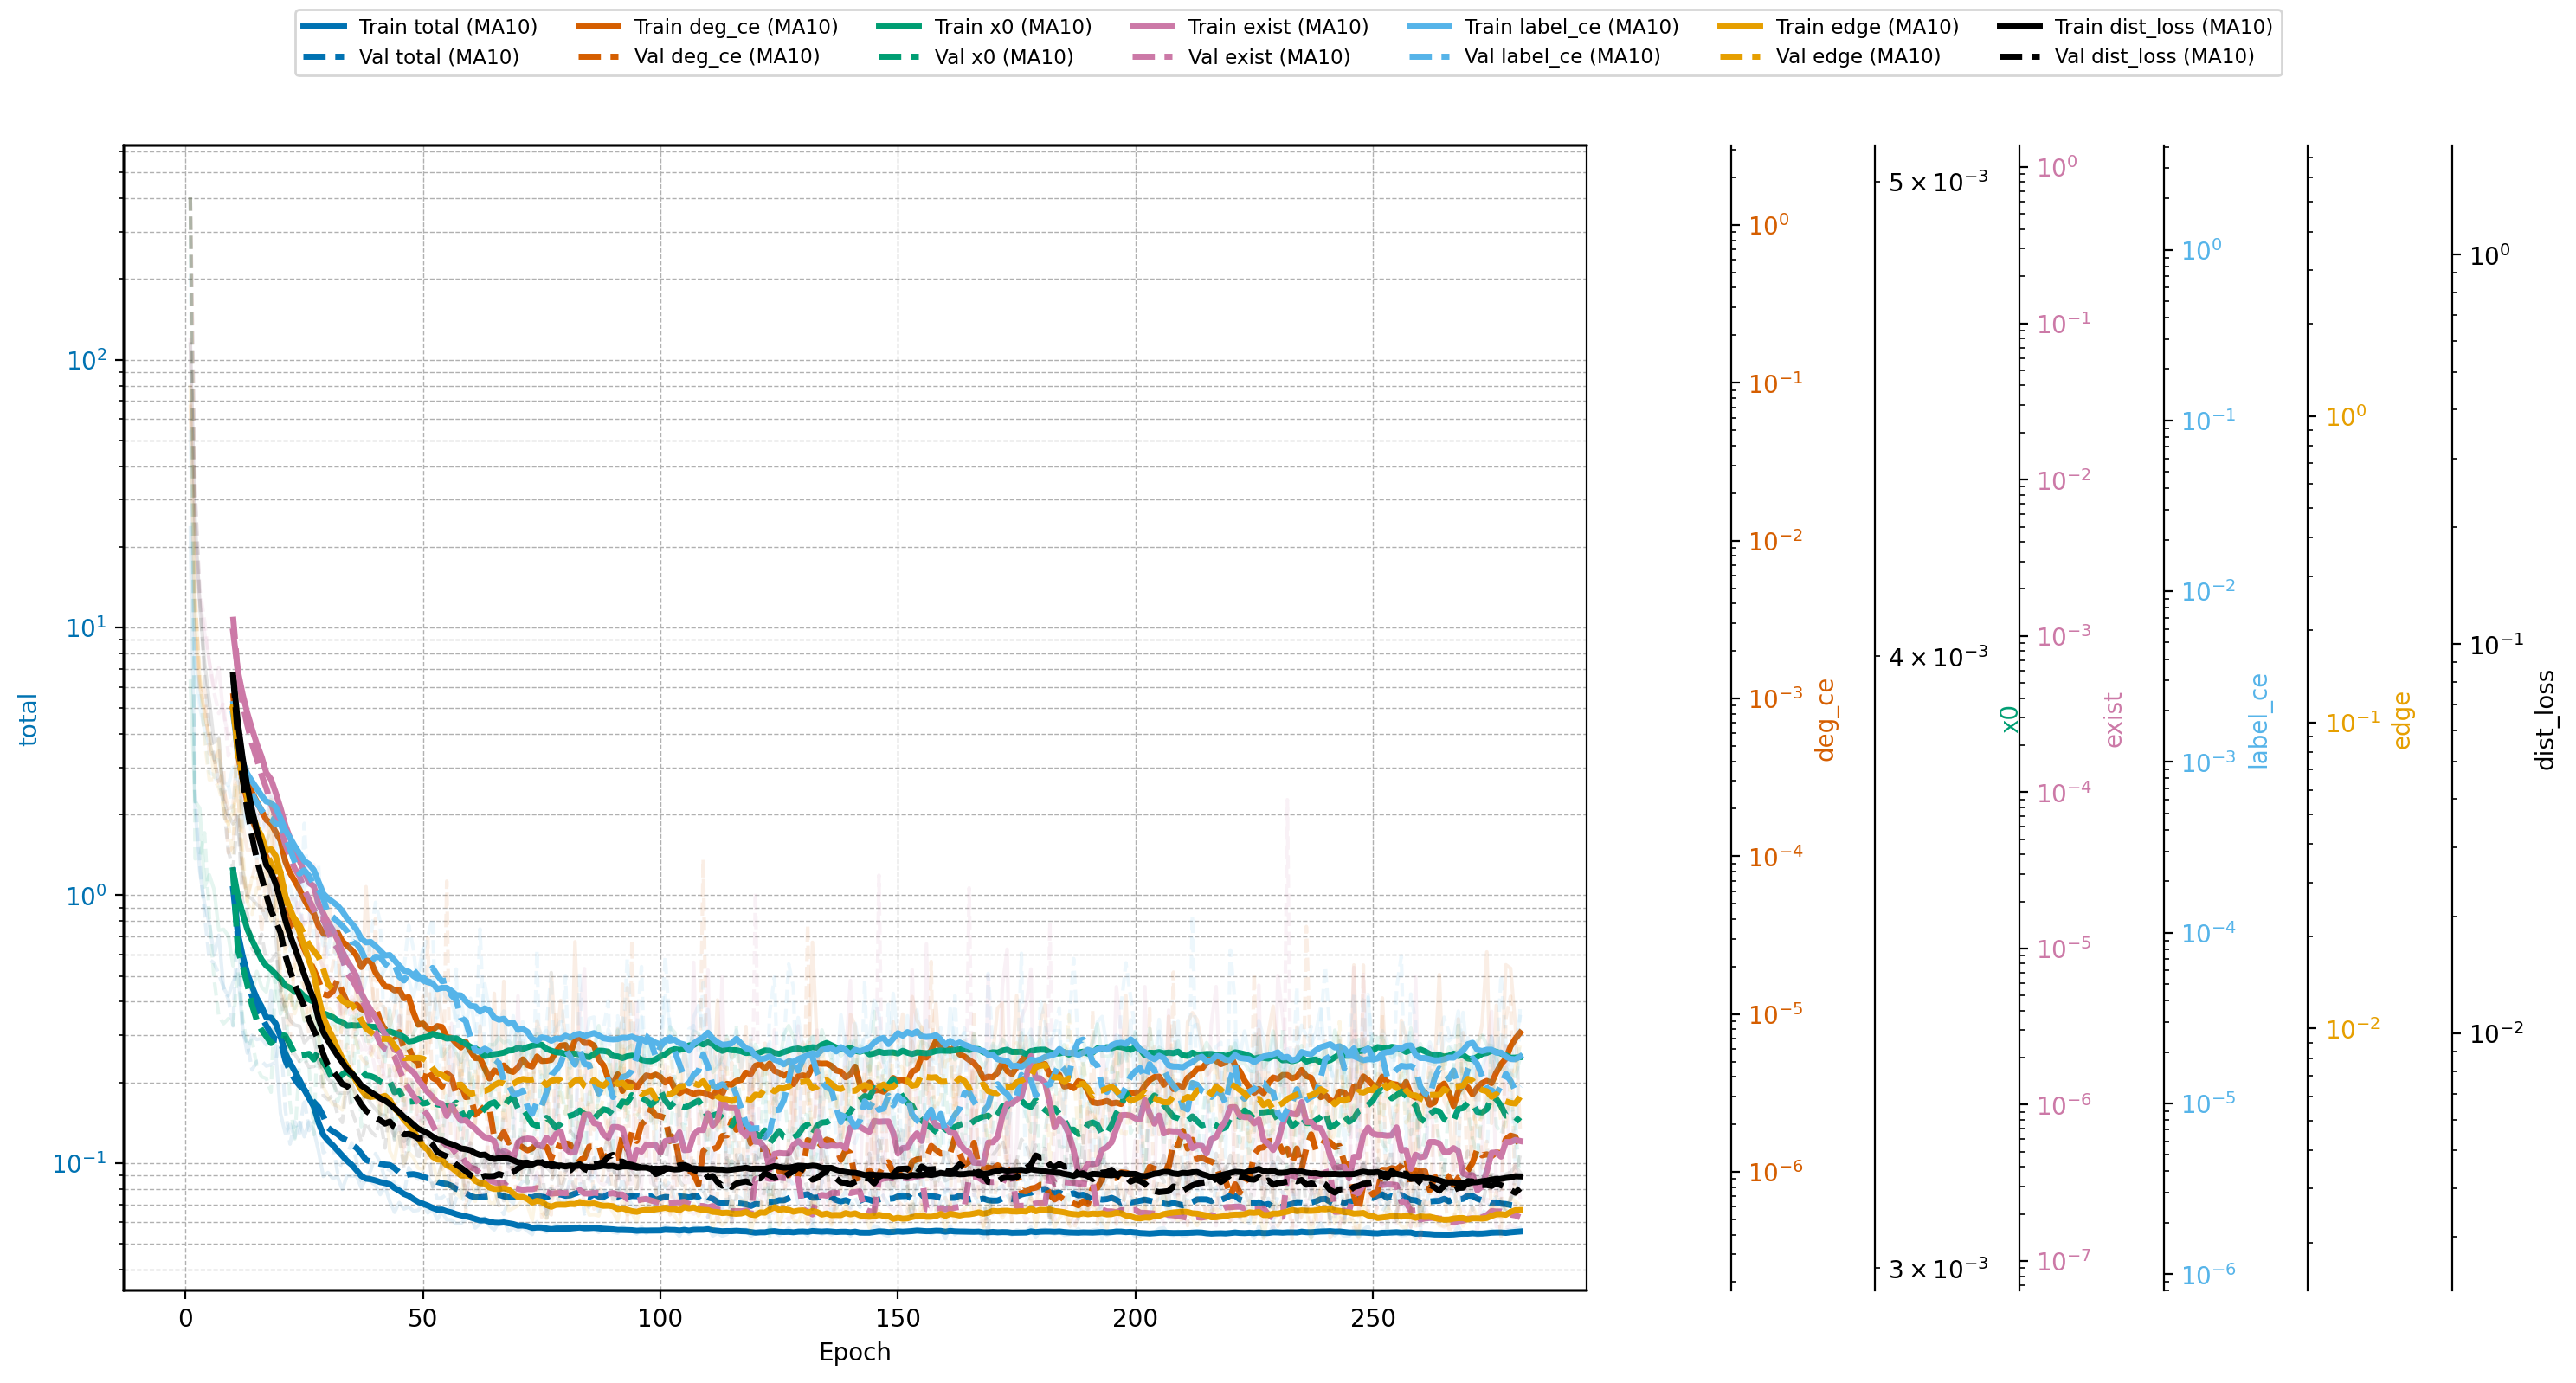

Class 'ConditionalNodeGeneratorModel', Function 'fit' executed in 6782.99 seconds (113.05 minutes, 1.88 hours).
No node label classifier provided — skipping training and using label IDs in enc[:,2] with the stored mapping.
Class 'DecompositionalNodeEncoderDecoder', Function 'node_label_classifier_fit' executed in 0.00 seconds (0.00 minutes, 0.00 hours).
No edge label classifier provided — skipping training.
Class 'DecompositionalNodeEncoderDecoder', Function 'edge_label_classifier_fit' executed in 0.00 seconds (0.00 minutes, 0.00 hours).
No adjacency matrix classifier provided — skipping training.
Class 'DecompositionalNodeEncoderDecoder', Function 'adjacency_matrix_classifier_fit' executed in 0.00 seconds (0.00 minutes, 0.00 hours).
Class 'DecompositionalNodeEncoderDecoder', Function 'fit' executed in 0.00 seconds (0.00 minutes, 0.00 hours).
Class 'DecompositionalEncoderDecoder', Function 'fit' executed in 6984.13 seconds (116.40 minutes, 1.94 hours).


Stored baseline training fingerprint: 28279e85d98a
CPU times: user 2h 21min 38s, sys: 30min 53s, total: 2h 52min 31s
Wall time: 1h 56min 24s


In [17]:
%%time
from condition_latent_comparison import graph_dataset_fingerprint

decompositional_encoder_decoder.fit(train_graphs, train_conditioning_to_node_embeddings_generator=True, train_node_embeddings_to_graph_generator=True)
decompositional_encoder_decoder._condition_training_fingerprint = graph_dataset_fingerprint(train_graphs)
print("Stored baseline training fingerprint:", decompositional_encoder_decoder._condition_training_fingerprint[:12])
# decompositional_encoder_decoder.conditioning_to_node_embeddings_generator.conditional_node_generator.plot_metrics(window=100)

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [18]:
# ===== Condition-control diagnostics =====
from collections import Counter

import numpy as np
import pandas as pd
from IPython.display import display

count_generator = (
    decompositional_encoder_decoder
    .conditioning_to_node_embeddings_generator
    .conditional_node_generator
)
valid_counts = list(getattr(count_generator, "valid_node_counts", []))
print("Valid training node counts:", valid_counts)


def _predict_condition_counts(graphs):
    conditions = np.asarray(
        decompositional_encoder_decoder.graph_encode(graphs),
        dtype=np.float32,
    )
    scaled_conditions = count_generator._transform_condition_data(conditions)
    true_counts = np.asarray(
        [graph.number_of_nodes() for graph in graphs],
        dtype=np.int64,
    )
    if count_generator.fixed_node_count is not None:
        predicted_counts = np.full(
            len(graphs),
            int(count_generator.fixed_node_count),
            dtype=np.int64,
        )
    elif count_generator.node_count_model is not None:
        predicted_counts = count_generator.node_count_model.predict(
            scaled_conditions
        ).astype(np.int64)
    else:
        return true_counts, None
    return true_counts, predicted_counts


node_count_enabled = bool(getattr(count_generator, "use_condition_node_count", False))
node_count_available = (
    getattr(count_generator, "fixed_node_count", None) is not None
    or getattr(count_generator, "node_count_model", None) is not None
)

print(
    "Node-count control:",
    "enabled" if node_count_enabled else "disabled",
)
if node_count_enabled and node_count_available:
    for split_name, split_graphs in (
        ("train", train_graphs),
        ("test", test_graphs),
    ):
        true_counts, predicted_counts = _predict_condition_counts(split_graphs)
        if predicted_counts is None:
            print(f"Skipping {split_name} node-count diagnostic: no fitted node-count model.")
            continue
        accuracy = float(np.mean(predicted_counts == true_counts))
        print(f"{split_name} node-count accuracy: {accuracy:.3f}")
        print("True counts     :", dict(Counter(true_counts)))
        print("Predicted counts:", dict(Counter(predicted_counts)))
        confusion = pd.crosstab(
            pd.Series(true_counts, name="true_count"),
            pd.Series(predicted_counts, name="predicted_count"),
        )
        display(confusion)
else:
    print("Skipping node-count prediction diagnostic: condition node-count control is off or unfitted.")

print(
    "Degree-histogram control:",
    "enabled" if getattr(count_generator, "use_condition_degree_histogram", False) else "disabled",
)
if getattr(count_generator, "fixed_degree_histogram", None) is not None:
    print(
        "Fixed degree histogram:",
        count_generator.fixed_degree_histogram.astype(int).tolist(),
    )
elif getattr(count_generator, "degree_histogram_model", None) is not None:
    print("Degree histogram is predicted from each condition.")
else:
    print("Skipping degree-histogram diagnostic: control is off or unfitted.")

print(
    "Label-histogram control:",
    "enabled" if getattr(count_generator, "use_condition_label_histogram", False) else "disabled",
)
if getattr(count_generator, "fixed_label_histogram", None) is not None:
    print(
        "Fixed label histogram:",
        count_generator.fixed_label_histogram.astype(int).tolist(),
    )
elif getattr(count_generator, "label_histogram_model", None) is not None:
    print("Label histogram is predicted from each condition.")
else:
    print("Skipping label-histogram diagnostic: control is off or unfitted.")


Valid training node counts: [7, 8, 9, 10, 11, 12, 13]
Encoding 18000 graphs


Class 'DecompositionalEncoderDecoder', Function 'graph_encode' executed in 92.37 seconds (1.54 minutes, 0.03 hours).


RuntimeError: The condition-to-node-count model was not fitted.

In [ ]:
%%time
if False:
    decompositional_encoder_decoder.fit_classifier(train_graphs, train_targets, epochs=50, lr=1e-4)

In [ ]:
import random
import numpy as np
import networkx as nx
from collections import Counter
from scipy.optimize import linear_sum_assignment
from networkx.algorithms import isomorphism as iso

DEBUG_N = min(30, len(train_graphs))
random.seed(123)
probe_graphs = random.sample(train_graphs, DEBUG_N)

node_encs, conds = decompositional_encoder_decoder.encode(probe_graphs)
cond_to_node = decompositional_encoder_decoder.conditioning_to_node_embeddings_generator
node_to_graph = decompositional_encoder_decoder.node_embeddings_to_graph_generator

pred_node_encs = cond_to_node.predict(conds)

decoded_true_x = node_to_graph.decode(node_encs, conditional_graph_encodings=conds)
decoded_pred_x = decompositional_encoder_decoder._decode_with_generated_edge_labels(
    conds, pred_node_encs
)

def coerce_label(x):
    try:
        f = float(x)
        if np.isfinite(f) and abs(f - round(f)) < 1e-9:
            return int(round(f))
    except Exception:
        pass
    return x

def graph_summary(graphs, name):
    nodes = [g.number_of_nodes() for g in graphs]
    edges = [g.number_of_edges() for g in graphs]
    degrees = [d for g in graphs for _, d in g.degree()]
    labels = [coerce_label(d.get("label")) for g in graphs for _, d in g.nodes(data=True)]

    print(f"\n=== {name} ===")
    print("node count:", Counter(nodes))
    print("edge count:", Counter(edges))
    print("degree hist:", Counter(degrees))
    print("node label hist:", Counter(labels))

def iso_summary(true_graphs, pred_graphs, name):
    node_match = iso.categorical_node_match("label", None)

    labeled = 0
    unlabeled = 0
    same_counts = 0
    same_degrees = 0
    same_labels = 0

    for G, H in zip(true_graphs, pred_graphs):
        G = G.copy()
        H = H.copy()

        for _, d in G.nodes(data=True):
            d["label"] = coerce_label(d.get("label"))
        for _, d in H.nodes(data=True):
            d["label"] = coerce_label(d.get("label"))

        labeled += nx.is_isomorphic(G, H, node_match=node_match)
        unlabeled += nx.is_isomorphic(G, H)
        same_counts += (
            G.number_of_nodes() == H.number_of_nodes()
            and G.number_of_edges() == H.number_of_edges()
        )
        same_degrees += Counter(dict(G.degree()).values()) == Counter(dict(H.degree()).values())
        same_labels += (
            Counter(d.get("label") for _, d in G.nodes(data=True))
            == Counter(d.get("label") for _, d in H.nodes(data=True))
        )

    print(f"\n=== {name} ===")
    print(f"labeled iso: {labeled} / {len(true_graphs)}")
    print(f"unlabeled iso: {unlabeled} / {len(true_graphs)}")
    print(f"same node/edge counts: {same_counts} / {len(true_graphs)}")
    print(f"same degree hist: {same_degrees} / {len(true_graphs)}")
    print(f"same label hist: {same_labels} / {len(true_graphs)}")

def matched_cx_summary(true_Xs, pred_Xs, label_col=2):
    idx_to_label = getattr(
        decompositional_encoder_decoder,
        "_idx_to_label",
        {},
    )
    print("internal label mapping:", idx_to_label)

    degree_hits = label_hits = total = 0
    true_deg, pred_deg, true_lab, pred_lab = [], [], [], []

    for X, Y in zip(true_Xs, pred_Xs):
        X, Y = np.asarray(X), np.asarray(Y)
        d = min(X.shape[1], Y.shape[1])
        X, Y = X[:, :d], Y[:, :d]

        T = X[X[:, 0] > 0.5]
        P = Y[Y[:, 0] > 0.5]
        n = min(len(T), len(P))
        if n == 0:
            continue

        T, P = T[:n], P[:n]

        # Match using structural features only.
        start, stop = 3, min(d, 64)
        if stop > start:
            cost = ((P[:, None, start:stop] -
                     T[None, :, start:stop]) ** 2).mean(-1)
        else:
            cost = ((P[:, None, 1:2] -
                     T[None, :, 1:2]) ** 2).mean(-1)

        pred_i, true_i = linear_sum_assignment(cost)
        P, T = P[pred_i], T[true_i]

        td = np.rint(T[:, 1]).astype(int)
        pd = np.rint(P[:, 1]).astype(int)
        tl = np.rint(T[:, label_col]).astype(int)
        pl = np.rint(P[:, label_col]).astype(int)

        degree_hits += np.sum(td == pd)
        label_hits += np.sum(tl == pl)
        total += n

        true_deg.extend(td)
        pred_deg.extend(pd)

        # Convert internal indices back to dataset labels.
        true_lab.extend(coerce_label(idx_to_label.get(int(v), v)) for v in tl)
        pred_lab.extend(coerce_label(idx_to_label.get(int(v), v)) for v in pl)

    print("\n=== matched C -> X ===")
    print("matched degree acc:", degree_hits / max(total, 1))
    print("matched label acc:", label_hits / max(total, 1))
    print("true degree hist:", Counter(true_deg))
    print("pred degree hist:", Counter(pred_deg))
    print("true label hist:", Counter(true_lab))
    print("pred label hist:", Counter(pred_lab))
graph_summary(probe_graphs, "real graphs")
graph_summary(decoded_true_x, "decoded from true X0")
graph_summary(decoded_pred_x, "decoded from generated C -> X")

iso_summary(probe_graphs, decoded_true_x, "true X0 decoder check")
iso_summary(probe_graphs, decoded_pred_x, "generated C -> X graph check")

matched_cx_summary(node_encs, pred_node_encs)

In [ ]:
# import dill as pickle
# from pathlib import Path

# SAVE_FULL_GENERATOR = True
# FULL_GENERATOR_PATH = Path(f"{dataset_name}_decompositional_encoder_decoder.pkl")

# if SAVE_FULL_GENERATOR:
#     with FULL_GENERATOR_PATH.open("wb") as f:
#         pickle.dump(decompositional_encoder_decoder, f)

#     print(f"saved full generator to: {FULL_GENERATOR_PATH.resolve()}")
# else:
#     import dill as pickle

# with open(f"{dataset_name}_decompositional_encoder_decoder.pkl", "rb") as f:
#     loaded_decoder = pickle.load(f)

# sampled_graphs = loaded_decoder.sample(n_samples=10)
# print("SAVE_FULL_GENERATOR is False; skipped.")
# plot_networkx_graphs(
#     sampled_graphs,
#     n_cols=10,
#     node_label_attr="label",
#     edge_label_attr="label",
#     node_size=210,
#     edge_width=2.2,
#     layout="kamada_kawai",
# )

In [ ]:
def plot_graphs_auto(
    graphs,
    targets=None,
    *,
    size=2,
    label_to_idx=None,
    unlabeled="__UNLABELED__",
    title=None,
    binary_positive_class=1,
    node_label_source="generated",
    n_graphs_per_line=None,
    node_label_attr="label",
    edge_label_attr="label",
):
    """
    Compatible with the new plot_networkx_graphs().

    Uses stable hash colors from node/edge labels.
    No POS_PALETTE / NEG_PALETTE / display_graphs dependency.
    """
    graphs = list(graphs)

    if len(graphs) == 0:
        print("no graphs to display")
        return graphs, label_to_idx

    if title is not None:
        print(title)

    info = infer_display_case(graphs, targets, unlabeled=unlabeled)
    normalized_targets = info["targets"]
    unique_targets = info["classes"]

    n_cols = n_graphs_per_line if n_graphs_per_line is not None else len(graphs)
    node_size = int(105 * size)
    edge_width = max(1.4, 1.1 * size)

    if info["graph_case"] == "binary" and normalized_targets is not None:
        pos_class = binary_positive_class if binary_positive_class in unique_targets else unique_targets[0]
        neg_class = [cls for cls in unique_targets if cls != pos_class][0]

        pos_graphs = [g for g, t in zip(graphs, normalized_targets) if t == pos_class]
        neg_graphs = [g for g, t in zip(graphs, normalized_targets) if t == neg_class]

        print(f"graph classes: pos={pos_class}, neg={neg_class} | node labels: {node_label_source}")

        if pos_graphs:
            print("positive graphs")
            plot_networkx_graphs(
                pos_graphs,
                n_cols=n_cols,
                node_label_attr=node_label_attr,
                edge_label_attr=edge_label_attr,
                node_size=node_size,
                edge_width=edge_width,
                layout="kamada_kawai",
            )

        if neg_graphs:
            print("negative graphs")
            plot_networkx_graphs(
                neg_graphs,
                n_cols=n_cols,
                node_label_attr=node_label_attr,
                edge_label_attr=edge_label_attr,
                node_size=node_size,
                edge_width=edge_width,
                layout="kamada_kawai",
            )

        return graphs, label_to_idx

    ordered_graphs = graphs

    if normalized_targets is not None and len(unique_targets) > 0:
        ordered_graphs = []
        for cls in unique_targets:
            ordered_graphs.extend([g for g, t in zip(graphs, normalized_targets) if t == cls])
        ordered_graphs.extend([g for g, t in zip(graphs, normalized_targets) if t is None])

        class_summary = ", ".join(str(cls) for cls in unique_targets)
        if any(t is None for t in normalized_targets):
            class_summary += ", unlabeled"
        print(f"graph classes: {class_summary} | node labels: {node_label_source}")
    else:
        print(f"graph classes: unlabeled | node labels: {node_label_source}")

    plot_networkx_graphs(
        ordered_graphs,
        n_cols=n_cols,
        node_label_attr=node_label_attr,
        edge_label_attr=edge_label_attr,
        node_size=node_size,
        edge_width=edge_width,
        layout="kamada_kawai",
    )

    return graphs, label_to_idx


In [ ]:
def _coerce_value(value, missing=None):
    if value is None:
        return missing
    if isinstance(value, str) and value.strip() == "":
        return missing
    try:
        f = float(value)
        if np.isnan(f):
            return missing
        if np.isfinite(f) and abs(f - round(f)) < 1e-9:
            return int(round(f))
    except Exception:
        pass
    return str(value)


def normalize_display_labels(
    graphs,
    label_to_idx=None,
    unlabeled="__UNLABELED__",
    source_attrs=("label", "plot_label", "display_label"),
    output_attr="display_label",
):
    """
    Converts node labels into stable integer display labels.

    Reads first available attr from:
      label -> plot_label -> display_label

    Writes:
      node[output_attr]

    Returns:
      graphs, label_to_idx
    """
    graphs = list(graphs)

    if label_to_idx is None:
        raw_labels = []

        for g in graphs:
            for _, data in g.nodes(data=True):
                raw = unlabeled
                for attr in source_attrs:
                    if attr in data:
                        raw = data[attr]
                        break
                raw_labels.append(_coerce_value(raw, missing=unlabeled))

        uniq = list(dict.fromkeys(raw_labels)) or [unlabeled]

        if unlabeled not in uniq:
            uniq.append(unlabeled)

        label_to_idx = {lab: i for i, lab in enumerate(uniq)}

    default_id = label_to_idx.get(unlabeled, 0)

    for g in graphs:
        for _, data in g.nodes(data=True):
            raw = unlabeled
            for attr in source_attrs:
                if attr in data:
                    raw = data[attr]
                    break

            label = _coerce_value(raw, missing=unlabeled)
            data[output_attr] = int(label_to_idx.get(label, default_id))

    return graphs, label_to_idx
def _normalize_targets(targets):
    if targets is None:
        return None
    return [_coerce_value(t, missing=None) for t in targets]


def _unique_present(values):
    out = []
    for value in values:
        if value is None:
            continue
        if value not in out:
            out.append(value)
    return out


def infer_display_case(graphs=None, targets=None, unlabeled="__UNLABELED__"):
    normalized_targets = _normalize_targets(targets)
    unique_targets = _unique_present(normalized_targets or [])

    have_node_labels = False
    if graphs is not None:
        for g in graphs:
            for _, data in g.nodes(data=True):
                raw = data.get("display_label", data.get("plot_label", data.get("label", unlabeled)))
                if _coerce_value(raw, missing=unlabeled) != unlabeled:
                    have_node_labels = True
                    break
            if have_node_labels:
                break

    if normalized_targets is None or len(unique_targets) == 0:
        graph_case = "unlabeled"
    elif len(unique_targets) == 2 and all(t is not None for t in normalized_targets):
        graph_case = "binary"
    else:
        graph_case = "multiclass"

    return {
        "graph_case": graph_case,
        "node_case": "labeled" if have_node_labels else "unlabeled",
        "targets": normalized_targets,
        "classes": unique_targets,
    }


def sample_graphs_for_display(
    graphs,
    targets=None,
    *,
    binary_n_per_class=5,
    multiclass_n_per_class=3,
    unlabeled_n=10,
):
    graphs = list(graphs)

    if targets is None or len(targets) != len(graphs):
        sampled_graphs = random.sample(graphs, min(unlabeled_n, len(graphs)))
        info = infer_display_case(sampled_graphs, None)
        return sampled_graphs, None, info

    normalized_targets = _normalize_targets(targets)
    unique_targets = _unique_present(normalized_targets)

    if len(unique_targets) == 0:
        sampled_graphs = random.sample(graphs, min(unlabeled_n, len(graphs)))
        info = infer_display_case(sampled_graphs, None)
        return sampled_graphs, None, info

    per_class = binary_n_per_class if len(unique_targets) == 2 else multiclass_n_per_class
    sampled_pairs = []

    for cls in unique_targets:
        pool = [(g, t) for g, t in zip(graphs, normalized_targets) if t == cls]
        sampled_pairs.extend(random.sample(pool, min(per_class, len(pool))))

    random.shuffle(sampled_pairs)
    sampled_graphs = [g for g, _ in sampled_pairs]
    sampled_targets = [t for _, t in sampled_pairs]
    info = infer_display_case(sampled_graphs, sampled_targets)
    return sampled_graphs, sampled_targets, info


In [ ]:
# ===== Decode generated graphs from only one graph class =====
# Example: decode 10 graphs from one class and 0 from the other.
# This uses class-specific training graphs as conditioning seeds.
import random
from collections import Counter

DECODE_CLASS_COUNTS = None
DECODE_ONLY_CLASS = 1       # if present; otherwise the first available class is used
DECODE_ONLY_N = 10
DECODE_CLASS_SEED = int(globals().get("SEED", 42))
DECODE_CLASS_TOTAL_STEPS = 100
DECODE_CLASS_N_COLS = 10

class_decoded_graphs = []
seed_graphs = []
seed_targets = []

if "train_targets" not in globals() or train_targets is None:
    print("class-specific decoding skipped: train_targets is unlabeled/missing")
else:
    _targets = list(train_targets)
    _classes = sorted(set(_targets), key=lambda x: repr(x))
    if not _classes:
        print("class-specific decoding skipped: no graph classes found in train_targets")
    else:
        if DECODE_CLASS_COUNTS is None:
            chosen_class = DECODE_ONLY_CLASS if DECODE_ONLY_CLASS in set(_classes) else _classes[0]
            DECODE_CLASS_COUNTS = {cls: (int(DECODE_ONLY_N) if cls == chosen_class else 0) for cls in _classes}

        print("available train classes:", dict(Counter(_targets)))
        print("decode class counts:", DECODE_CLASS_COUNTS)

        _rng = random.Random(DECODE_CLASS_SEED)

        for cls in _classes:
            n_cls = int(DECODE_CLASS_COUNTS.get(cls, 0))
            if n_cls <= 0:
                continue
            cls_graphs = [g for g, y in zip(train_graphs, _targets) if y == cls]
            if not cls_graphs:
                print(f"[warn] no training graphs for class={cls!r}")
                continue
            seeds = _rng.choices(cls_graphs, k=n_cls)
            seed_graphs.extend(seeds)
            seed_targets.extend([cls] * len(seeds))

        if not seed_graphs:
            print("class-specific decoding skipped: no seed graphs selected")
        else:
            _gen = decompositional_encoder_decoder.conditioning_to_node_embeddings_generator.conditional_node_generator
            _old_steps = getattr(_gen, "total_steps", None)
            _gen.total_steps = int(DECODE_CLASS_TOTAL_STEPS)

            _, class_conditioning_encs = decompositional_encoder_decoder.encode(seed_graphs)
            class_decoded_graphs = decompositional_encoder_decoder.decode(class_conditioning_encs)

            if _old_steps is not None:
                _gen.total_steps = _old_steps

            # Normalize display labels if those helpers were already defined.
            if "normalize_display_labels" in globals():
                all_graphs = list(seed_graphs) + list(class_decoded_graphs)
                _, _label_to_idx = normalize_display_labels(all_graphs, label_to_idx=None)
                seed_graphs, _ = normalize_display_labels(seed_graphs, label_to_idx=_label_to_idx)
                class_decoded_graphs, _ = normalize_display_labels(class_decoded_graphs, label_to_idx=_label_to_idx)
                _node_label_attr = "label"
                _edge_label_attr = "label"
            else:
                _node_label_attr = "label"
                _edge_label_attr = "label"

            print("decoded class counts:", dict(Counter(seed_targets)))

            if "plot_networkx_graphs" in globals():
                _n_cols = min(int(DECODE_CLASS_N_COLS), len(class_decoded_graphs))

                print("true conditioning seed graphs")
                plot_networkx_graphs(
                    seed_graphs,
                    n_cols=_n_cols,
                    figsize_per_graph=(2.2, 2.0),
                    node_label_attr=_node_label_attr,
                    edge_label_attr=_edge_label_attr,
                    node_size=140,
                    edge_width=1.7,
                    font_size=7,
                    layout="kamada_kawai",
                )

                print("decoded/generated from selected class conditioning")
                plot_networkx_graphs(
                    class_decoded_graphs,
                    n_cols=_n_cols,
                    figsize_per_graph=(2.2, 2.0),
                    node_label_attr=_node_label_attr,
                    edge_label_attr=_edge_label_attr,
                    node_size=140,
                    edge_width=1.7,
                    font_size=7,
                    layout="kamada_kawai",
                )
            else:
                print("true conditioning seed graphs:", seed_graphs)
                print("decoded/generated graphs:", class_decoded_graphs)


In [ ]:
# =============== MAIN ===============
print("true graphs")
import random
import numpy as np

steps_to_show = [75,100,300,500]   # keep one generated row; add more if you want
n_graphs_per_line = 10

probe_train_graphs, probe_train_targets, probe_info = sample_graphs_for_display(
    train_graphs,
    train_targets if "train_targets" in globals() else None,
    binary_n_per_class=5,
    multiclass_n_per_class=3,
    unlabeled_n=10,
)

print(f"display case: {probe_info['graph_case']} | node labels: {probe_info['node_case']}")

node_encs_list, conditioning_encs = decompositional_encoder_decoder.encode(probe_train_graphs)

decoded_graphs = decompositional_encoder_decoder.node_embeddings_to_graph_generator.decode(
    node_encs_list
)

conditioning_decoded_by_steps = {}
_original_total_steps = conditional_node_generator_model.total_steps

for steps in steps_to_show:
    conditional_node_generator_model.total_steps = steps
    conditioning_decoded_by_steps[steps] = decompositional_encoder_decoder.decode(conditioning_encs)

conditional_node_generator_model.total_steps = _original_total_steps

# Shared label map across all rows.
all_graphs = []
all_graphs.extend(probe_train_graphs)
all_graphs.extend(decoded_graphs)
for steps in steps_to_show:
    all_graphs.extend(conditioning_decoded_by_steps[steps])

_, label_to_idx = normalize_display_labels(all_graphs, label_to_idx=None)

probe_train_graphs, _ = normalize_display_labels(probe_train_graphs, label_to_idx=label_to_idx)
decoded_graphs, _ = normalize_display_labels(decoded_graphs, label_to_idx=label_to_idx)

for steps in steps_to_show:
    conditioning_decoded_by_steps[steps], _ = normalize_display_labels(
        conditioning_decoded_by_steps[steps],
        label_to_idx=label_to_idx,
    )


def _order_graphs_one_line(graphs, targets):
    """
    Binary: keeps classes grouped on one line, e.g. 5 pos then 5 neg.
    Multiclass: groups each class in order.
    Unlabeled: original order.
    """
    info = infer_display_case(graphs, targets)
    normalized_targets = info["targets"]
    classes = info["classes"]

    if normalized_targets is None or len(classes) == 0:
        return list(graphs), info

    ordered = []
    for cls in classes:
        ordered.extend([
            g for g, t in zip(graphs, normalized_targets)
            if t == cls
        ])

    return ordered, info


def _plot_stage_one_line(graphs, targets, title, node_label_source):
    ordered_graphs, info = _order_graphs_one_line(graphs, targets)
    classes = info["classes"]

    if len(classes) == 0:
        print(f"{title} | graph classes: unlabeled | node labels: {node_label_source}")
    else:
        counts = {
            cls: sum(t == cls for t in info["targets"])
            for cls in classes
        }
        print(f"{title} | graph classes: {counts} | node labels: {node_label_source}")

    plot_networkx_graphs(
        ordered_graphs,
        n_cols=len(ordered_graphs),
        node_label_attr="label",
        edge_label_attr="label",
        node_size=210,
        edge_width=2.2,
        layout="kamada_kawai",
    )


_plot_stage_one_line(
    probe_train_graphs,
    probe_train_targets,
    "true graphs",
    "true",
)

_plot_stage_one_line(
    decoded_graphs,
    probe_train_targets,
    "decoded from node encs",
    "decoded",
)

for steps in steps_to_show:
    _plot_stage_one_line(
        conditioning_decoded_by_steps[steps],
        probe_train_targets,
        f"generated from graph encs, steps={steps}",
        f"generated, steps={steps}",
    )


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional

def compare_degree_histograms(
        true_encodings_list,
        pred_encodings_list,
        title: str = "Degree distribution (true vs. predicted)",
        ax: Optional[plt.Axes] = None,
        true_label: str = "True",
        pred_label: str = "Predicted",
        true_color: str = "tab:blue",
        pred_color: str = "tab:orange",
        alpha: float = 0.6,
        exist_threshold: float = 0.5,
    ):
    """
    Plot overlaid histograms of node degrees (column 1) for true and predicted encodings,
    *excluding* rows where existence flag (column 0) < `exist_threshold`.

    Parameters
    ----------
    true_encodings_list, pred_encodings_list : list[np.ndarray]
        Lists of (N_i, D) arrays in raw (un-scaled) space.
    exist_threshold : float
        Rows with existence flag below this value are ignored.
    """

    def extract_valid_degrees(enc_list):
        degs = []
        for m in enc_list:
            mask = m[:, 0] >= exist_threshold    # keep only existent nodes
            if mask.any():
                degs.append(m[mask, 1])
        if not degs:
            return np.array([], dtype=int)
        return np.concatenate(degs)

    # 1. gather degrees
    true_deg = extract_valid_degrees(true_encodings_list).round().astype(int)
    pred_deg = extract_valid_degrees(pred_encodings_list).round().astype(int)

    if true_deg.size == 0 and pred_deg.size == 0:
        raise ValueError("No nodes passed the existence threshold in either list.")

    # 2. integer-aligned bin edges
    max_k = int(max(true_deg.max(initial=0), pred_deg.max(initial=0)))
    bins  = np.arange(-0.5, max_k + 1.5, 1)     # one bin per integer

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    # 3. plot histograms
    if true_deg.size:
        ax.hist(true_deg, bins=bins, alpha=alpha,
                color=true_color, label=true_label, edgecolor="k")
    if pred_deg.size:
        ax.hist(pred_deg, bins=bins, alpha=alpha,
                color=pred_color, label=pred_label, edgecolor="k")

    # 4. cosmetics
    ax.set_xticks(np.arange(0, max_k + 1))
    ax.set_xlabel("Degree")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    return ax


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

random.seed(0)

n = min(40, len(train_graphs))
probe_train_graphs = random.sample(train_graphs, n)

node_encs, conditioning_encodings = decompositional_encoder_decoder.encode(probe_train_graphs)

predicted_node_encodings_list = (
    decompositional_encoder_decoder
    .conditioning_to_node_embeddings_generator
    .predict(conditioning_encodings)
)


def safe_corr(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    m = min(x.size, y.size)
    x = x[:m]
    y = y[:m]

    if m == 0:
        return np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan

    return float(np.corrcoef(x, y)[0, 1])


def align_node_matrices(true_enc, pred_enc):
    A = np.asarray(true_enc, dtype=float)
    B = np.asarray(pred_enc, dtype=float)

    n_rows = min(A.shape[0], B.shape[0])
    n_cols = min(A.shape[1], B.shape[1])

    return A[:n_rows, :n_cols], B[:n_rows, :n_cols]


def degree_vector(enc, existence_threshold=0.5):
    enc = np.asarray(enc, dtype=float)
    if enc.ndim != 2 or enc.shape[1] < 2:
        return np.array([], dtype=int)

    mask = enc[:, 0] > existence_threshold
    return np.rint(enc[mask, 1]).astype(int)


def presence_count(enc, existence_threshold=0.5):
    enc = np.asarray(enc, dtype=float)
    if enc.ndim != 2 or enc.shape[1] < 1:
        return 0

    return int((enc[:, 0] > existence_threshold).sum())


# ---------------- Correlations: true X vs predicted X ----------------
ccs = []
true_flat_all = []
pred_flat_all = []

for true_nodes, pred_nodes in zip(node_encs, predicted_node_encodings_list):
    A, B = align_node_matrices(true_nodes, pred_nodes)

    ccs.append(safe_corr(A, B))
    true_flat_all.append(A.ravel())
    pred_flat_all.append(B.ravel())

data_real = np.concatenate(true_flat_all) if true_flat_all else np.array([])
data_pred = np.concatenate(pred_flat_all) if pred_flat_all else np.array([])
overall_corr = safe_corr(data_real, data_pred)

finite_ccs = [c for c in ccs if np.isfinite(c)]

print("=== shape debug ===")
print("conditioning C dim:", np.asarray(conditioning_encodings[0]).shape)
print("true node X shape:", np.asarray(node_encs[0]).shape)
print("pred node X shape:", np.asarray(predicted_node_encodings_list[0]).shape)
print("finite node-X correlations:", len(finite_ccs), "/", len(ccs))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(ccs, "o")
ax1.set_ylim(-1, 1)
ax1.set_xlabel("Instance ID")
ax1.set_ylabel("Corr coeff")
ax1.set_title("True X vs Predicted X")
ax1.grid(True)

if finite_ccs:
    ax2.hist(finite_ccs, bins=8, edgecolor="black")
else:
    ax2.text(0.5, 0.5, "No finite values", ha="center", va="center")

ax2.set_xlabel("Correlation coefficient")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of X Correlations")
ax2.grid(axis="y", linestyle="--", alpha=0.5)

if data_pred.size and data_real.size:
    min_val = float(min(data_real.min(), data_pred.min()))
    max_val = float(max(data_real.max(), data_pred.max()))
    if min_val == max_val:
        min_val -= 1
        max_val += 1

    lims = [min_val, max_val]
    ax3.scatter(data_real, data_pred, alpha=0.08, s=8)
    ax3.plot(lims, lims, "k--", linewidth=1, alpha=0.5)
    ax3.set_xlim(lims)
    ax3.set_ylim(lims)
else:
    ax3.text(0.5, 0.5, "No values", ha="center", va="center")

ax3.set_xlabel("True node-encoding values")
ax3.set_ylabel("Predicted node-encoding values")
ax3.set_title(f"True X vs Predicted X (r = {overall_corr:.3f})")
ax3.grid(True)

plt.tight_layout()
plt.show()


# ---------------- Summary stats ----------------
median_r = np.nanmedian(ccs) if finite_ccs else np.nan
mean_r = np.nanmean(ccs) if finite_ccs else np.nan

true_node_counts = [presence_count(enc) for enc in node_encs]
pred_node_counts = [presence_count(enc) for enc in predicted_node_encodings_list]

true_degrees = [degree_vector(enc) for enc in node_encs]
pred_degrees = [degree_vector(enc) for enc in predicted_node_encodings_list]

true_degree_flat = np.concatenate(true_degrees) if true_degrees else np.array([], dtype=int)
pred_degree_flat = np.concatenate(pred_degrees) if pred_degrees else np.array([], dtype=int)

print("=== node-encoding reconstruction stats ===")
print(f"n graphs used: {n}")
print(f"median r: {median_r:.3f} | mean r: {mean_r:.3f} | overall r: {overall_corr:.3f}")

print()
print("=== node-count stats ===")
print(f"true node count: mean={np.mean(true_node_counts):.2f}, min={np.min(true_node_counts)}, max={np.max(true_node_counts)}")
print(f"pred node count: mean={np.mean(pred_node_counts):.2f}, min={np.min(pred_node_counts)}, max={np.max(pred_node_counts)}")
print(f"node count abs error: mean={np.mean(np.abs(np.array(true_node_counts) - np.array(pred_node_counts))):.2f}")

print()
print("=== degree stats ===")
print("true degree hist:", dict(Counter(true_degree_flat.tolist())))
print("pred degree hist:", dict(Counter(pred_degree_flat.tolist())))

if "compare_degree_histograms" in globals():
    compare_degree_histograms(node_encs, predicted_node_encodings_list)
    plt.show()
# ---------------- Graph/motif stats ----------------
import networkx as nx
from collections import Counter

def graph_motif_stats(graphs, name):
    node_counts = Counter(g.number_of_nodes() for g in graphs)
    edge_counts = Counter(g.number_of_edges() for g in graphs)
    degree_counts = Counter(d for g in graphs for _, d in g.degree())
    triangle_counts = Counter(sum(nx.triangles(g).values()) // 3 for g in graphs)
    cycle_counts = Counter(len(nx.cycle_basis(g)) for g in graphs)

    print()
    print(f"=== graph motif stats: {name} ===")
    print("nodes    :", dict(node_counts))
    print("edges    :", dict(edge_counts))
    print("degrees  :", dict(degree_counts))
    print("triangles:", dict(triangle_counts))
    print("cycles   :", dict(cycle_counts))

    return {
        "nodes": node_counts,
        "edges": edge_counts,
        "degrees": degree_counts,
        "triangles": triangle_counts,
        "cycles": cycle_counts,
    }


def exact_match_rate(true_graphs, pred_graphs, stat_fn, name):
    vals_true = [stat_fn(g) for g in true_graphs]
    vals_pred = [stat_fn(g) for g in pred_graphs]
    n_pair = min(len(vals_true), len(vals_pred))

    if n_pair == 0:
        print(f"{name}: no paired graphs")
        return np.nan

    rate = np.mean([
        vals_true[i] == vals_pred[i]
        for i in range(n_pair)
    ])

    print(f"{name}: {rate:.3f} ({int(rate * n_pair)}/{n_pair})")
    return rate


# Decode predicted node encodings into graphs.
decoded_pred_graphs = decompositional_encoder_decoder.node_embeddings_to_graph_generator.decode(
    predicted_node_encodings_list,
    conditional_graph_encodings=conditioning_encodings,
)

true_graph_stats = graph_motif_stats(probe_train_graphs, "true probe graphs")
pred_graph_stats = graph_motif_stats(decoded_pred_graphs, "decoded predicted X graphs")

print()
print("=== paired exact graph-stat match rates ===")
exact_match_rate(
    probe_train_graphs,
    decoded_pred_graphs,
    lambda g: g.number_of_nodes(),
    "node count",
)
exact_match_rate(
    probe_train_graphs,
    decoded_pred_graphs,
    lambda g: g.number_of_edges(),
    "edge count",
)
exact_match_rate(
    probe_train_graphs,
    decoded_pred_graphs,
    lambda g: tuple(sorted(dict(g.degree()).values())),
    "sorted degree sequence",
)
exact_match_rate(
    probe_train_graphs,
    decoded_pred_graphs,
    lambda g: sum(nx.triangles(g).values()) // 3,
    "triangle count",
)
exact_match_rate(
    probe_train_graphs,
    decoded_pred_graphs,
    lambda g: len(nx.cycle_basis(g)),
    "cycle count",
)


In [ ]:
import pickle
from pathlib import Path

SAVE_GENERATED_GRAPHS = False

# Options:
#   "manual"      -> use MANUAL_N_GENERATED
#   "train1"      -> len(train1_graphs)
#   "train_whole" -> len(train_whole_graphs)
#   "train"       -> len(train_graphs)
N_GENERATED_MODE = "manual"

MANUAL_N_GENERATED = 100

GENERATED_GRAPH_PATH = Path("generated_graphs.pkl")

if SAVE_GENERATED_GRAPHS:
    if N_GENERATED_MODE == "manual":
        n_generated = int(MANUAL_N_GENERATED)
    elif N_GENERATED_MODE == "train1":
        n_generated = len(train1_graphs)
    elif N_GENERATED_MODE == "train_whole":
        n_generated = len(train_whole_graphs)
    elif N_GENERATED_MODE == "train":
        n_generated = len(train_graphs)
    else:
        raise ValueError("N_GENERATED_MODE must be 'manual', 'train1', 'train_whole', or 'train'")

    print(f"generating {n_generated} graphs...")

    generated_graphs = decompositional_encoder_decoder.sample(n_samples=n_generated)

    payload = {
        "generated_graphs": generated_graphs,
        "n_generated": n_generated,
        "mode": N_GENERATED_MODE,
        "dataset_name": globals().get("dataset_name", None),
        "total_steps": getattr(conditional_node_generator_model, "total_steps", None),
        "use_label_offset": globals().get("use_label_offset", None),
    }

    with GENERATED_GRAPH_PATH.open("wb") as f:
        pickle.dump(payload, f)

    print(f"saved generated graphs to: {GENERATED_GRAPH_PATH.resolve()}")
else:
    print("SAVE_GENERATED_GRAPHS is False; skipped saving.")


In [ ]:
# ===== NSPPK train/generated diagnostics on a sampled subset =====
# Uses up to NSPPK_DIAG_N_REAL training graphs and NSPPK_DIAG_N_GENERATED generated graphs.
# If graph targets are available with >=2 classes, reports supervised F1/accuracy too.
from IPython.display import display as ipy_display
from collections import Counter
import random
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from coco_grape.graph_vectorizer.nsppk import NSPPK

NSPPK_DIAG_N_REAL = 100       # int count, or float in (0, 1] as fraction of train set
NSPPK_DIAG_N_GENERATED = 100  # int count, or float in (0, 1] as fraction of generated set
NSPPK_DIAG_BALANCED_REAL = True
NSPPK_DIAG_BALANCED_GENERATED = True
NSPPK_DIAG_SEED = int(globals().get("SEED", 42))
NSPPK_DIAG_ESTIMATORS = 300

# None = auto. Use one of: "conditioned_class_counts", "conditioning_decoded_graphs",
# "sampled_graphs", "generated_graphs".
# Auto prefers generated sets with graph-class targets, so supervised generated/transfer metrics can run.
NSPPK_DIAG_GENERATED_SOURCE = None
NSPPK_DIAG_PREFER_LABELLED_GENERATED = True

# If set, this cell will choose real conditioning graphs by class, decode from their
# graph-level C vectors, and use those inherited conditioning labels for generated metrics.
# Example: {0: 15, 1: 25}
NSPPK_DIAG_CONDITION_CLASS_COUNTS = None
NSPPK_DIAG_CONDITION_TOTAL_STEPS = None  # None keeps the current generator total_steps


def _canonical_label_value(raw, default_value=0):
    if raw is None:
        return default_value
    if isinstance(raw, np.generic):
        return raw.item()
    if isinstance(raw, (str, int, float, bool)):
        return raw
    try:
        return float(raw)
    except Exception:
        return default_value


def _safe_graph_labels_for_nsppk(graphs, default_node_label=0, default_edge_label=0):
    out = []
    for g in graphs:
        h = g.copy()
        for _, data in h.nodes(data=True):
            raw = data.get("label", data.get("attr", data.get("display_label", data.get("true_label", data.get("plot_label", default_node_label)))))
            label = _canonical_label_value(raw, default_node_label)
            data["label"] = label
            data["attr"] = data.get("attr", label)
            data.setdefault("display_label", label)
            data.setdefault("true_label", label)
        for _, _, data in h.edges(data=True):
            raw = data.get("label", data.get("edge_attr", data.get("display_label", data.get("true_label", data.get("plot_label", default_edge_label)))))
            label = _canonical_label_value(raw, default_edge_label)
            data["label"] = label
            data["edge_attr"] = data.get("edge_attr", label)
            data.setdefault("display_label", label)
            data.setdefault("true_label", label)
        out.append(h)
    return out


def _labels_are_available(y):
    if y is None:
        return False
    try:
        y = list(y)
    except Exception:
        return False
    return len(y) > 0 and not any(v is None for v in y)


def _labels_are_supervised(y):
    return _labels_are_available(y) and len(set(list(y))) >= 2


def _f1_average(y_true, y_pred):
    labs = sorted(set(list(y_true) + list(y_pred)), key=lambda x: repr(x))
    return "binary" if len(labs) == 2 else "macro"


def _as_2d_array(X):
    if sp.issparse(X):
        X = X.toarray()
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return X


def _resolve_count(n_or_fraction, total):
    if total <= 0:
        return 0
    if isinstance(n_or_fraction, float) and 0 < n_or_fraction <= 1:
        return max(1, int(round(total * n_or_fraction)))
    return max(1, min(int(n_or_fraction), total))


def _sample_indices_balanced(targets, n, seed=42):
    targets = list(targets)
    rng = random.Random(seed)
    by_cls = {}
    for i, y in enumerate(targets):
        by_cls.setdefault(y, []).append(i)
    classes = sorted(by_cls, key=lambda x: repr(x))
    if not classes:
        return []

    base = n // len(classes)
    rem = n % len(classes)
    picked = []
    for j, cls in enumerate(classes):
        want = base + (1 if j < rem else 0)
        idxs = list(by_cls[cls])
        rng.shuffle(idxs)
        picked.extend(idxs[:min(want, len(idxs))])

    if len(picked) < n:
        used = set(picked)
        rest = [i for i in range(len(targets)) if i not in used]
        rng.shuffle(rest)
        picked.extend(rest[:n - len(picked)])

    rng.shuffle(picked)
    return picked[:n]


def _sample_graphs_and_targets(graphs, targets, n_or_fraction, *, balanced=True, seed=42):
    graphs = list(graphs)
    n = _resolve_count(n_or_fraction, len(graphs))
    if n == 0:
        return [], None if targets is None else []

    if _labels_are_available(targets):
        targets = list(targets)
        if balanced and len(set(targets)) >= 2:
            idx = _sample_indices_balanced(targets, n, seed=seed)
        else:
            rng = random.Random(seed)
            idx = list(range(len(graphs)))
            rng.shuffle(idx)
            idx = idx[:n]
        return [graphs[i] for i in idx], [targets[i] for i in idx]

    rng = random.Random(seed)
    idx = list(range(len(graphs)))
    rng.shuffle(idx)
    idx = idx[:n]
    return [graphs[i] for i in idx], None


def _safe_cv_scores(X, y, seed=42, n_estimators=300):
    y = np.asarray(y)
    counts = Counter(y.tolist())
    if len(counts) < 2:
        return dict(f1=np.nan, bal_acc=np.nan, acc=np.nan, note="one class")
    min_count = min(counts.values())
    if min_count < 2:
        return dict(f1=np.nan, bal_acc=np.nan, acc=np.nan, note="too few per class")

    n_splits = int(min(5, min_count))
    clf = ExtraTreesClassifier(n_estimators=n_estimators, random_state=seed, n_jobs=-1)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    pred = cross_val_predict(clf, X, y, cv=cv)
    avg = _f1_average(y, pred)
    return dict(
        f1=float(f1_score(y, pred, average=avg, zero_division=0)),
        bal_acc=float(balanced_accuracy_score(y, pred)),
        acc=float(accuracy_score(y, pred)),
        note=f"{n_splits}-fold cv",
    )


def _fit_test_scores(X_train, y_train, X_test, y_test, seed=42, n_estimators=300):
    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)
    if len(set(y_train.tolist())) < 2 or len(set(y_test.tolist())) < 2:
        return dict(f1=np.nan, bal_acc=np.nan, acc=np.nan, note="one class")
    clf = ExtraTreesClassifier(n_estimators=n_estimators, random_state=seed, n_jobs=-1)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    avg = _f1_average(y_test, pred)
    return dict(
        f1=float(f1_score(y_test, pred, average=avg, zero_division=0)),
        bal_acc=float(balanced_accuracy_score(y_test, pred)),
        acc=float(accuracy_score(y_test, pred)),
        note="fit/test",
    )


def _domain_discriminator_scores(X_real, X_generated, seed=42, n_estimators=300):
    if len(X_real) == 0 or len(X_generated) == 0:
        return dict(f1=np.nan, bal_acc=np.nan, acc=np.nan, note="empty")
    X = np.vstack([X_real, X_generated])
    y = np.asarray([0] * len(X_real) + [1] * len(X_generated))
    min_count = min(Counter(y.tolist()).values())
    if min_count < 2:
        return dict(f1=np.nan, bal_acc=np.nan, acc=np.nan, note="too few per domain")
    n_splits = int(min(5, min_count))
    clf = ExtraTreesClassifier(n_estimators=n_estimators, random_state=seed, n_jobs=-1)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    pred = cross_val_predict(clf, X, y, cv=cv)
    return dict(
        f1=float(f1_score(y, pred, average="binary", zero_division=0)),
        bal_acc=float(balanced_accuracy_score(y, pred)),
        acc=float(accuracy_score(y, pred)),
        note=f"{n_splits}-fold real-vs-generated",
    )


def _make_nsppk_diag_vectorizer():
    params = dict(radius=1, distance=4, connector=0, nbits=12, dense=False, parallel=False)
    if "NSPPK_PARAMS" in globals() and isinstance(NSPPK_PARAMS, dict):
        params.update(NSPPK_PARAMS)
        params["dense"] = False
        params["parallel"] = False
    return NSPPK(**params)


def _select_conditioning_graphs_by_class(graphs, targets, class_counts, seed=42):
    if not _labels_are_available(targets):
        raise ValueError("NSPPK_DIAG_CONDITION_CLASS_COUNTS needs train_targets.")

    graphs = list(graphs)
    targets = list(targets)
    rng = random.Random(int(seed))

    seed_graphs = []
    seed_targets = []
    for cls, count in class_counts.items():
        count = int(count)
        if count <= 0:
            continue
        pool = [(g, y) for g, y in zip(graphs, targets) if y == cls]
        if not pool:
            print(f"[warn] no training graphs for class={cls!r}")
            continue

        rng.shuffle(pool)
        if count <= len(pool):
            chosen = pool[:count]
        else:
            chosen = pool + [rng.choice(pool) for _ in range(count - len(pool))]

        seed_graphs.extend([g for g, _ in chosen])
        seed_targets.extend([cls] * len(chosen))

    if not seed_graphs:
        raise ValueError("No conditioning graphs selected. Check NSPPK_DIAG_CONDITION_CLASS_COUNTS.")

    return seed_graphs, seed_targets


def _make_conditioned_generated_for_diag(class_counts):
    seed_graphs, seed_targets = _select_conditioning_graphs_by_class(
        globals().get("train_graphs", []),
        globals().get("train_targets", None),
        class_counts,
        seed=NSPPK_DIAG_SEED,
    )

    _gen = decompositional_encoder_decoder.conditioning_to_node_embeddings_generator.conditional_node_generator
    _old_steps = getattr(_gen, "total_steps", None)
    if NSPPK_DIAG_CONDITION_TOTAL_STEPS is not None:
        _gen.total_steps = int(NSPPK_DIAG_CONDITION_TOTAL_STEPS)

    _, conditioning_encs = decompositional_encoder_decoder.encode(seed_graphs)
    generated_graphs = decompositional_encoder_decoder.decode(conditioning_encs)

    if NSPPK_DIAG_CONDITION_TOTAL_STEPS is not None and _old_steps is not None:
        _gen.total_steps = _old_steps

    return seed_graphs, seed_targets, generated_graphs, list(seed_targets)


def _targets_match_graphs(graphs, targets):
    return _labels_are_available(targets) and len(list(targets)) == len(list(graphs))


def _generated_diag_candidates():
    candidates = []

    if NSPPK_DIAG_CONDITION_CLASS_COUNTS is not None:
        seed_graphs, seed_targets, generated_graphs, generated_targets = _make_conditioned_generated_for_diag(
            NSPPK_DIAG_CONDITION_CLASS_COUNTS
        )
        candidates.append((
            "conditioned_class_counts",
            list(generated_graphs),
            list(generated_targets),
        ))
        globals()["nsppk_diag_conditioning_graphs"] = seed_graphs
        globals()["nsppk_diag_conditioning_targets"] = seed_targets
        globals()["nsppk_diag_generated_graphs"] = generated_graphs
        globals()["nsppk_diag_generated_targets"] = generated_targets

    if "conditioning_decoded_graphs" in globals() and conditioning_decoded_graphs:
        candidates.append((
            "conditioning_decoded_graphs",
            list(conditioning_decoded_graphs),
            globals().get("probe_train_targets", None),
        ))

    if "class_decoded_graphs" in globals() and class_decoded_graphs:
        candidates.append((
            "class_decoded_graphs",
            list(class_decoded_graphs),
            globals().get("seed_targets", None),
        ))

    if "generated_graphs" in globals() and generated_graphs:
        candidates.append((
            "generated_graphs",
            list(generated_graphs),
            globals().get("generated_targets", None),
        ))

    if "sampled_graphs" in globals() and sampled_graphs:
        candidates.append((
            "sampled_graphs",
            list(sampled_graphs),
            globals().get("sampled_targets", None),
        ))

    if "conditioning_decoded_by_steps" in globals() and conditioning_decoded_by_steps:
        for steps, gs in conditioning_decoded_by_steps.items():
            if gs:
                candidates.append((
                    f"conditioning_decoded_by_steps[{steps}]",
                    list(gs),
                    globals().get("probe_train_targets", None),
                ))

    return candidates


def _resolve_generated_graphs_for_diag():
    candidates = _generated_diag_candidates()
    if not candidates:
        raise ValueError("No generated graphs found. Run a sampling/conditioning decode cell first.")

    forced = NSPPK_DIAG_GENERATED_SOURCE
    if forced is not None:
        forced = str(forced)
        for name, graphs, targets in candidates:
            if name == forced:
                if _labels_are_available(targets) and len(list(targets)) != len(graphs):
                    print(f"[warn] {name} targets length does not match graphs; treating generated targets as unavailable")
                    targets = None
                return graphs, targets, name
        raise ValueError(f"NSPPK_DIAG_GENERATED_SOURCE={forced!r} not found. Available: {[name for name, _, _ in candidates]}")

    if NSPPK_DIAG_PREFER_LABELLED_GENERATED:
        for name, graphs, targets in candidates:
            if _targets_match_graphs(graphs, targets) and _labels_are_supervised(targets):
                return graphs, list(targets), name

    name, graphs, targets = candidates[0]
    if _labels_are_available(targets) and len(list(targets)) != len(graphs):
        print(f"[warn] {name} targets length does not match graphs; treating generated targets as unavailable")
        targets = None
    return graphs, targets, name


gen_graphs_all, gen_targets_all, gen_source_name = _resolve_generated_graphs_for_diag()

if gen_source_name == "conditioned_class_counts":
    real_graphs_all = globals().get("nsppk_diag_conditioning_graphs", [])
    real_targets_all = globals().get("nsppk_diag_conditioning_targets", None)
    NSPPK_DIAG_N_REAL = len(real_graphs_all)
    NSPPK_DIAG_N_GENERATED = len(gen_graphs_all)
else:
    real_graphs_all = globals().get("train_graphs", [])
    real_targets_all = globals().get("train_targets", None)

real_graphs_sub, real_targets_sub = _sample_graphs_and_targets(
    real_graphs_all,
    real_targets_all,
    NSPPK_DIAG_N_REAL,
    balanced=NSPPK_DIAG_BALANCED_REAL,
    seed=NSPPK_DIAG_SEED,
)
gen_graphs_sub, gen_targets_sub = _sample_graphs_and_targets(
    gen_graphs_all,
    gen_targets_all,
    NSPPK_DIAG_N_GENERATED,
    balanced=NSPPK_DIAG_BALANCED_GENERATED,
    seed=NSPPK_DIAG_SEED + 1,
)

all_graphs = _safe_graph_labels_for_nsppk(real_graphs_sub + gen_graphs_sub)
X_all = _as_2d_array(_make_nsppk_diag_vectorizer().fit_transform(all_graphs))
n_real = len(real_graphs_sub)
n_gen = len(gen_graphs_sub)
X_real = X_all[:n_real]
X_gen = X_all[n_real:n_real + n_gen]

real_vs_generated = _domain_discriminator_scores(
    X_real,
    X_gen,
    seed=NSPPK_DIAG_SEED,
    n_estimators=NSPPK_DIAG_ESTIMATORS,
)

row = dict(
    reference="train_graphs",
    generated_source=gen_source_name,
    vectorizer="nsppk",
    n_real=n_real,
    n_generated=n_gen,
    real_class_counts=dict(Counter(real_targets_sub)) if _labels_are_available(real_targets_sub) else None,
    generated_class_counts=dict(Counter(gen_targets_sub)) if _labels_are_available(gen_targets_sub) else None,
    f1_real_vs_generated=real_vs_generated["f1"],
    bal_real_vs_generated=real_vs_generated["bal_acc"],
    acc_real_vs_generated=real_vs_generated["acc"],
    real_vs_generated_note=real_vs_generated["note"],
)

if _labels_are_supervised(real_targets_sub):
    train_perf = _safe_cv_scores(X_real, real_targets_sub, seed=NSPPK_DIAG_SEED, n_estimators=NSPPK_DIAG_ESTIMATORS)
    row.update(
        f1_train=train_perf["f1"],
        bal_train=train_perf["bal_acc"],
        acc_train=train_perf["acc"],
        train_perf_note=train_perf["note"],
    )
else:
    row["train_perf_note"] = "train labels unavailable or one-class"

if _labels_are_supervised(gen_targets_sub):
    gen_perf = _safe_cv_scores(X_gen, gen_targets_sub, seed=NSPPK_DIAG_SEED, n_estimators=NSPPK_DIAG_ESTIMATORS)
    row.update(
        f1_generated=gen_perf["f1"],
        bal_generated=gen_perf["bal_acc"],
        acc_generated=gen_perf["acc"],
        generated_perf_note=gen_perf["note"],
    )
else:
    row["generated_perf_note"] = "generated labels unavailable or one-class"

if _labels_are_supervised(real_targets_sub) and _labels_are_supervised(gen_targets_sub):
    train_to_gen = _fit_test_scores(X_real, real_targets_sub, X_gen, gen_targets_sub, seed=NSPPK_DIAG_SEED, n_estimators=NSPPK_DIAG_ESTIMATORS)
    gen_to_train = _fit_test_scores(X_gen, gen_targets_sub, X_real, real_targets_sub, seed=NSPPK_DIAG_SEED, n_estimators=NSPPK_DIAG_ESTIMATORS)
    row.update(
        f1_train_to_generated=train_to_gen["f1"],
        bal_train_to_generated=train_to_gen["bal_acc"],
        f1_generated_to_train=gen_to_train["f1"],
        bal_generated_to_train=gen_to_train["bal_acc"],
    )

nsppk_subset_diag_df = pd.DataFrame([row])
preferred_cols = [
    "reference", "generated_source", "vectorizer", "n_real", "n_generated",
    "f1_train", "bal_train", "acc_train", "train_perf_note",
    "f1_generated", "bal_generated", "acc_generated", "generated_perf_note",
    "f1_train_to_generated", "bal_train_to_generated",
    "f1_generated_to_train", "bal_generated_to_train",
    "f1_real_vs_generated", "bal_real_vs_generated", "acc_real_vs_generated", "real_vs_generated_note",
    "real_class_counts", "generated_class_counts",
]
cols = [c for c in preferred_cols if c in nsppk_subset_diag_df.columns]
nsppk_subset_diag_df = nsppk_subset_diag_df[cols]

print("NSPPK subset diagnostics: train fraction/count vs generated fraction/count")
if gen_source_name == "conditioned_class_counts":
    print(f"Using {n_real} real conditioning graphs and {n_gen} generated graphs from those conditions.")
    print("conditioning class counts:", dict(Counter(real_targets_sub)) if _labels_are_available(real_targets_sub) else None)
else:
    print(f"Using {n_real} real training graphs and {n_gen} generated graphs from {gen_source_name}.")
if _labels_are_available(gen_targets_sub):
    print("generated target counts:", dict(Counter(gen_targets_sub)))
else:
    print("generated targets: unavailable for this generated source")
print("Set NSPPK_DIAG_GENERATED_SOURCE to force a source, e.g. 'sampled_graphs' or 'conditioning_decoded_graphs'.")
ipy_display(nsppk_subset_diag_df)


In [ ]:
decompositional_encoder_decoder.conditioning_to_node_embeddings_generator.conditional_node_generator.total_steps = 100

n_rows = 5
n_cols = 9
n_samples = n_rows * n_cols

sampled_graphs = decompositional_encoder_decoder.sample(n_samples=n_samples)

plot_networkx_graphs(
    sampled_graphs,
    n_cols=n_cols,
    figsize_per_graph=(2.2, 2.0),
    node_label_attr="label",
    edge_label_attr="label",
    node_size=120,
    edge_width=1.5,
    font_size=6,
    layout="kamada_kawai",
)


In [ ]:
if "predicted_node_encodings_list" in globals():
    for i, enc in enumerate(predicted_node_encodings_list[:10]):
        deg = np.rint(enc[:, 1]).astype(int)
        print(i, "pred deg:", deg, "target edges:", deg.sum() / 2)
else:
    print(
        "Skipping predicted-node degree diagnostic because "
        "predicted_node_encodings_list is not defined. Run the previous "
        "quotient diagnostic cell first if you need this printout."
    )


# Section 1: NSPPK-14 Condition - Plots and Metrics


In [ ]:
# ===== Decode 100 NSPPK-14 conditions per cycle category =====
from collections import Counter

import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

CYCLE_SIZES = (3, 4, 5, 6, 7, 8)

EVAL_CYCLE_SIZES = CYCLE_SIZES
EVAL_GRAPHS_PER_CATEGORY = 100
EXPECTED_TEST_GRAPHS = EVAL_GRAPHS_PER_CATEGORY * len(EVAL_CYCLE_SIZES)

if len(test_graphs) != EXPECTED_TEST_GRAPHS:
    raise RuntimeError(
        f"Expected {EXPECTED_TEST_GRAPHS} balanced test graphs, "
        f"found {len(test_graphs)}."
    )

EVAL_PLOT_COLUMNS = 10



EVAL_CYCLE_LABELS = set(MOTIF_LABELS["target"])
EVAL_LEG_LABELS = set(MOTIF_LABELS["connector"])


def _canonical_eval_label(value):
    if isinstance(value, str):
        stripped = value.strip()
        if stripped == "":
            return value
        try:
            numeric = float(stripped)
        except ValueError:
            return value
        if numeric.is_integer() and int(numeric) in (EVAL_CYCLE_LABELS | EVAL_LEG_LABELS):
            return int(numeric)
        return value
    if isinstance(value, float) and value.is_integer():
        numeric = int(value)
        if numeric in (EVAL_CYCLE_LABELS | EVAL_LEG_LABELS):
            return numeric
    return value

EVAL_CYCLE_BUCKETS = tuple(str(size) for size in EVAL_CYCLE_SIZES) + ("other",)

def _cycle_category_indices(cycle_size):
    expected_target = f"cycle_{int(cycle_size)}"
    indices = [
        index
        for index, (graph, target) in enumerate(zip(test_graphs, test_targets))
        if target == expected_target
        and int(graph.graph.get("cycle_size", -1)) == int(cycle_size)
    ]
    if len(indices) != EVAL_GRAPHS_PER_CATEGORY:
        raise RuntimeError(
            f"Expected {EVAL_GRAPHS_PER_CATEGORY} test graphs for {expected_target}, "
            f"found {len(indices)}."
        )
    return indices


def _unique_cycle_nodes(graph):
    """Return the unique cycle's nodes, or None for zero or multiple cycles."""
    if not isinstance(graph, nx.Graph) or graph.is_directed():
        return None
    try:
        cycles = nx.cycle_basis(graph)
    except (nx.NetworkXError, nx.NetworkXNotImplemented):
        return None
    if len(cycles) != 1:
        return None
    return set(cycles[0])


def _single_cycle_nodes(graph, cycle_size):
    cycle_nodes = _unique_cycle_nodes(graph)
    if cycle_nodes is None or len(cycle_nodes) != int(cycle_size):
        return None
    return cycle_nodes


def _has_exactly_one_requested_cycle(graph, cycle_size):
    return _single_cycle_nodes(graph, cycle_size) is not None


def _cycle_labels_are_valid(graph, cycle_nodes):
    if cycle_nodes is None:
        return False
    for node, data in graph.nodes(data=True):
        label = _canonical_eval_label(data.get("label"))
        expected_labels = (
            EVAL_CYCLE_LABELS if node in cycle_nodes else EVAL_LEG_LABELS
        )
        if label not in expected_labels:
            return False
    return True


def _has_requested_cycle_with_valid_labels(graph, cycle_size):
    cycle_nodes = _single_cycle_nodes(graph, cycle_size)
    return _cycle_labels_are_valid(graph, cycle_nodes)


def _cycle_size_bucket(graph):
    cycle_nodes = _unique_cycle_nodes(graph)
    if cycle_nodes is None:
        return "no_unique_cycle"

    cycle_size = len(cycle_nodes)
    if cycle_size in EVAL_CYCLE_SIZES:
        return str(cycle_size)
    return "other"

def _cycle_metric_row(method_name, category, cycle_size, decoded):
    cycle_matches = [
        _has_exactly_one_requested_cycle(graph, cycle_size)
        for graph in decoded
    ]
    labeled_cycle_matches = [
        _has_requested_cycle_with_valid_labels(graph, cycle_size)
        for graph in decoded
    ]
    cycle_size_counts = Counter(_cycle_size_bucket(graph) for graph in decoded)
    labeled_cycle_size_counts = Counter()
    for graph in decoded:
        cycle_nodes = _unique_cycle_nodes(graph)
        if cycle_nodes is not None and _cycle_labels_are_valid(graph, cycle_nodes):
            bucket = _cycle_size_bucket(graph)

            labeled_cycle_size_counts[bucket] += 1

    n_graphs = len(decoded)
    row = {
        "method": method_name,
        "category": category,
        "requested_cycle_size": int(cycle_size),
        "n": n_graphs,
        "exactly_one_requested_cycle": int(sum(cycle_matches)),
        "exactly_one_requested_cycle_with_valid_labels": int(
            sum(labeled_cycle_matches)
        ),
        "cycle_rate": float(np.mean(cycle_matches)),
        "cycle_with_valid_labels_rate": float(np.mean(labeled_cycle_matches)),
    }
    for bucket in EVAL_CYCLE_BUCKETS:
        row[f"one_cycle_size_{bucket}"] = int(cycle_size_counts[bucket])
        row[f"one_cycle_size_{bucket}_valid_labels"] = int(
            labeled_cycle_size_counts[bucket]
        )
    row["no_unique_cycle"] = int(cycle_size_counts["no_unique_cycle"])
    row["generated_node_counts"] = dict(
        Counter(graph.number_of_nodes() for graph in decoded)
    )
    return row


cycle_category_conditions = {}
cycle_category_decoded = {}
cycle_evaluation_rows = []
experiment_a_name = "A. true NSPPK-14 C -> frozen decoder"

for cycle_size in EVAL_CYCLE_SIZES:
    category = f"cycle_{cycle_size}"
    indices = _cycle_category_indices(cycle_size)
    references = [test_graphs[index] for index in indices]
    conditions = decompositional_encoder_decoder.graph_encode(references)
    decoded = list(decompositional_encoder_decoder.decode(conditions))

    if len(decoded) != EVAL_GRAPHS_PER_CATEGORY:
        raise RuntimeError(
            f"Decoder returned {len(decoded)} graphs for {category}; "
            f"expected {EVAL_GRAPHS_PER_CATEGORY}."
        )

    cycle_category_conditions[category] = conditions
    cycle_category_decoded[category] = decoded
    row = _cycle_metric_row(
        experiment_a_name,
        category,
        cycle_size,
        decoded,
    )
    cycle_evaluation_rows.append(row)

    cycle_counts = " / ".join(
        f"{bucket}:{row[f'one_cycle_size_{bucket}']}"
        for bucket in EVAL_CYCLE_BUCKETS
    )
    label_counts = " / ".join(
        f"{bucket}:{row[f'one_cycle_size_{bucket}_valid_labels']}"
        for bucket in EVAL_CYCLE_BUCKETS
    )

    print(
        f"{category}: requested={cycle_size}; "
        f"cycle sizes = {cycle_counts}; "
        f"no unique cycle={row['no_unique_cycle']}."
    )
    print(f"Valid-label counts = {label_counts}.")
    plot_networkx_graphs(
        decoded,
        n_cols=EVAL_PLOT_COLUMNS,
        figsize_per_graph=(2.0, 1.8),
        node_label_attr="label",
        edge_label_attr="label",
        node_size=100,
        edge_width=1.3,
        font_size=5,
        layout="kamada_kawai",
    )

cycle_evaluation_results = pd.DataFrame(cycle_evaluation_rows)
display(cycle_evaluation_results)


# Role Label Placement Diagnostic


In [ ]:
# ===== Role label placement diagnostic =====
from collections import Counter

import numpy as np
import pandas as pd
from IPython.display import display

required = (
    "cycle_category_decoded",
    "EVAL_CYCLE_SIZES",
    "EVAL_GRAPHS_PER_CATEGORY",
    "EVAL_CYCLE_LABELS",
    "EVAL_LEG_LABELS",
    "_unique_cycle_nodes",
    "_cycle_size_bucket",
)
missing = [name for name in required if name not in globals()]
if missing:
    print("Skipping optional cell (role-label placement diagnostic). Missing: " + ", ".join(missing))
else:
    role_label_rows = []
    node_misplacement_rows = []
    for requested_size in EVAL_CYCLE_SIZES:
        category = f"cycle_{requested_size}"
        decoded_graphs = list(cycle_category_decoded.get(category, []))
        if len(decoded_graphs) != EVAL_GRAPHS_PER_CATEGORY:
            print(
                f"Skipping {category}: expected {EVAL_GRAPHS_PER_CATEGORY} decoded graphs, "
                f"found {len(decoded_graphs)}."
            )
            continue

        unique_cycle_graphs = 0
        requested_cycle_graphs = 0
        all_role_valid_graphs = 0
        all_role_valid_requested_graphs = 0
        cycle_nodes_total = 0
        cycle_nodes_valid = 0
        leg_nodes_total = 0
        leg_nodes_valid = 0
        decoded_bucket_counts = Counter()
        wrong_on_cycle = Counter()
        wrong_on_leg = Counter()

        for graph in decoded_graphs:
            decoded_bucket = _cycle_size_bucket(graph)
            decoded_bucket_counts[decoded_bucket] += 1
            cycle_nodes = _unique_cycle_nodes(graph)
            if cycle_nodes is None:
                continue

            unique_cycle_graphs += 1
            is_requested_cycle = len(cycle_nodes) == int(requested_size)
            if is_requested_cycle:
                requested_cycle_graphs += 1

            graph_role_valid = True
            for node, data in graph.nodes(data=True):
                label = _canonical_eval_label(data.get("label"))

                if node in cycle_nodes:
                    cycle_nodes_total += 1
                    if label in EVAL_CYCLE_LABELS:
                        cycle_nodes_valid += 1
                    else:
                        graph_role_valid = False
                        wrong_on_cycle[label] += 1
                        node_misplacement_rows.append(
                            {
                                "requested_cycle_size": int(requested_size),
                                "decoded_cycle_bucket": decoded_bucket,
                                "node_role": "cycle",
                                "bad_label": label,
                            }
                        )
                else:
                    leg_nodes_total += 1
                    if label in EVAL_LEG_LABELS:
                        leg_nodes_valid += 1
                    else:
                        graph_role_valid = False
                        wrong_on_leg[label] += 1
                        node_misplacement_rows.append(
                            {
                                "requested_cycle_size": int(requested_size),
                                "decoded_cycle_bucket": decoded_bucket,
                                "node_role": "leg",
                                "bad_label": label,
                            }
                        )

            if graph_role_valid:
                all_role_valid_graphs += 1
                if is_requested_cycle:
                    all_role_valid_requested_graphs += 1

        role_label_rows.append(
            {
                "requested_cycle_size": int(requested_size),
                "n": len(decoded_graphs),
                "unique_cycle_graphs": unique_cycle_graphs,
                "requested_cycle_graphs": requested_cycle_graphs,
                "all_role_labels_valid_graphs": all_role_valid_graphs,
                "requested_structure_and_role_labels_valid": all_role_valid_requested_graphs,
                "cycle_node_label_accuracy": (
                    cycle_nodes_valid / cycle_nodes_total
                    if cycle_nodes_total else np.nan
                ),
                "leg_node_label_accuracy": (
                    leg_nodes_valid / leg_nodes_total
                    if leg_nodes_total else np.nan
                ),
                "cycle_nodes_valid": cycle_nodes_valid,
                "cycle_nodes_total": cycle_nodes_total,
                "leg_nodes_valid": leg_nodes_valid,
                "leg_nodes_total": leg_nodes_total,
                "decoded_cycle_buckets": dict(decoded_bucket_counts),
                "wrong_labels_on_cycle_nodes": dict(wrong_on_cycle),
                "wrong_labels_on_leg_nodes": dict(wrong_on_leg),
            }
        )

    role_label_placement_results = pd.DataFrame(role_label_rows)
    print(
        "This checks placement, not just counts. Cycle nodes should use labels "
        f"{sorted(EVAL_CYCLE_LABELS)}; leg nodes should use labels "
        f"{sorted(EVAL_LEG_LABELS)}."
    )
    display(role_label_placement_results)

    if node_misplacement_rows:
        role_label_misplacements = pd.DataFrame(node_misplacement_rows)
        print("Bad labels by requested size / decoded bucket / structural role")
        display(
            role_label_misplacements.groupby(
                ["requested_cycle_size", "decoded_cycle_bucket", "node_role", "bad_label"],
                dropna=False,
            )
            .size()
            .rename("count")
            .reset_index()
            .sort_values(
                ["requested_cycle_size", "node_role", "decoded_cycle_bucket", "count"],
                ascending=[True, True, True, False],
            )
        )
    else:
        print("No role-label misplacements found among graphs with a unique cycle.")

    fig, ax = plt.subplots(figsize=(8.0, 4.2))
    x = np.arange(len(role_label_placement_results))
    width = 0.36
    ax.bar(
        x - width / 2,
        role_label_placement_results["cycle_node_label_accuracy"],
        width,
        label="cycle nodes have cycle labels",
        color="#d62828",
        alpha=0.82,
    )
    ax.bar(
        x + width / 2,
        role_label_placement_results["leg_node_label_accuracy"],
        width,
        label="leg nodes have leg labels",
        color="#1f77b4",
        alpha=0.82,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(role_label_placement_results["requested_cycle_size"])
    ax.set_xlabel("requested cycle size")
    ax.set_ylabel("node-level role label accuracy")
    ax.set_ylim(0.0, 1.05)
    ax.set_title("Are labels placed on the correct structural role?")
    ax.grid(True, axis="y", linestyle=":", alpha=0.35)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


# Cycle Condition Scatter Plot


In [ ]:
# ===== Datapoint scatter: structure only vs structure + labels =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

required = (
    "cycle_category_decoded",
    "EVAL_CYCLE_SIZES",
    "EVAL_CYCLE_BUCKETS",
    "EVAL_GRAPHS_PER_CATEGORY",
    "_cycle_size_bucket",
    "_unique_cycle_nodes",
    "_cycle_labels_are_valid",
)
missing = [name for name in required if name not in globals()]
if missing:
    print("Skipping optional cell (structure/label datapoint scatter). Missing: " + ", ".join(missing))
else:
    point_rows = []
    for requested_size in EVAL_CYCLE_SIZES:
        category = f"cycle_{requested_size}"
        decoded_graphs = list(cycle_category_decoded.get(category, []))
        if len(decoded_graphs) != EVAL_GRAPHS_PER_CATEGORY:
            print(
                f"Skipping {category}: expected {EVAL_GRAPHS_PER_CATEGORY} decoded graphs, "
                f"found {len(decoded_graphs)}."
            )
            continue

        for graph_index, graph in enumerate(decoded_graphs):
            decoded_bucket = _cycle_size_bucket(graph)
            cycle_nodes = _unique_cycle_nodes(graph)
            role_labels_valid = _cycle_labels_are_valid(graph, cycle_nodes)
            structure_match = decoded_bucket == str(int(requested_size))
            structure_and_label_match = bool(structure_match and role_labels_valid)

            point_rows.append(
                {
                    "requested_cycle_size": int(requested_size),
                    "decoded_cycle_bucket": decoded_bucket,
                    "graph_index_within_condition": graph_index,
                    "structure_match": bool(structure_match),
                    "role_labels_valid": bool(role_labels_valid),
                    "structure_and_label_match": structure_and_label_match,
                    "no_unique_cycle": decoded_bucket == "no_unique_cycle",
                }
            )

    cycle_datapoint_scatter = pd.DataFrame(point_rows)
    print(
        "Each row is one decoded graph. Structure means exactly one cycle of the "
        "requested size. Structure + labels additionally requires valid role labels: "
        "cycle labels on cycle nodes and leg labels on non-cycle nodes. This does "
        "not require identity to a specific test graph."
    )
    display(cycle_datapoint_scatter.head())

    summary_by_requested = (
        cycle_datapoint_scatter.groupby("requested_cycle_size", as_index=False)
        .agg(
            n=("decoded_cycle_bucket", "size"),
            structure_match=("structure_match", "sum"),
            structure_and_label_match=("structure_and_label_match", "sum"),
            no_unique_cycle=("no_unique_cycle", "sum"),
        )
    )
    summary_by_requested["structure_rate"] = (
        summary_by_requested["structure_match"] / summary_by_requested["n"]
    )
    summary_by_requested["structure_and_label_rate"] = (
        summary_by_requested["structure_and_label_match"]
        / summary_by_requested["n"]
    )
    print("Per requested cycle-size summary")
    display(summary_by_requested)

    bucket_order = [str(size) for size in EVAL_CYCLE_SIZES]
    for bucket in ("other", "no_unique_cycle"):
        if bucket in set(cycle_datapoint_scatter["decoded_cycle_bucket"]):
            bucket_order.append(bucket)
    y_positions = {bucket: idx for idx, bucket in enumerate(bucket_order)}

    rng = np.random.default_rng(123)
    plot_df = cycle_datapoint_scatter.copy()
    plot_df["decoded_y"] = plot_df["decoded_cycle_bucket"].map(y_positions)
    plot_df["x_jitter"] = rng.normal(0.0, 0.08, size=len(plot_df))
    plot_df["y_jitter"] = rng.normal(0.0, 0.08, size=len(plot_df))

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.6), sharex=True, sharey=True)
    plot_specs = [
        (
            axes[0],
            "structure_match",
            "Structure only",
            "correct requested cycle size",
        ),
        (
            axes[1],
            "structure_and_label_match",
            "Structure + labels",
            "requested cycle size + valid role labels",
        ),
    ]

    for ax, flag_column, title, success_label in plot_specs:
        success = plot_df[plot_df[flag_column]]
        no_unique = plot_df[(~plot_df[flag_column]) & plot_df["no_unique_cycle"]]
        failure = plot_df[(~plot_df[flag_column]) & (~plot_df["no_unique_cycle"])]

        ax.scatter(
            failure["requested_cycle_size"] + failure["x_jitter"],
            failure["decoded_y"] + failure["y_jitter"],
            s=24,
            alpha=0.56,
            color="#d62728",
            edgecolors="white",
            linewidths=0.25,
            label=f"fail ({len(failure)})",
        )
        ax.scatter(
            no_unique["requested_cycle_size"] + no_unique["x_jitter"],
            no_unique["decoded_y"] + no_unique["y_jitter"],
            s=24,
            alpha=0.62,
            color="#7f7f7f",
            edgecolors="white",
            linewidths=0.25,
            label=f"no unique cycle ({len(no_unique)})",
        )
        ax.scatter(
            success["requested_cycle_size"] + success["x_jitter"],
            success["decoded_y"] + success["y_jitter"],
            s=30,
            alpha=0.78,
            color="#2ca02c",
            edgecolors="black",
            linewidths=0.35,
            label=f"{success_label} ({len(success)})",
        )

        ax.plot(
            list(EVAL_CYCLE_SIZES),
            [y_positions[str(size)] for size in EVAL_CYCLE_SIZES],
            linestyle="--",
            color="black",
            linewidth=1.1,
            label="requested = decoded",
        )
        rate = len(success) / max(len(plot_df), 1)
        ax.set_title(f"{title}: {len(success)}/{len(plot_df)} = {rate:.1%}")
        ax.set_xticks(list(EVAL_CYCLE_SIZES))
        ax.set_xlabel("Requested cycle size from condition")
        ax.grid(True, linestyle=":", alpha=0.35)

    axes[0].set_yticks(range(len(bucket_order)))
    axes[0].set_yticklabels(bucket_order)
    axes[0].set_ylabel("Decoded unique-cycle size bucket")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        fontsize=9,
    )
    fig.suptitle("Requested vs decoded cycle size: structure vs structure + labels")
    plt.tight_layout(rect=[0.0, 0.0, 0.84, 0.94])
    plt.show()

    # Two heatmaps:
    # 1) full decoded-size confusion/counts, including wrong decoded sizes;
    # 2) strict requested-structure + valid-role-label counts.
    heatmap_decoded_counts = (
        cycle_datapoint_scatter.assign(count=1)
        .pivot_table(
            index="decoded_cycle_bucket",
            columns="requested_cycle_size",
            values="count",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(index=bucket_order, columns=list(EVAL_CYCLE_SIZES), fill_value=0)
    )
    heatmap_structure_labels = (
        cycle_datapoint_scatter.pivot_table(
            index="decoded_cycle_bucket",
            columns="requested_cycle_size",
            values="structure_and_label_match",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(index=bucket_order, columns=list(EVAL_CYCLE_SIZES), fill_value=0)
    )

    print("Decoded-size confusion counts: each column sums to 100.")
    display(heatmap_decoded_counts)
    print(
        "Strict structure + valid-label counts: nonzero values should only appear "
        "where decoded size equals requested size."
    )
    display(heatmap_structure_labels)

    HEATMAP_COUNT_VMIN = 0
    HEATMAP_COUNT_VMAX = int(EVAL_GRAPHS_PER_CATEGORY)
    print(
        f"Heatmap color scale fixed to {HEATMAP_COUNT_VMIN}.."
        f"{HEATMAP_COUNT_VMAX} graphs per requested cycle size."
    )

    fig, axes = plt.subplots(1, 2, figsize=(14.8, 4.9), sharex=True, sharey=True)
    for ax, heatmap, title, cmap in (
        (axes[0], heatmap_decoded_counts, "Decoded cycle-size confusion counts", "Blues"),
        (axes[1], heatmap_structure_labels, "Requested structure + valid-label counts", "Greens"),
    ):
        image = ax.imshow(
            heatmap.values,
            cmap=cmap,
            aspect="auto",
            vmin=HEATMAP_COUNT_VMIN,
            vmax=HEATMAP_COUNT_VMAX,
        )
        ax.set_xticks(np.arange(len(heatmap.columns)))
        ax.set_xticklabels(heatmap.columns)
        ax.set_yticks(np.arange(len(heatmap.index)))
        ax.set_yticklabels(heatmap.index)
        ax.set_xlabel("Requested cycle size")
        ax.set_title(title)
        text_threshold = HEATMAP_COUNT_VMAX * 0.55
        for row_idx in range(heatmap.shape[0]):
            for col_idx in range(heatmap.shape[1]):
                value = int(heatmap.iloc[row_idx, col_idx])
                ax.text(
                    col_idx,
                    row_idx,
                    str(value),
                    ha="center",
                    va="center",
                    color="white" if value > text_threshold else "black",
                    fontsize=8,
                )
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    axes[0].set_ylabel("Decoded unique-cycle size bucket")
    plt.tight_layout()
    plt.show()


In [ ]:
# ===== Bubble plot: requested vs decoded cycle size, structure vs structure + labels =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

required = (
    "cycle_datapoint_scatter",
    "EVAL_CYCLE_SIZES",
    "EVAL_GRAPHS_PER_CATEGORY",
)
missing = [name for name in required if name not in globals()]
if missing:
    print("Skipping optional cell (requested-vs-decoded bubble plot). Missing: " + ", ".join(missing))
else:
    bubble_df = cycle_datapoint_scatter.copy()
    bubble_df["decoded_cycle_bucket"] = bubble_df["decoded_cycle_bucket"].astype(str)

    bucket_order = [str(size) for size in EVAL_CYCLE_SIZES]
    if "other" in set(bubble_df["decoded_cycle_bucket"]):
        bucket_order.append("other")
    y_positions = {bucket: idx for idx, bucket in enumerate(bucket_order)}

    bubble_summary = (
        bubble_df.groupby(
            ["requested_cycle_size", "decoded_cycle_bucket"],
            as_index=False,
        )
        .agg(
            decoded_count=("decoded_cycle_bucket", "size"),
            valid_role_label_count=("role_labels_valid", "sum"),
            structure_and_label_count=("structure_and_label_match", "sum"),
        )
    )
    bubble_summary["valid_role_label_rate"] = (
        bubble_summary["valid_role_label_count"] / bubble_summary["decoded_count"]
    )
    bubble_summary["decoded_y"] = bubble_summary["decoded_cycle_bucket"].map(y_positions)

    # Keep a rectangular grid so missing bins are visibly zero in the table/plot logic.
    full_grid = pd.MultiIndex.from_product(
        [list(EVAL_CYCLE_SIZES), bucket_order],
        names=["requested_cycle_size", "decoded_cycle_bucket"],
    ).to_frame(index=False)
    bubble_summary = full_grid.merge(
        bubble_summary,
        on=["requested_cycle_size", "decoded_cycle_bucket"],
        how="left",
    ).fillna(
        {
            "decoded_count": 0,
            "valid_role_label_count": 0,
            "structure_and_label_count": 0,
            "valid_role_label_rate": 0.0,
        }
    )
    bubble_summary["decoded_y"] = bubble_summary["decoded_cycle_bucket"].map(y_positions)
    for column in ("decoded_count", "valid_role_label_count", "structure_and_label_count"):
        bubble_summary[column] = bubble_summary[column].astype(int)

    print(
        "Bubble summary. Left panel = decoded structure distribution. "
        "Right panel = strict structure+valid-label successes. "
        "Thick bubble borders mark requested=decoded diagonal bins."
    )
    display(bubble_summary)

    max_count = int(EVAL_GRAPHS_PER_CATEGORY)
    size_min = 45
    size_max = 1450

    def _bubble_size(values):
        values = np.asarray(values, dtype=float)
        return size_min + (values / max(max_count, 1)) * (size_max - size_min)

    fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8), sharex=True, sharey=True)
    plot_specs = [
        (
            axes[0],
            "decoded_count",
            "Decoded structure distribution",
            "Number of decoded graphs in bin",
            "Blues",
        ),
        (
            axes[1],
            "structure_and_label_count",
            "Structure + valid-label successes",
            "Number with requested structure and valid role labels",
            "Greens",
        ),
    ]

    for ax, count_column, title, colorbar_label, cmap in plot_specs:
        nonzero = bubble_summary[bubble_summary[count_column] > 0].copy()
        diagonal_mask = (
            nonzero["decoded_cycle_bucket"]
            == nonzero["requested_cycle_size"].astype(str)
        )
        bubble_edge_widths = np.where(diagonal_mask, 2.2, 0.6)
        scatter = ax.scatter(
            nonzero["requested_cycle_size"],
            nonzero["decoded_y"],
            s=_bubble_size(nonzero[count_column]),
            c=nonzero[count_column],
            cmap=cmap,
            vmin=0,
            vmax=max_count,
            alpha=0.84,
            edgecolors="black",
            linewidths=bubble_edge_widths,
        )

        for _, row in nonzero.iterrows():
            value = int(row[count_column])
            ax.text(
                row["requested_cycle_size"],
                row["decoded_y"],
                str(value),
                ha="center",
                va="center",
                fontsize=8,
                color="white" if value > max_count * 0.45 else "black",
            )

        # ax.plot(
        #     list(EVAL_CYCLE_SIZES),
        #     [y_positions[str(size)] for size in EVAL_CYCLE_SIZES],
        #     linestyle="--",
        #     color="black",
        #     linewidth=1.1,
        #     label="requested = decoded",
        # )
        ax.set_xticks(list(EVAL_CYCLE_SIZES))
        ax.set_xlabel("Requested cycle size from condition")
        ax.set_title(title)
        ax.grid(True, linestyle=":", alpha=0.35)
        ax.legend(
            loc="lower left",
            bbox_to_anchor=(1.02, 0.0),
            frameon=False,
        )
        colorbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        colorbar.set_label(colorbar_label)

    axes[0].set_yticks(range(len(bucket_order)))
    axes[0].set_yticklabels(bucket_order)
    axes[0].set_ylabel("Decoded unique-cycle size bucket")

    fig.suptitle(
        "Requested vs decoded cycle size: structure-only vs structure+labels",
        y=0.99,
    )
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.94])
    plt.show()


# Paired Scatter Per Requested Cycle Size


In [ ]:
# ===== Paired scatter: 100 decoded predictions per requested cycle size =====
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

required = (
    "cycle_category_decoded",
    "EVAL_CYCLE_SIZES",
    "EVAL_GRAPHS_PER_CATEGORY",
    "_cycle_size_bucket",
    "_unique_cycle_nodes",
    "_cycle_labels_are_valid",
)
missing = [name for name in required if name not in globals()]
if missing:
    print("Skipping optional cell (paired cycle scatter). Missing: " + ", ".join(missing))
else:
    paired_rows = []
    for requested_size in EVAL_CYCLE_SIZES:
        category = f"cycle_{requested_size}"
        decoded_graphs = list(cycle_category_decoded.get(category, []))
        if len(decoded_graphs) != EVAL_GRAPHS_PER_CATEGORY:
            print(
                f"Skipping {category}: expected {EVAL_GRAPHS_PER_CATEGORY} decoded graphs, "
                f"found {len(decoded_graphs)}."
            )
            continue

        for pair_index, graph in enumerate(decoded_graphs):
            decoded_bucket = _cycle_size_bucket(graph)
            cycle_nodes = _unique_cycle_nodes(graph)
            labels_valid = _cycle_labels_are_valid(graph, cycle_nodes)
            structure_match = decoded_bucket == str(int(requested_size))
            structure_and_labels = bool(structure_match and labels_valid)
            if decoded_bucket == "no_unique_cycle":
                status = "no unique cycle"
            elif structure_and_labels:
                status = "structure + labels"
            elif structure_match:
                status = "structure only"
            else:
                status = "wrong structure"

            paired_rows.append(
                {
                    "requested_cycle_size": int(requested_size),
                    "pair_index": int(pair_index),
                    "decoded_cycle_bucket": decoded_bucket,
                    "structure_match": bool(structure_match),
                    "labels_valid": bool(labels_valid),
                    "structure_and_labels": structure_and_labels,
                    "status": status,
                }
            )

    paired_cycle_scatter = pd.DataFrame(paired_rows)
    print(
        "Each subplot has 100 points: one decoded graph for each paired "
        "reference/condition graph of that requested cycle size. The x-axis is "
        "the pair index among the 100 conditions; the y-axis is the decoded "
        "cycle-size prediction."
    )
    display(paired_cycle_scatter.head())

    bucket_order = [str(size) for size in EVAL_CYCLE_SIZES]
    for bucket in ("other", "no_unique_cycle"):
        if bucket in set(paired_cycle_scatter["decoded_cycle_bucket"]):
            bucket_order.append(bucket)
    y_positions = {bucket: idx for idx, bucket in enumerate(bucket_order)}

    status_order = [
        "structure + labels",
        "structure only",
        "wrong structure",
        "no unique cycle",
    ]
    status_colors = {
        "structure + labels": "#2ca02c",
        "structure only": "#1f77b4",
        "wrong structure": "#d62728",
        "no unique cycle": "#7f7f7f",
    }

    rng = np.random.default_rng(123)
    plot_df = paired_cycle_scatter.copy()
    plot_df["decoded_y"] = plot_df["decoded_cycle_bucket"].map(y_positions)
    plot_df["x_jitter"] = rng.normal(0.0, 0.08, size=len(plot_df))
    plot_df["y_jitter"] = rng.normal(0.0, 0.08, size=len(plot_df))

    n_cols = min(3, len(EVAL_CYCLE_SIZES))
    n_rows = int(math.ceil(len(EVAL_CYCLE_SIZES) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.2 * n_cols, 3.6 * n_rows),
        sharey=True,
        squeeze=False,
    )

    for ax, requested_size in zip(axes.ravel(), EVAL_CYCLE_SIZES):
        subset_requested = plot_df[
            plot_df["requested_cycle_size"] == int(requested_size)
        ]
        for status in status_order:
            subset = subset_requested[subset_requested["status"] == status]
            if subset.empty:
                continue
            ax.scatter(
                subset["pair_index"] + subset["x_jitter"],
                subset["decoded_y"] + subset["y_jitter"],
                s=30,
                alpha=0.78,
                color=status_colors[status],
                edgecolors="white",
                linewidths=0.35,
                label=f"{status} ({len(subset)})",
            )

        ax.axhline(
            y_positions[str(requested_size)],
            linestyle="--",
            color="black",
            linewidth=1.1,
            label="requested size",
        )
        n_structure = int(subset_requested["structure_match"].sum())
        n_both = int(subset_requested["structure_and_labels"].sum())
        ax.set_title(
            f"requested cycle {requested_size}\n"
            f"structure={n_structure}/100, structure+labels={n_both}/100"
        )
        ax.set_xlim(-3, EVAL_GRAPHS_PER_CATEGORY + 2)
        ax.set_xlabel("paired condition graph index (0..99)")
        ax.grid(True, linestyle=":", alpha=0.28)

    for ax in axes[:, 0]:
        ax.set_yticks(range(len(bucket_order)))
        ax.set_yticklabels(bucket_order)
        ax.set_ylabel("decoded cycle-size prediction")

    for ax in axes.ravel()[len(EVAL_CYCLE_SIZES):]:
        ax.axis("off")

    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            color=status_colors[status],
            label=status,
            markersize=7,
        )
        for status in status_order
    ]
    fig.suptitle(
        "Per-cycle paired scatter: 100 decoded predictions for each requested cycle size",
        y=0.985,
    )
    fig.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        fontsize=10,
    )
    plt.tight_layout(rect=[0.0, 0.0, 0.84, 0.94])
    plt.show()


# Final NSPPK-14 Condition Metrics Summary


In [ ]:
# ===== Final NSPPK-14 condition metrics summary =====
required_results = ("cycle_evaluation_results",)
missing = [name for name in required_results if name not in globals()]
if missing:
    print("Skipping optional cell (final condition metrics summary). Missing: " + ", ".join(missing))
else:
    all_experiment_results = cycle_evaluation_results.copy()
    all_experiment_summary = (
        all_experiment_results.groupby("method", as_index=False)
        .agg(
            n=("n", "sum"),
            exactly_one_requested_cycle=(
                "exactly_one_requested_cycle",
                "sum",
            ),
            exactly_one_requested_cycle_with_valid_labels=(
                "exactly_one_requested_cycle_with_valid_labels",
                "sum",
            ),
        )
    )
    all_experiment_summary["cycle_rate"] = (
        all_experiment_summary["exactly_one_requested_cycle"]
        / all_experiment_summary["n"]
    )
    all_experiment_summary["cycle_with_valid_labels_rate"] = (
        all_experiment_summary[
            "exactly_one_requested_cycle_with_valid_labels"
        ]
        / all_experiment_summary["n"]
    )

    print("Per-category NSPPK-14 condition results")
    display(all_experiment_results)
    print(f"Overall {len(test_graphs)}-graph NSPPK-14 condition comparison")
    display(all_experiment_summary)


In [ ]:
# Optional cell: cross-generator bubble summary setup.
_required_for_optional_cell = ('cycle_datapoint_scatter',)
_missing_for_optional_cell = [
    name for name in _required_for_optional_cell if name not in globals()
]
if _missing_for_optional_cell:
    print('Skipping optional cell (cross-generator bubble summary setup). Missing: ' + ', '.join(_missing_for_optional_cell))
else:
    # ===== Optional cross-generator reference summaries for final bubble plot =====
    # Standalone-safe: the first column is built from this notebook's current
    # cycle_datapoint_scatter/bubble_summary, so each ablation can be run alone.
    import pandas as pd
    from IPython.display import display

    CURRENT_ABLATION_NAME = 'Ablation: no label histogram'
    REQUESTED_SIZES = list(globals().get("EVAL_CYCLE_SIZES", [3, 4, 5, 6, 7, 8]))
    BUCKET_ORDER = [str(size) for size in REQUESTED_SIZES]
    if "other" not in BUCKET_ORDER:
        BUCKET_ORDER.append("other")
    MAX_COUNT = int(globals().get("EVAL_GRAPHS_PER_CATEGORY", 100))


    def _rectangularize_bubble_summary(summary):
        summary = summary.copy()
        summary["requested_cycle_size"] = summary["requested_cycle_size"].astype(int)
        summary["decoded_cycle_bucket"] = summary["decoded_cycle_bucket"].astype(str)

        for column in ("decoded_count", "valid_role_label_count", "structure_and_label_count"):
            if column not in summary.columns:
                summary[column] = 0

        full_grid = pd.MultiIndex.from_product(
            [REQUESTED_SIZES, BUCKET_ORDER],
            names=["requested_cycle_size", "decoded_cycle_bucket"],
        ).to_frame(index=False)

        keep_columns = [
            "requested_cycle_size",
            "decoded_cycle_bucket",
            "decoded_count",
            "valid_role_label_count",
            "structure_and_label_count",
        ]
        summary = full_grid.merge(
            summary[keep_columns],
            on=["requested_cycle_size", "decoded_cycle_bucket"],
            how="left",
        ).fillna(0)

        y_positions = {bucket: position for position, bucket in enumerate(BUCKET_ORDER)}
        summary["decoded_y"] = summary["decoded_cycle_bucket"].map(y_positions)
        for column in ("decoded_count", "valid_role_label_count", "structure_and_label_count"):
            summary[column] = summary[column].astype(int)
        return summary


    def _current_ablation_bubble_summary():
        if "bubble_summary" in globals():
            return _rectangularize_bubble_summary(bubble_summary)

        required = ("cycle_datapoint_scatter",)
        missing = [name for name in required if name not in globals()]
        if missing:
            raise RuntimeError(
                "Run the requested-vs-decoded and bubble-summary cells first. Missing: "
                + ", ".join(missing)
            )

        df = cycle_datapoint_scatter.copy()
        df["decoded_cycle_bucket"] = df["decoded_cycle_bucket"].astype(str)
        summary = (
            df.groupby(["requested_cycle_size", "decoded_cycle_bucket"], as_index=False)
            .agg(
                decoded_count=("decoded_cycle_bucket", "size"),
                valid_role_label_count=("role_labels_valid", "sum"),
                structure_and_label_count=("structure_and_label_match", "sum"),
            )
        )
        return _rectangularize_bubble_summary(summary)


    def make_bubble_summary(decoded_counts, strict_counts):
        rows = []
        y_positions = {bucket: position for position, bucket in enumerate(BUCKET_ORDER)}

        for requested_size in REQUESTED_SIZES:
            for decoded_bucket in BUCKET_ORDER:
                decoded_count = int(decoded_counts.loc[decoded_bucket, requested_size])
                strict_count = int(strict_counts.loc[decoded_bucket, requested_size])
                rows.append({
                    "requested_cycle_size": int(requested_size),
                    "decoded_cycle_bucket": str(decoded_bucket),
                    "decoded_count": decoded_count,
                    "valid_role_label_count": strict_count,
                    "structure_and_label_count": strict_count,
                    "decoded_y": y_positions[str(decoded_bucket)],
                })

        return pd.DataFrame(rows)


    # Current ablation result from this notebook.
    bubble_summary_gcddg = _current_ablation_bubble_summary()
    print(CURRENT_ABLATION_NAME)
    display(bubble_summary_gcddg)

    # Fixed reference panels used in the thesis figure.
    digress_decoded_counts = pd.DataFrame(
        {
            3: [2, 2, 2, 0, 0, 0, 94],
            4: [3, 9, 25, 0, 0, 0, 63],
            5: [0, 1, 32, 35, 0, 0, 32],
            6: [0, 0, 0, 55, 36, 0, 9],
            7: [0, 0, 0, 0, 96, 0, 4],
            8: [0, 1, 0, 0, 0, 85, 14],
        },
        index=BUCKET_ORDER,
    )

    digress_strict_counts = pd.DataFrame(
        {
            3: [2, 0, 0, 0, 0, 0, 0],
            4: [0, 9, 0, 0, 0, 0, 0],
            5: [0, 0, 32, 0, 0, 0, 0],
            6: [0, 0, 0, 55, 0, 0, 0],
            7: [0, 0, 0, 0, 96, 0, 0],
            8: [0, 0, 0, 0, 0, 84, 0],
        },
        index=BUCKET_ORDER,
    )

    bubble_summary_digress = make_bubble_summary(
        digress_decoded_counts,
        digress_strict_counts,
    )

    vgae_decoded_counts = pd.DataFrame(
        {
            3: [17, 1, 4, 1, 1, 0, 76],
            4: [5, 4, 3, 3, 1, 0, 84],
            5: [7, 3, 2, 0, 0, 1, 87],
            6: [3, 2, 1, 0, 1, 0, 93],
            7: [6, 1, 0, 0, 0, 0, 93],
            8: [5, 1, 0, 1, 0, 1, 92],
        },
        index=BUCKET_ORDER,
    )

    vgae_strict_counts = pd.DataFrame(
        {
            3: [0, 0, 0, 0, 0, 0, 0],
            4: [0, 0, 0, 0, 0, 0, 0],
            5: [0, 0, 0, 0, 0, 0, 0],
            6: [0, 0, 0, 0, 0, 0, 0],
            7: [0, 0, 0, 0, 0, 0, 0],
            8: [0, 0, 0, 0, 0, 0, 0],
        },
        index=BUCKET_ORDER,
    )

    bubble_summary_vgae = make_bubble_summary(
        vgae_decoded_counts,
        vgae_strict_counts,
    )


In [ ]:
# Optional cell: cross-generator bubble plot.
_required_for_optional_cell = ('CURRENT_ABLATION_NAME', 'bubble_summary_gcddg', 'bubble_summary_digress', 'bubble_summary_vgae',)
_missing_for_optional_cell = [
    name for name in _required_for_optional_cell if name not in globals()
]
if _missing_for_optional_cell:
    print('Skipping optional cell (cross-generator bubble plot). Missing: ' + ', '.join(_missing_for_optional_cell))
else:
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec

    # ============================================================
    # Plot settings
    # ============================================================

    REQUESTED_SIZES = [3, 4, 5, 6, 7, 8]
    BUCKET_ORDER = ["3", "4", "5", "6", "7", "8", "other"]
    MAX_COUNT = 100

    def bubble_size(values, minimum=90, maximum=2100):
        values = np.asarray(values, dtype=float)
        return minimum + (values / MAX_COUNT) * (maximum - minimum)

    models = [
        (CURRENT_ABLATION_NAME, bubble_summary_gcddg.copy()),
        ("Conditional DiGress", bubble_summary_digress.copy()),
        ("Class-conditional VGAE", bubble_summary_vgae.copy()),
    ]

    y_positions = {bucket: position for position, bucket in enumerate(BUCKET_ORDER)}

    # ============================================================
    # Figure with dedicated colourbar column
    # ============================================================
    fig = plt.figure(figsize=(24, 11))

    # 2 rows x 4 cols
    # First 3 columns = plots
    # Last narrow column = colorbars
    gs = GridSpec(
        nrows=2,
        ncols=4,
        figure=fig,
        width_ratios=[1, 1, 1, 0.035],
        height_ratios=[1, 1],
        wspace=0.05,
        hspace=0.05,
    )

    axes = np.empty((2, 3), dtype=object)
    for r in range(2):
        for c in range(3):
            if r == 0 and c == 0:
                axes[r, c] = fig.add_subplot(gs[r, c])
            elif r == 0:
                axes[r, c] = fig.add_subplot(gs[r, c], sharey=axes[0, 0])
            else:
                axes[r, c] = fig.add_subplot(gs[r, c], sharex=axes[0, c], sharey=axes[0, 0])

    cax_top = fig.add_subplot(gs[0, 3])
    cax_bottom = fig.add_subplot(gs[1, 3])

    top_scatter = None
    bottom_scatter = None

    # ============================================================
    # Plot all 6 panels
    # ============================================================
    for column_index, (model_name, summary) in enumerate(models):
        summary = summary.copy()
        summary["decoded_cycle_bucket"] = summary["decoded_cycle_bucket"].astype(str)
        summary["decoded_y"] = summary["decoded_cycle_bucket"].map(y_positions)

        # ----------------------------
        # TOP ROW: structure distribution
        # ----------------------------
        ax_top = axes[0, column_index]
        top_data = summary[summary["decoded_count"] > 0].copy()

        top_diagonal = (
            top_data["decoded_cycle_bucket"]
            == top_data["requested_cycle_size"].astype(str)
        )

        top_scatter = ax_top.scatter(
            top_data["requested_cycle_size"],
            top_data["decoded_y"],
            s=bubble_size(top_data["decoded_count"]),
            c=top_data["decoded_count"],
            cmap="Blues",
            vmin=0,
            vmax=MAX_COUNT,
            alpha=0.88,
            edgecolors="black",
            linewidths=np.where(top_diagonal, 2.5, 0.8),
            clip_on=True,
            zorder=3,
        )

        for _, row in top_data.iterrows():
            value = int(row["decoded_count"])
            ax_top.text(
                row["requested_cycle_size"],
                row["decoded_y"],
                str(value),
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color="white" if value > MAX_COUNT * 0.45 else "black",
                clip_on=True,
                zorder=4,
            )

        ax_top.set_title(model_name, fontsize=18, fontweight="bold", pad=12)
        ax_top.grid(True, linestyle=":", alpha=0.30, zorder=0)

        # ----------------------------
        # BOTTOM ROW: strict successes
        # ----------------------------
        ax_bottom = axes[1, column_index]
        bottom_data = summary[summary["structure_and_label_count"] > 0].copy()

        if not bottom_data.empty:
            bottom_diagonal = (
                bottom_data["decoded_cycle_bucket"]
                == bottom_data["requested_cycle_size"].astype(str)
            )

            bottom_scatter = ax_bottom.scatter(
                bottom_data["requested_cycle_size"],
                bottom_data["decoded_y"],
                s=bubble_size(bottom_data["structure_and_label_count"]),
                c=bottom_data["structure_and_label_count"],
                cmap="Greens",
                vmin=0,
                vmax=MAX_COUNT,
                alpha=0.88,
                edgecolors="black",
                linewidths=np.where(bottom_diagonal, 2.5, 0.8),
                clip_on=True,
                zorder=3,
            )

            for _, row in bottom_data.iterrows():
                value = int(row["structure_and_label_count"])
                ax_bottom.text(
                    row["requested_cycle_size"],
                    row["decoded_y"],
                    str(value),
                    ha="center",
                    va="center",
                    fontsize=12,
                    fontweight="bold",
                    color="white" if value > MAX_COUNT * 0.45 else "black",
                    clip_on=True,
                    zorder=4,
                )
        else:
            bottom_scatter = ax_bottom.scatter(
                [], [],
                c=[],
                cmap="Greens",
                vmin=0,
                vmax=MAX_COUNT,
            )

            ax_bottom.text(
                5.5,
                y_positions["5"],
                "No strict successes",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
            )

        ax_bottom.grid(True, linestyle=":", alpha=0.30, zorder=0)

    # ============================================================
    # Axis padding so bubbles stay inside panel
    # ============================================================
    x_padding = 0.45
    y_padding = 0.50

    x_min = min(REQUESTED_SIZES) - x_padding
    x_max = max(REQUESTED_SIZES) + x_padding
    y_min = -y_padding
    y_max = (len(BUCKET_ORDER) - 1) + y_padding

    for ax in axes.flat:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(REQUESTED_SIZES)
        ax.tick_params(axis="both", labelsize=12)

    # Y ticks only on first column
    for ax in axes[:, 1:].flat:
        ax.tick_params(labelleft=False)

    axes[0, 0].set_yticks(range(len(BUCKET_ORDER)))
    axes[0, 0].set_yticklabels(BUCKET_ORDER, fontsize=12)
    axes[1, 0].set_yticks(range(len(BUCKET_ORDER)))
    axes[1, 0].set_yticklabels(BUCKET_ORDER, fontsize=12)

    # X labels only on bottom row
    for ax in axes[0, :]:
        ax.tick_params(labelbottom=False)

    for ax in axes[1, :]:
        ax.set_xlabel("Requested cycle size from condition", fontsize=14)

    # Y labels only on first column
    axes[0, 0].set_ylabel("Decoded unique-cycle size bucket", fontsize=16)
    axes[1, 0].set_ylabel("Decoded unique-cycle size bucket", fontsize=16)

    # Row labels on far left
    fig.text(
        0.012,
        0.74,
        "Decoded structure distribution",
        rotation=90,
        va="center",
        ha="center",
        fontsize=19,
        fontweight="bold",
    )

    fig.text(
        0.012,
        0.28,
        "Structure + valid-label successes",
        rotation=90,
        va="center",
        ha="center",
        fontsize=19,
        fontweight="bold",
    )

    # ============================================================
    # Dedicated colourbars: no overlap now
    # ============================================================
    cbar_top = fig.colorbar(top_scatter, cax=cax_top)
    cbar_top.set_label("Number of decoded graphs in bin", fontsize=13, labelpad=10)
    cbar_top.ax.tick_params(labelsize=11)

    cbar_bottom = fig.colorbar(bottom_scatter, cax=cax_bottom)
    cbar_bottom.set_label(
        "Number with requested structure and valid role labels",
        fontsize=13,
        labelpad=10,
    )
    cbar_bottom.ax.tick_params(labelsize=11)

    # ============================================================
    # Title and margins
    # ============================================================
    fig.suptitle(
        "Requested versus decoded cycle size across graph generators",
        fontsize=36,
        fontweight="bold",
        y=0.97,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.95,
        top=0.88,
        bottom=0.09,
    )

    plt.show()

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 9, figsize=(18, 16))

# 8 rows because for each model block:
# cycle size 3 -> condition row + decoded row
# cycle size 8 -> condition row + decoded row
# but arranged across the full page in grouped sections

# 9 columns = 3 models x 3 examples each

for ax in axes.flat:
    ax.axis("off")

# --------------------------------------------------
# Column-group titles
# --------------------------------------------------
fig.text(0.17, 0.975, globals().get("CURRENT_ABLATION_NAME", "Current ablation"), ha="center", va="top",
         fontsize=16, fontweight="bold")
fig.text(0.50, 0.975, "Conditional DiGress", ha="center", va="top",
         fontsize=16, fontweight="bold")
fig.text(0.83, 0.975, "Class-conditional VGAE", ha="center", va="top",
         fontsize=16, fontweight="bold")

# --------------------------------------------------
# Left-side block labels
# --------------------------------------------------
fig.text(0.02, 0.78, "Requested cycle size = 3",
         rotation=90, ha="center", va="center",
         fontsize=14, fontweight="bold")

fig.text(0.02, 0.32, "Requested cycle size = 8",
         rotation=90, ha="center", va="center",
         fontsize=14, fontweight="bold")

# --------------------------------------------------
# Small row labels
# --------------------------------------------------
fig.text(0.045, 0.88, "Condition", rotation=90, fontsize=12, fontweight="bold")
fig.text(0.045, 0.77, "Decoded", rotation=90, fontsize=12, fontweight="bold")

fig.text(0.045, 0.43, "Condition", rotation=90, fontsize=12, fontweight="bold")
fig.text(0.045, 0.32, "Decoded", rotation=90, fontsize=12, fontweight="bold")

# --------------------------------------------------
# Example labels for each model group
# --------------------------------------------------
example_x = [0.09, 0.17, 0.25, 0.42, 0.50, 0.58, 0.75, 0.83, 0.91]
example_labels = [
    "Example 1", "Example 2", "Example 3",
    "Example 1", "Example 2", "Example 3",
    "Example 1", "Example 2", "Example 3",
]

for x, lab in zip(example_x, example_labels):
    fig.text(x, 0.945, lab, ha="center", va="center", fontsize=11)

plt.tight_layout(rect=[0.05, 0.03, 0.98, 0.95])
plt.show()